<a href="https://colab.research.google.com/github/vaibhavjiyer87/engine-nvh-deep-learning/blob/main/notebooks/08_cnn_rpm_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 1 — Mount Google Drive

# ============================================================
# CELL 1 — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# Persistent project location in Google Drive
PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/"
    "NVH_DeepLearning/01_EngineOperatingState"
)

if not PROJECT_DRIVE.exists():
    raise FileNotFoundError(
        f"Project folder was not found:\n{PROJECT_DRIVE}"
    )

print("Google Drive mounted successfully.")
print(f"Project Drive: {PROJECT_DRIVE}")

Mounted at /content/drive
Google Drive mounted successfully.
Project Drive: /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState


In [2]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 2 — Authenticate GitHub + determine Git author identity
# This assumes your GitHub token is stored in Colab Secrets under:
# GITHUB_TOKEN

# ============================================================
# CELL 2 — AUTHENTICATE GITHUB
# ============================================================

from google.colab import userdata

import os
import shutil
import subprocess


# ------------------------------------------------------------
# Repository settings
# ------------------------------------------------------------

REPOSITORY_NAME = "engine-nvh-deep-learning"


# ------------------------------------------------------------
# Load GitHub token securely from Colab Secrets
# ------------------------------------------------------------

github_token = userdata.get("GITHUB_TOKEN")

if not github_token:
    raise ValueError(
        "GITHUB_TOKEN was not found in Colab Secrets.\n"
        "Add the token and enable Notebook access."
    )

# GitHub CLI recognizes GH_TOKEN automatically.
os.environ["GH_TOKEN"] = github_token
os.environ["GH_HOST"] = "github.com"


# ------------------------------------------------------------
# Install GitHub CLI if necessary
# ------------------------------------------------------------

if shutil.which("gh") is None:

    print("Installing GitHub CLI...")

    subprocess.run(
        ["apt-get", "update", "-qq"],
        check=True,
    )

    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "gh",
        ],
        check=True,
    )


# ------------------------------------------------------------
# Verify authentication
# ------------------------------------------------------------

auth_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".login",
    ],
    capture_output=True,
    text=True,
)

if auth_result.returncode != 0:

    print(auth_result.stderr)

    raise RuntimeError(
        "GitHub authentication failed."
    )


GITHUB_USERNAME = auth_result.stdout.strip()

# ------------------------------------------------------------
# Configure Git commit identity
# ------------------------------------------------------------

user_id_result = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".id",
    ],
    capture_output=True,
    text=True,
    check=True,
)

GITHUB_USER_ID = (
    user_id_result.stdout.strip()
)

GIT_NAME = GITHUB_USERNAME

GIT_EMAIL = (
    f"{GITHUB_USER_ID}+"
    f"{GITHUB_USERNAME}@users.noreply.github.com"
)

print("Git identity prepared.")
print(f"Name:  {GIT_NAME}")
print(f"Email: {GIT_EMAIL}")

# ------------------------------------------------------------
# Configure Git to use GitHub CLI authentication
# ------------------------------------------------------------

subprocess.run(
    [
        "gh",
        "auth",
        "setup-git",
        "--hostname",
        "github.com",
        "--force",
    ],
    check=True,
)


print("GitHub authentication successful.")
print(f"GitHub user: {GITHUB_USERNAME}")
print(f"Repository:  {REPOSITORY_NAME}")

Git identity prepared.
Name:  vaibhavjiyer87
Email: 312107027+vaibhavjiyer87@users.noreply.github.com
GitHub authentication successful.
GitHub user: vaibhavjiyer87
Repository:  engine-nvh-deep-learning


In [3]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 3 — Clone repository if .git is missing / Update repository
# This cell deals with the temporary nature of /content.

# ============================================================
# CELL 3 — RESTORE LOCAL GITHUB REPOSITORY
# ============================================================

from pathlib import Path
import shutil
import subprocess


TEMP_REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

REPOSITORY_IDENTIFIER = (
    f"{GITHUB_USERNAME}/"
    f"{REPOSITORY_NAME}"
)


# ------------------------------------------------------------
# Case 1:
# Valid Git repository already exists
# ------------------------------------------------------------

if (
    TEMP_REPO_DIR.exists()
    and
    (TEMP_REPO_DIR / ".git").exists()
):

    print(
        "Git repository already exists "
        "in this Colab runtime."
    )

    # Pull updates only when the working tree is clean.
    status_result = subprocess.run(
        [
            "git",
            "-C",
            str(TEMP_REPO_DIR),
            "status",
            "--porcelain",
        ],
        capture_output=True,
        text=True,
        check=True,
    )

    if status_result.stdout.strip():

        print(
            "Local changes detected."
        )

        print(
            "Automatic git pull skipped "
            "to avoid overwriting local work."
        )

    else:

        print(
            "Working tree is clean. "
            "Updating from GitHub..."
        )

        pull_result = subprocess.run(
            [
                "git",
                "-C",
                str(TEMP_REPO_DIR),
                "pull",
                "--ff-only",
            ],
            capture_output=True,
            text=True,
        )

        print(pull_result.stdout)

        if pull_result.returncode != 0:
            print(pull_result.stderr)


# ------------------------------------------------------------
# Case 2:
# Folder exists, but it is NOT a Git repository
# ------------------------------------------------------------

elif TEMP_REPO_DIR.exists():

    raise RuntimeError(
        f"The folder exists but is not a Git repository:\n"
        f"{TEMP_REPO_DIR}\n\n"
        "Do not run git init. Inspect or back up the folder "
        "before removing it and rerunning this cell."
    )


# ------------------------------------------------------------
# Case 3:
# Fresh runtime — clone repository
# ------------------------------------------------------------

else:

    print(
        "Repository not present in this runtime."
    )

    print(
        f"Cloning {REPOSITORY_IDENTIFIER}..."
    )

    clone_result = subprocess.run(
        [
            "gh",
            "repo",
            "clone",
            REPOSITORY_IDENTIFIER,
            str(TEMP_REPO_DIR),
        ],
        capture_output=True,
        text=True,
    )

    print(clone_result.stdout)

    if clone_result.returncode != 0:

        print(clone_result.stderr)

        raise RuntimeError(
            "Repository clone failed."
        )


# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

if not (
    TEMP_REPO_DIR
    / ".git"
).exists():

    raise RuntimeError(
        "Repository restoration failed."
    )


print("Local Git repository is ready.")
print(f"Location: {TEMP_REPO_DIR}")

Repository not present in this runtime.
Cloning vaibhavjiyer87/engine-nvh-deep-learning...

Local Git repository is ready.
Location: /content/engine-nvh-deep-learning


In [4]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 4 — Define REPO_DIR and all standard paths + restore requirements

# ============================================================
# CELL 4 — DEFINE PROJECT PATHS
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# GitHub working repository
# ------------------------------------------------------------

REPO_DIR = (
    Path("/content")
    / REPOSITORY_NAME
)

if not (
    REPO_DIR
    / ".git"
).exists():

    raise FileNotFoundError(
        f"Valid Git repository not found at:\n"
        f"{REPO_DIR}\n\n"
        "Run Cell 3 first."
    )


# ------------------------------------------------------------
# Persistent raw dataset
# ------------------------------------------------------------

RAW_ROOT = (
    PROJECT_DRIVE
    / "data"
    / "raw"
    / "procedural_engine_sounds"
)

DATASET_ROOT = (
    RAW_ROOT
    / "dataset"
)

AUDIO_DIR = (
    DATASET_ROOT
    / "audio"
    / "A_full_set"
)


# ------------------------------------------------------------
# Persistent Google Drive manifests
# ------------------------------------------------------------

DRIVE_MANIFEST_DIR = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
)


# ------------------------------------------------------------
# GitHub configuration
# ------------------------------------------------------------

CONFIG_DIR = (
    REPO_DIR
    / "configs"
)

REPORT_DIR = (
    REPO_DIR
    / "reports"
)

SPLIT_DIR = (
    REPO_DIR
    / "data"
    / "splits"
)


# ------------------------------------------------------------
# GitHub result directories
# ------------------------------------------------------------

RESULTS_DIR = (
    REPO_DIR
    / "results"
)

FIGURE_DIR = (
    RESULTS_DIR
    / "figures"
)

TABLE_DIR = (
    RESULTS_DIR
    / "tables"
)

DATA_AUDIT_FIGURE_DIR = (
    FIGURE_DIR
    / "data_audit"
)

DESIGN_FIGURE_DIR = (
    FIGURE_DIR
    / "preprocessing_design"
)

SPLIT_FIGURE_DIR = (
    FIGURE_DIR
    / "split_design"
)


# ------------------------------------------------------------
# Persistent Drive output directories
# ------------------------------------------------------------

DRIVE_OUTPUT_DIR = (
    PROJECT_DRIVE
    / "outputs"
)

DRIVE_DESIGN_TABLE_DIR = (
    DRIVE_OUTPUT_DIR
    / "tables"
    / "preprocessing_design"
)


# ------------------------------------------------------------
# Create output folders if missing
# ------------------------------------------------------------

directories_to_create = [
    CONFIG_DIR,
    REPORT_DIR,
    SPLIT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    DATA_AUDIT_FIGURE_DIR,
    DESIGN_FIGURE_DIR,
    SPLIT_FIGURE_DIR,
    DRIVE_DESIGN_TABLE_DIR,
]

for directory in directories_to_create:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print("Project paths restored.")
print()
print(f"REPO_DIR:     {REPO_DIR}")
print(f"PROJECT_DRIVE:{PROJECT_DRIVE}")
print(f"RAW_ROOT:     {RAW_ROOT}")
print(f"AUDIO_DIR:    {AUDIO_DIR}")

# ------------------------------------------------------------
# Apply Git commit identity to cloned repository
# ------------------------------------------------------------

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.name",
        GIT_NAME,
    ],
    check=True,
)

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "config",
        "user.email",
        GIT_EMAIL,
    ],
    check=True,
)

print("Git commit identity applied to repository.")

# ------------------------------------------------------------
# Restore project Python dependencies
# ------------------------------------------------------------

import subprocess

REQUIREMENTS_PATH = (
    REPO_DIR
    / "requirements.txt"
)

if not REQUIREMENTS_PATH.exists():
    raise FileNotFoundError(
        f"requirements.txt not found:\n"
        f"{REQUIREMENTS_PATH}"
    )

install_result = subprocess.run(
    [
        "python",
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(REQUIREMENTS_PATH),
    ],
    capture_output=True,
    text=True,
)

if install_result.returncode != 0:

    print(install_result.stdout)
    print(install_result.stderr)

    raise RuntimeError(
        "Project dependency installation failed."
    )

print(
    "Project Python dependencies restored."
)

Project paths restored.

REPO_DIR:     /content/engine-nvh-deep-learning
PROJECT_DRIVE:/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState
RAW_ROOT:     /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds
AUDIO_DIR:    /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds/dataset/audio/A_full_set
Git commit identity applied to repository.
Project Python dependencies restored.


In [6]:
# A 'fresh Colab runtime' cells to be run (total 5)

# Cell 5 — Load persistent analysis data
# This cell restores the major tables you've created so far.
# This is conditional, as some files may not exist yet depending on
# where you are in the project.

# ============================================================
# CELL 5 — LOAD PERSISTENT ANALYSIS DATA
# ============================================================

# ============================================================
# STANDARD PROJECT IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import yaml

from tqdm.auto import tqdm

print(
    "Standard project libraries imported."
)


# ------------------------------------------------------------
# 1. Raw-file manifest — REQUIRED
# ------------------------------------------------------------

RAW_MANIFEST_PATH = (
    DRIVE_MANIFEST_DIR
    / "raw_file_manifest_v001.csv"
)

if not RAW_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Required raw manifest not found:\n"
        f"{RAW_MANIFEST_PATH}"
    )


raw_manifest = pd.read_csv(
    RAW_MANIFEST_PATH
)

print(
    f"LOADED raw_manifest: "
    f"{raw_manifest.shape}"
)


# ------------------------------------------------------------
# 2. PREP-001 detailed target analysis — OPTIONAL
# ------------------------------------------------------------

PREP001_TARGET_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "prep001_target_analysis_v001.csv.gz"
)

if PREP001_TARGET_PATH.exists():

    prep001_targets = pd.read_csv(
        PREP001_TARGET_PATH
    )

    print(
        f"LOADED prep001_targets: "
        f"{prep001_targets.shape}"
    )

else:

    prep001_targets = None

    print(
        "NOT FOUND: prep001 target analysis "
        "(this is okay if it has not been generated yet)."
    )


# ------------------------------------------------------------
# 3. Window candidate metrics — OPTIONAL
# ------------------------------------------------------------

WINDOW_CANDIDATE_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "window_candidate_metrics_v001.csv.gz"
)

if WINDOW_CANDIDATE_PATH.exists():

    window_candidates = pd.read_csv(
        WINDOW_CANDIDATE_PATH
    )

    print(
        f"LOADED window_candidates: "
        f"{window_candidates.shape}"
    )

else:

    window_candidates = None

    print(
        "NOT FOUND: window candidate metrics."
    )


# ------------------------------------------------------------
# 4. Frozen SPLIT-001 file assignment — OPTIONAL
# ------------------------------------------------------------

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

if FILE_SPLIT_PATH.exists():

    file_split = pd.read_csv(
        FILE_SPLIT_PATH
    )

    print(
        f"LOADED file_split: "
        f"{file_split.shape}"
    )

else:

    file_split = None

    print(
        "NOT FOUND: SPLIT-001 file assignment."
    )


# ============================================================
# LOAD REQUIRED FROZEN PROJECT SPECIFICATIONS
# ============================================================

import yaml


# ------------------------------------------------------------
# PREP-001 — REQUIRED
# ------------------------------------------------------------

PREPROCESSING_CONFIG_PATH = (
    CONFIG_DIR
    / "preprocessing_v001.yaml"
)

if not PREPROCESSING_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "Required PREP-001 configuration is missing:\n"
        f"{PREPROCESSING_CONFIG_PATH}"
    )


try:

    with open(
        PREPROCESSING_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        preprocessing_config = (
            yaml.safe_load(file)
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "PREP-001 exists but is invalid YAML.\n"
        f"{error}"
    )


if (
    preprocessing_config[
        "specification"
    ]["preprocessing_version"]
    != "PREP-001"
):

    raise RuntimeError(
        "Unexpected preprocessing version."
    )


print(
    "LOADED preprocessing_config: PREP-001"
)


# ------------------------------------------------------------
# SPLIT-001 — REQUIRED
# ------------------------------------------------------------

SPLIT_CONFIG_PATH = (
    CONFIG_DIR
    / "split_v001.yaml"
)

if not SPLIT_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "Required SPLIT-001 configuration is missing:\n"
        f"{SPLIT_CONFIG_PATH}"
    )


try:

    with open(
        SPLIT_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        split_config = (
            yaml.safe_load(file)
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "SPLIT-001 exists but is invalid YAML.\n"
        f"{error}"
    )


if (
    split_config[
        "specification"
    ]["split_version"]
    != "SPLIT-001"
):

    raise RuntimeError(
        "Unexpected split version."
    )


print(
    "LOADED split_config: SPLIT-001"
)


# ------------------------------------------------------------
# FILE SPLIT — REQUIRED
# ------------------------------------------------------------

FILE_SPLIT_PATH = (
    SPLIT_DIR
    / "file_split_v001.csv"
)

if not FILE_SPLIT_PATH.exists():

    raise FileNotFoundError(
        "Required SPLIT-001 assignment file is missing:\n"
        f"{FILE_SPLIT_PATH}"
    )


file_split = pd.read_csv(
    FILE_SPLIT_PATH
)

print(
    f"LOADED file_split: "
    f"{file_split.shape}"
)


# ============================================================
# DERIVE FROZEN RUNTIME CONSTANTS
# ============================================================

# ------------------------------------------------------------
# PREP-001 identity
# ------------------------------------------------------------

PREPROCESSING_VERSION = (
    preprocessing_config[
        "specification"
    ]["preprocessing_version"]
)

DATASET_SUBSET = (
    preprocessing_config[
        "specification"
    ]["dataset_subset"]
)


# ------------------------------------------------------------
# Windowing
# ------------------------------------------------------------

WINDOW_DURATION_S = float(
    preprocessing_config[
        "windowing"
    ]["window_duration_s"]
)

OVERLAP_FRACTION = float(
    preprocessing_config[
        "windowing"
    ]["overlap_fraction"]
)

HOP_DURATION_S = float(
    preprocessing_config[
        "windowing"
    ]["hop_duration_s"]
)


# ------------------------------------------------------------
# Source-data definition
# ------------------------------------------------------------

SOURCE_SAMPLE_RATE_HZ = int(
    preprocessing_config[
        "source_data"
    ]["source_sample_rate_hz"]
)

EXPECTED_CHANNELS = int(
    preprocessing_config[
        "source_data"
    ]["expected_channels"]
)

RPM_SCALE_FACTOR = float(
    preprocessing_config[
        "source_data"
    ]["rpm_scale_factor"]
)

TORQUE_SCALE_FACTOR_NM = float(
    preprocessing_config[
        "source_data"
    ]["torque_scale_factor_nm"]
)


# ------------------------------------------------------------
# YAML channel numbers are human-readable 1-based numbers.
# NumPy arrays use 0-based indexing.
# ------------------------------------------------------------

RPM_CHANNEL_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["annotation_channels"]["rpm"]
    )
    - 1
)

TORQUE_CHANNEL_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["annotation_channels"]["torque"]
    )
    - 1
)


# ------------------------------------------------------------
# Audio processing
# ------------------------------------------------------------

TARGET_SAMPLE_RATE_HZ = int(
    preprocessing_config[
        "audio_processing"
    ]["target_sample_rate_hz"]
)

AUDIO_CHANNEL_STRATEGY = (
    preprocessing_config[
        "audio_processing"
    ]["channel_strategy"]
)


# ------------------------------------------------------------
# Steady-state criterion
# ------------------------------------------------------------

ABSOLUTE_RPM_LIMIT = float(
    preprocessing_config[
        "operating_state"
    ]["steady_state_rule"][
        "maximum_absolute_range_rpm"
    ]
)

RELATIVE_RPM_LIMIT = float(
    preprocessing_config[
        "operating_state"
    ]["steady_state_rule"][
        "maximum_relative_range_fraction"
    ]
)


# ------------------------------------------------------------
# SPLIT-001 identity
# ------------------------------------------------------------

SPLIT_VERSION = (
    split_config[
        "specification"
    ]["split_version"]
)


print("Frozen runtime constants restored.")
print()
print(f"Preprocessing:       {PREPROCESSING_VERSION}")
print(f"Split:               {SPLIT_VERSION}")
print(f"Dataset subset:      {DATASET_SUBSET}")
print(f"Window duration:     {WINDOW_DURATION_S} s")
print(f"Overlap:             {100 * OVERLAP_FRACTION:.0f}%")
print(f"Source sample rate:  {SOURCE_SAMPLE_RATE_HZ} Hz")
print(f"Target sample rate:  {TARGET_SAMPLE_RATE_HZ} Hz")
print(f"Expected channels:   {EXPECTED_CHANNELS}")
print(f"RPM channel index:   {RPM_CHANNEL_INDEX}")
print(f"Torque channel idx:  {TORQUE_CHANNEL_INDEX}")
print(f"Channel strategy:    {AUDIO_CHANNEL_STRATEGY}")

# ============================================================
# VALIDATE FROZEN RUNTIME CONSTANTS
# ============================================================

assert PREPROCESSING_VERSION == "PREP-001", (
    f"Expected PREP-001, found {PREPROCESSING_VERSION}"
)

assert SPLIT_VERSION == "SPLIT-001", (
    f"Expected SPLIT-001, found {SPLIT_VERSION}"
)

assert SOURCE_SAMPLE_RATE_HZ == 48000, (
    "Unexpected PREP-001 source sample rate."
)

assert TARGET_SAMPLE_RATE_HZ == 16000, (
    "Unexpected PREP-001 target sample rate."
)

assert EXPECTED_CHANNELS == 4, (
    "Unexpected PREP-001 channel count."
)

assert WINDOW_DURATION_S > 0

assert 0 <= OVERLAP_FRACTION < 1

assert RPM_CHANNEL_INDEX < EXPECTED_CHANNELS

assert TORQUE_CHANNEL_INDEX < EXPECTED_CHANNELS

assert file_split["file_id"].is_unique

assert set(
    file_split["split"].unique()
) == {
    "train",
    "validation",
    "test",
}

print(
    "PASS: Frozen runtime constants validated."
)

# ============================================================
# LOAD SAMPLE-MANIFEST-001
# ============================================================

SAMPLE_MANIFEST_PATH = (
    DRIVE_MANIFEST_DIR
    / "sample_manifest_v001.csv"
)

if not SAMPLE_MANIFEST_PATH.exists():

    raise FileNotFoundError(
        "Required SAMPLE-MANIFEST-001 "
        "is missing:\n"
        f"{SAMPLE_MANIFEST_PATH}"
    )


sample_manifest = pd.read_csv(
    SAMPLE_MANIFEST_PATH
)


assert (
    sample_manifest[
        "sample_id"
    ].is_unique
)

assert set(
    sample_manifest[
        "preprocessing_version"
    ]
) == {
    "PREP-001"
}

assert set(
    sample_manifest[
        "split_version"
    ]
) == {
    "SPLIT-001"
}


print(
    f"LOADED sample_manifest: "
    f"{sample_manifest.shape}"
)

# ============================================================
# PROJECT SESSION READINESS SUMMARY
# ============================================================

print()
print("=" * 64)
print("NVH DEEP-LEARNING PROJECT SESSION READY")
print("=" * 64)

print(
    f"Raw manifest:       "
    f"{len(raw_manifest):,} source files"
)

print(
    f"Preprocessing:      "
    f"{PREPROCESSING_VERSION}"
)

print(
    f"Dataset split:      "
    f"{SPLIT_VERSION}"
)

print(
    f"Window:             "
    f"{WINDOW_DURATION_S:.1f} s"
)

print(
    f"Overlap:            "
    f"{100 * OVERLAP_FRACTION:.0f}%"
)

print(
    f"Source sample rate: "
    f"{SOURCE_SAMPLE_RATE_HZ:,} Hz"
)

print(
    f"Model sample rate:  "
    f"{TARGET_SAMPLE_RATE_HZ:,} Hz"
)

print(
    f"Audio strategy:     "
    f"{AUDIO_CHANNEL_STRATEGY}"
)

print()
print("SPLIT-001:")

print(
    file_split[
        "split"
    ]
    .value_counts()
    .to_string()
)

if (
    "sample_manifest" in globals()
    and
    sample_manifest is not None
):

    print()
    print(
        f"Sample manifest:    "
        f"{len(sample_manifest):,} samples"
    )

else:

    print()
    print(
        "Sample manifest:    "
        "not generated yet"
    )

print("=" * 64)

print(
    f"Sample manifest:    "
    f"{len(sample_manifest):,} samples"
)

# ============================================================
# LOAD ORDER-001 (added after initiating 06_bseline_feature_generation.ipynb)
# ============================================================

ORDER_CONFIG_PATH = (
    CONFIG_DIR
    / "order_analysis_v001.yaml"
)

if not ORDER_CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"ORDER-001 configuration not found:\n"
        f"{ORDER_CONFIG_PATH}"
    )

with open(
    ORDER_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:
    order_analysis_config = yaml.safe_load(file)

ORDER_ANALYSIS_VERSION = (
    order_analysis_config[
        "specification"
    ]["order_analysis_version"]
)

assert ORDER_ANALYSIS_VERSION == "ORDER-001"

print(
    "PASS: ORDER-001 loaded."
)

# ============================================================
# LOAD FEAT-001 — REQUIRED FROM NOTEBOOK 07 ONWARD
# ============================================================

FEATURE_CONFIG_PATH = (
    CONFIG_DIR
    / "features_v001.yaml"
)

if not FEATURE_CONFIG_PATH.exists():
    raise FileNotFoundError(
        "Required FEAT-001 configuration "
        "is missing:\n"
        f"{FEATURE_CONFIG_PATH}"
    )


try:

    with open(
        FEATURE_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        feature_config = yaml.safe_load(
            file
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "FEAT-001 exists but is invalid YAML.\n"
        f"{error}"
    )


FEATURE_VERSION = (
    feature_config[
        "specification"
    ]["feature_version"]
)

assert FEATURE_VERSION == "FEAT-001", (
    f"Expected FEAT-001, "
    f"found {FEATURE_VERSION}"
)


# ------------------------------------------------------------
# Load persistent FEAT-001 feature table
# ------------------------------------------------------------

BASELINE_FEATURE_PATH = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "FEAT-001"
    / "baseline_features_v001.parquet"
)

if not BASELINE_FEATURE_PATH.exists():

    raise FileNotFoundError(
        "Required FEAT-001 feature table "
        "is missing:\n"
        f"{BASELINE_FEATURE_PATH}"
    )


baseline_features = pd.read_parquet(
    BASELINE_FEATURE_PATH
)


# ------------------------------------------------------------
# Validate frozen feature table
# ------------------------------------------------------------

assert (
    baseline_features[
        "sample_id"
    ].is_unique
)

assert (
    baseline_features[
        "sample_id"
    ].notna().all()
)

assert set(
    baseline_features[
        "feature_version"
    ].unique()
) == {
    "FEAT-001"
}

assert set(
    baseline_features[
        "split"
    ].unique()
) == {
    "train",
    "validation",
    "test",
}

assert (
    len(baseline_features)
    ==
    len(sample_manifest)
)

assert set(
    baseline_features[
        "sample_id"
    ]
) == set(
    sample_manifest[
        "sample_id"
    ]
)


print(
    f"LOADED baseline_features: "
    f"{baseline_features.shape}"
)

print(
    f"Feature version: "
    f"{FEATURE_VERSION}"
)

print(
    "PASS: FEAT-001 restored and validated."
)

# ------------------------------------------------------------
# Updating Readiness Summary
# ------------------------------------------------------------
print()
print("=" * 68)
print("MODELING ENVIRONMENT READY")
print("=" * 68)

print(
    f"Preprocessing:       "
    f"{PREPROCESSING_VERSION}"
)

print(
    f"Dataset split:       "
    f"{SPLIT_VERSION}"
)

print(
    f"Order analysis:      "
    f"{ORDER_ANALYSIS_VERSION}"
)

print(
    f"Feature definition:  "
    f"{FEATURE_VERSION}"
)

print(
    f"Sample manifest:     "
    f"{len(sample_manifest):,} samples"
)

print(
    f"Feature table:       "
    f"{len(baseline_features):,} samples"
)

print(
    f"Feature columns:     "
    f"{baseline_features.shape[1]}"
)

print("=" * 68)

Standard project libraries imported.
LOADED raw_manifest: (767, 21)
LOADED prep001_targets: (16503, 23)
LOADED window_candidates: (58653, 16)
LOADED file_split: (767, 11)
LOADED preprocessing_config: PREP-001
LOADED split_config: SPLIT-001
LOADED file_split: (767, 11)
Frozen runtime constants restored.

Preprocessing:       PREP-001
Split:               SPLIT-001
Dataset subset:      A_full_set
Window duration:     1.0 s
Overlap:             50%
Source sample rate:  48000 Hz
Target sample rate:  16000 Hz
Expected channels:   4
RPM channel index:   2
Torque channel idx:  3
Channel strategy:    mono_average
PASS: Frozen runtime constants validated.
LOADED sample_manifest: (16503, 34)

NVH DEEP-LEARNING PROJECT SESSION READY
Raw manifest:       767 source files
Preprocessing:      PREP-001
Dataset split:      SPLIT-001
Window:             1.0 s
Overlap:            50%
Source sample rate: 48,000 Hz
Model sample rate:  16,000 Hz
Audio strategy:     mono_average

SPLIT-001:
split
train      

In [6]:
# ============================================================
# STEP 1 — VERIFY CNN MODELING ENVIRONMENT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import json
import joblib
import torch
import torch.nn as nn

from pathlib import Path
from torch.utils.data import Dataset, DataLoader

required_objects = [
    "sample_manifest",
    "preprocessing_config",
    "split_config",
    "PREPROCESSING_VERSION",
    "SPLIT_VERSION",
    "SOURCE_SAMPLE_RATE_HZ",
    "TARGET_SAMPLE_RATE_HZ",
    "WINDOW_DURATION_S",
    "RAW_ROOT",
]

missing = [
    name
    for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Missing required runtime objects:\n"
        + "\n".join(f" - {name}" for name in missing)
        + "\nRun Startup Cells 1–5 first."
    )

assert PREPROCESSING_VERSION == "PREP-001"
assert SPLIT_VERSION == "SPLIT-001"

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("=" * 65)
print("CNN RPM MODELING ENVIRONMENT")
print("=" * 65)
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")
print(f"Samples: {len(sample_manifest):,}")
print("=" * 65)

CNN RPM MODELING ENVIRONMENT
PyTorch: 2.11.0+cu128
Device:  cuda
Samples: 16,503


In [7]:
# load the BASE-002 benchmark from the experiment table rather
# than typing its values manually

EXPERIMENT_SUMMARY_PATH = (
    RESULTS_DIR
    / "experiment_summary.csv"
)

experiment_summary = pd.read_csv(
    EXPERIMENT_SUMMARY_PATH
)

base002_record = experiment_summary.loc[
    experiment_summary[
        "experiment_id"
    ] == "BASE-002"
]

assert len(base002_record) == 1

display(base002_record)

,experiment_id,model_type,target,preprocessing_version,split_version,sample_manifest_version,order_analysis_version,feature_version,training_population,random_seed,...,validation_mae_rpm,validation_rmse_rpm,validation_r2,validation_p95_error_rpm,test_mae_rpm,test_rmse_rpm,test_r2,test_p95_error_rpm,test_evaluated,selected_baseline
1,BASE-002,Random Forest Regressor,rpm_mean,PREP-001,SPLIT-001,SAMPLE-MANIFEST-001,ORDER-001,FEAT-001,steady_state_only,42,...,37.61797,127.392182,0.994132,186.703983,39.795796,172.224365,0.990303,120.989312,True,True


In [8]:
# Freeze the CNN-001 specification before training
# Creating 'configs/cnn_rpm_v001.yaml' programmatically

from datetime import date

cnn_config = {

    "specification": {
        "model_version": "CNN-001",
        "status": "frozen_initial_spec",
        "created_date": date.today().isoformat(),
    },

    "upstream": {
        "preprocessing_version": "PREP-001",
        "split_version": "SPLIT-001",
        "sample_manifest_version": "SAMPLE-MANIFEST-001",
        "baseline_benchmark": "BASE-002",
    },

    "population": {
        "filter":
            "model_eligible_rpm_v001 == True",
        "target":
            "rpm_mean",
    },

    "input_audio": {
        "sample_rate_hz": 16000,
        "window_duration_s": 1.0,
        "channel_strategy": "mono_average",
    },

    "log_mel": {
        "n_fft": 1024,
        "win_length": 1024,
        "hop_length": 256,
        "n_mels": 64,
        "fmin_hz": 20,
        "fmax_hz": 8000,
        "power": 2.0,
    },

    "normalization": {
        "spectrogram":
            "training_statistics_only",
        "target":
            "training_mean_std_only",
    },

    "architecture": {
        "conv_channels": [
            16,
            32,
            64,
        ],
        "kernel_size": 3,
        "batch_normalization": True,
        "pooling": "2x2_max_pool",
        "global_pooling":
            "adaptive_average",
        "dense_units": 32,
        "dropout": 0.20,
        "output_units": 1,
    },

    "training": {
        "loss": "MSE",
        "optimizer": "AdamW",
        "learning_rate": 0.001,
        "weight_decay": 0.0001,
        "batch_size": 64,
        "maximum_epochs": 50,
        "early_stopping_patience": 7,
        "random_seed": 42,
    },

    "selection_policy": {
        "primary_metric":
            "validation_mae_rpm",
        "test_used_for_tuning": False,
    },
}

CNN_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v001.yaml"
)

with open(
    CNN_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:
    yaml.safe_dump(
        cnn_config,
        file,
        sort_keys=False,
    )

print(f"Saved:\n{CNN_CONFIG_PATH}")

Saved:
/content/engine-nvh-deep-learning/configs/cnn_rpm_v001.yaml


In [10]:
# reload 'configs/cnn_rpm_v001.yaml' and verify CNN-001.

# ============================================================
# STEP 2B — RELOAD AND VALIDATE CNN-001 CONFIGURATION
# ============================================================

import yaml

CNN_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v001.yaml"
)

# ------------------------------------------------------------
# Confirm the file physically exists
# ------------------------------------------------------------

if not CNN_CONFIG_PATH.exists():
    raise FileNotFoundError(
        "CNN-001 configuration file is missing:\n"
        f"{CNN_CONFIG_PATH}"
    )


# ------------------------------------------------------------
# Reload from disk
# ------------------------------------------------------------

try:

    with open(
        CNN_CONFIG_PATH,
        "r",
        encoding="utf-8",
    ) as file:

        cnn_config_check = yaml.safe_load(
            file
        )

except yaml.YAMLError as error:

    raise RuntimeError(
        "CNN-001 exists but is invalid YAML.\n"
        f"{error}"
    )


# ------------------------------------------------------------
# Confirm top-level structure
# ------------------------------------------------------------

required_sections = [
    "specification",
    "upstream",
    "population",
    "input_audio",
    "log_mel",
    "normalization",
    "architecture",
    "training",
    "selection_policy",
]

missing_sections = [
    section
    for section in required_sections
    if section not in cnn_config_check
]

if missing_sections:

    raise RuntimeError(
        "CNN-001 is missing required sections:\n"
        +
        "\n".join(
            f" - {section}"
            for section in missing_sections
        )
    )


# ------------------------------------------------------------
# Verify specification identity
# ------------------------------------------------------------

assert (
    cnn_config_check[
        "specification"
    ]["model_version"]
    == "CNN-001"
)

assert (
    cnn_config_check[
        "specification"
    ]["status"]
    == "frozen_initial_spec"
)


# ------------------------------------------------------------
# Verify frozen upstream lineage
# ------------------------------------------------------------

assert (
    cnn_config_check[
        "upstream"
    ]["preprocessing_version"]
    == "PREP-001"
)

assert (
    cnn_config_check[
        "upstream"
    ]["split_version"]
    == "SPLIT-001"
)

assert (
    cnn_config_check[
        "upstream"
    ]["sample_manifest_version"]
    == "SAMPLE-MANIFEST-001"
)

assert (
    cnn_config_check[
        "upstream"
    ]["baseline_benchmark"]
    == "BASE-002"
)


# ------------------------------------------------------------
# Verify input definition
# ------------------------------------------------------------

assert (
    cnn_config_check[
        "input_audio"
    ]["sample_rate_hz"]
    == 16000
)

assert (
    cnn_config_check[
        "input_audio"
    ]["window_duration_s"]
    == 1.0
)

assert (
    cnn_config_check[
        "input_audio"
    ]["channel_strategy"]
    == "mono_average"
)


# ------------------------------------------------------------
# Verify log-mel definition
# ------------------------------------------------------------

assert (
    cnn_config_check[
        "log_mel"
    ]["n_fft"]
    == 1024
)

assert (
    cnn_config_check[
        "log_mel"
    ]["win_length"]
    == 1024
)

assert (
    cnn_config_check[
        "log_mel"
    ]["hop_length"]
    == 256
)

assert (
    cnn_config_check[
        "log_mel"
    ]["n_mels"]
    == 64
)

assert (
    cnn_config_check[
        "log_mel"
    ]["fmin_hz"]
    == 20
)

assert (
    cnn_config_check[
        "log_mel"
    ]["fmax_hz"]
    == 8000
)


# ------------------------------------------------------------
# Verify training definition
# ------------------------------------------------------------

assert (
    cnn_config_check[
        "training"
    ]["optimizer"]
    == "AdamW"
)

assert (
    cnn_config_check[
        "training"
    ]["learning_rate"]
    == 0.001
)

assert (
    cnn_config_check[
        "training"
    ]["batch_size"]
    == 64
)

assert (
    cnn_config_check[
        "training"
    ]["maximum_epochs"]
    == 50
)

assert (
    cnn_config_check[
        "training"
    ]["early_stopping_patience"]
    == 7
)

assert (
    cnn_config_check[
        "training"
    ]["random_seed"]
    == 42
)


# ------------------------------------------------------------
# Verify test-set policy
# ------------------------------------------------------------

assert (
    cnn_config_check[
        "selection_policy"
    ]["test_used_for_tuning"]
    is False
)


print("=" * 68)
print("CNN-001 CONFIGURATION VALIDATED")
print("=" * 68)

print(
    "Model version:       ",
    cnn_config_check[
        "specification"
    ]["model_version"],
)

print(
    "Status:              ",
    cnn_config_check[
        "specification"
    ]["status"],
)

print(
    "Input sample rate:   ",
    cnn_config_check[
        "input_audio"
    ]["sample_rate_hz"],
    "Hz",
)

print(
    "Window duration:     ",
    cnn_config_check[
        "input_audio"
    ]["window_duration_s"],
    "s",
)

print(
    "Mel bins:            ",
    cnn_config_check[
        "log_mel"
    ]["n_mels"],
)

print(
    "FFT size:            ",
    cnn_config_check[
        "log_mel"
    ]["n_fft"],
)

print(
    "Hop length:          ",
    cnn_config_check[
        "log_mel"
    ]["hop_length"],
)

print(
    "Batch size:          ",
    cnn_config_check[
        "training"
    ]["batch_size"],
)

print(
    "Maximum epochs:      ",
    cnn_config_check[
        "training"
    ]["maximum_epochs"],
)

print(
    "Baseline benchmark:  ",
    cnn_config_check[
        "upstream"
    ]["baseline_benchmark"],
)

print("=" * 68)

print(
    "PASS: CNN-001 exists on disk, parses correctly, "
    "and matches the frozen initial specification."
)


CNN-001 CONFIGURATION VALIDATED
Model version:        CNN-001
Status:               frozen_initial_spec
Input sample rate:    16000 Hz
Window duration:      1.0 s
Mel bins:             64
FFT size:             1024
Hop length:           256
Batch size:           64
Maximum epochs:       50
Baseline benchmark:   BASE-002
PASS: CNN-001 exists on disk, parses correctly, and matches the frozen initial specification.


In [11]:
# also assign the validated config back to the runtime object
# that the rest of Notebook 08 should use

# ============================================================
# STEP 2C — PROMOTE VALIDATED CNN CONFIG TO RUNTIME
# ============================================================

cnn_config = cnn_config_check

CNN_VERSION = (
    cnn_config[
        "specification"
    ]["model_version"]
)

print(
    f"Runtime CNN specification: "
    f"{CNN_VERSION}"
)

Runtime CNN specification: CNN-001


In [9]:
# Create the exact CNN modeling population.
# Use the same steady-state filter as BASE-001/002
# This preserves the fair comparison:
# BASE-002 population == CNN-001 population

cnn_model_data = (
    sample_manifest.loc[
        sample_manifest[
            "model_eligible_rpm_v001"
        ] == True
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    f"CNN-001 samples: "
    f"{len(cnn_model_data):,}"
)

display(
    cnn_model_data[
        "split"
    ].value_counts()
)

assert set(
    cnn_model_data["split"].unique()
) == {
    "train",
    "validation",
    "test",
}

CNN-001 samples: 11,646


,count
split,
train,7958
test,1890
validation,1798


In [13]:
# 4. Implement and visually validate the log-mel representation before training.

# Step 4A — Create src/spectrogram_features.py

# ============================================================
# STEP 4A — CREATE src/spectrogram_features.py
# ============================================================

from pathlib import Path
import textwrap

SPECTROGRAM_MODULE_PATH = (
    REPO_DIR
    / "src"
    / "spectrogram_features.py"
)

SPECTROGRAM_MODULE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

spectrogram_module_code = r'''
import numpy as np
import librosa


def compute_log_mel(
    audio,
    sample_rate_hz,
    n_fft,
    win_length,
    hop_length,
    n_mels,
    fmin_hz,
    fmax_hz,
):
    """
    Compute a log-mel power spectrogram for one mono audio window.

    No per-window amplitude normalization is applied.
    """

    audio = np.asarray(
        audio,
        dtype=np.float32,
    )

    if audio.ndim != 1:
        raise ValueError(
            "Audio must be a one-dimensional mono signal."
        )

    if not np.isfinite(audio).all():
        raise ValueError(
            "Audio contains NaN or infinite values."
        )

    mel_power = librosa.feature.melspectrogram(
        y=audio,
        sr=sample_rate_hz,
        n_fft=n_fft,
        win_length=win_length,
        hop_length=hop_length,
        n_mels=n_mels,
        fmin=fmin_hz,
        fmax=fmax_hz,
        power=2.0,
        center=False,
    )

    # Convert absolute power to dB.
    # top_db=None avoids per-window dynamic-range clipping.
    log_mel = librosa.power_to_db(
        mel_power,
        ref=1.0,
        amin=1e-10,
        top_db=None,
    )

    return log_mel.astype(
        np.float32
    )
'''

SPECTROGRAM_MODULE_PATH.write_text(
    textwrap.dedent(
        spectrogram_module_code
    ).lstrip(),
    encoding="utf-8",
)

print(
    f"Created:\n"
    f"{SPECTROGRAM_MODULE_PATH}"
)

print(
    "Exists:",
    SPECTROGRAM_MODULE_PATH.exists(),
)

print(
    "Size:",
    SPECTROGRAM_MODULE_PATH.stat().st_size,
    "bytes",
)

Created:
/content/engine-nvh-deep-learning/src/spectrogram_features.py
Exists: True
Size: 1187 bytes


In [14]:
# Step 4B — Import the physical module

# ============================================================
# STEP 4B — IMPORT SAVED SPECTROGRAM MODULE
# ============================================================

import sys
import importlib

if str(REPO_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(REPO_DIR),
    )

import src.spectrogram_features

importlib.reload(
    src.spectrogram_features
)

from src.spectrogram_features import (
    compute_log_mel
)

print(
    "PASS: src.spectrogram_features imported."
)

PASS: src.spectrogram_features imported.


In [15]:
# import the reusable loader from Notebook 05

from src.data_loader import (
    load_manifest_window
)

print(
    "PASS: src.data_loader imported."
)

PASS: src.data_loader imported.


In [16]:
# Step 4C — Recreate acoustic channel indices

# ============================================================
# AUDIO CHANNEL INDICES
# ============================================================

AUDIO_LEFT_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["audio_channels"]["left"]
    )
    - 1
)

AUDIO_RIGHT_INDEX = (
    int(
        preprocessing_config[
            "source_data"
        ]["audio_channels"]["right"]
    )
    - 1
)

print(
    "Left audio index:",
    AUDIO_LEFT_INDEX,
)

print(
    "Right audio index:",
    AUDIO_RIGHT_INDEX,
)

Left audio index: 0
Right audio index: 1


In [17]:
# Step 4D — Create the CNN modeling population
# Use exactly the same steady-state population definition used by BASE-002

# ============================================================
# STEP 4D — CREATE CNN-001 MODELING POPULATION
# ============================================================

cnn_model_data = (
    sample_manifest.loc[
        sample_manifest[
            "model_eligible_rpm_v001"
        ] == True
    ]
    .copy()
)

# Stable ordering makes the cache reproducible.
cnn_model_data = (
    cnn_model_data
    .sort_values(
        "sample_id"
    )
    .reset_index(
        drop=True
    )
)

print(
    f"CNN-001 eligible samples: "
    f"{len(cnn_model_data):,}"
)

print()

display(
    cnn_model_data[
        "split"
    ]
    .value_counts()
    .rename(
        "sample_count"
    )
)

assert set(
    cnn_model_data[
        "split"
    ].unique()
) == {
    "train",
    "validation",
    "test",
}

print(
    "PASS: CNN-001 population created."
)


CNN-001 eligible samples: 11,646



,sample_count
split,
train,7958
test,1890
validation,1798


PASS: CNN-001 population created.


In [18]:
# Step 4E — Select low/mid/high RPM training samples
# Do not use validation or test samples for representation-design decisions

# ============================================================
# STEP 4E — SELECT REPRESENTATIVE TRAINING SAMPLES
# ============================================================

cnn_train_data = (
    cnn_model_data.loc[
        cnn_model_data[
            "split"
        ] == "train"
    ]
    .copy()
)

rpm_quantiles = (
    cnn_train_data[
        "rpm_mean"
    ]
    .quantile(
        [
            0.15,
            0.50,
            0.85,
        ]
    )
)

representative_rows = []

for label, target_rpm in zip(
    [
        "low",
        "mid",
        "high",
    ],
    rpm_quantiles.values,
):

    candidate = (
        cnn_train_data.copy()
    )

    candidate[
        "rpm_distance"
    ] = np.abs(
        candidate[
            "rpm_mean"
        ]
        - target_rpm
    )

    selected = (
        candidate
        .sort_values(
            "rpm_distance"
        )
        .iloc[0]
        .copy()
    )

    selected[
        "rpm_category"
    ] = label

    representative_rows.append(
        selected
    )


cnn_representative_samples = (
    pd.DataFrame(
        representative_rows
    )
)

display(
    cnn_representative_samples[
        [
            "rpm_category",
            "sample_id",
            "rpm_mean",
            "torque_mean_nm",
            "rpm_range",
        ]
    ]
)

,rpm_category,sample_id,rpm_mean,torque_mean_nm,rpm_range
3461,low,A-0236__W00014,1197.674599,212.351704,14.648438
9763,mid,A-0646__W00005,2693.471228,188.578889,10.681152
1444,high,A-0095__W00016,5240.079238,165.931136,62.255859


In [20]:
# Step 4F — Compute log-mels and validate shape

# We will stop relying on CNN run-time constants been defined in earlier cells.
# Explicitly derive and validate all CNN runtime constants from cnn_config.
# From Notebook 09 onward, when CNN-001 becomes an upstream dependency,
# we can move the CNN-config loading + runtime-constant restoration into
# Startup Cell 5, just as we previously did for PREP-001 and FEAT-001.
# For the current notebook, this block is sufficient

# ============================================================
# STEP 4F-0 — RESTORE CNN-001 RUNTIME CONSTANTS
# ============================================================

required_cnn_objects = [
    "cnn_config",
    "TARGET_SAMPLE_RATE_HZ",
    "SOURCE_SAMPLE_RATE_HZ",
    "WINDOW_DURATION_S",
]

missing_objects = [
    name
    for name in required_cnn_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Required CNN/project objects are missing:\n"
        + "\n".join(
            f" - {name}"
            for name in missing_objects
        )
        + "\n\nReload/validate CNN-001 first."
    )


CNN_VERSION = (
    cnn_config[
        "specification"
    ]["model_version"]
)

N_FFT = int(
    cnn_config[
        "log_mel"
    ]["n_fft"]
)

WIN_LENGTH = int(
    cnn_config[
        "log_mel"
    ]["win_length"]
)

HOP_LENGTH = int(
    cnn_config[
        "log_mel"
    ]["hop_length"]
)

N_MELS = int(
    cnn_config[
        "log_mel"
    ]["n_mels"]
)

FMIN_HZ = float(
    cnn_config[
        "log_mel"
    ]["fmin_hz"]
)

FMAX_HZ = float(
    cnn_config[
        "log_mel"
    ]["fmax_hz"]
)

BATCH_SIZE = int(
    cnn_config[
        "training"
    ]["batch_size"]
)

MAX_EPOCHS = int(
    cnn_config[
        "training"
    ]["maximum_epochs"]
)

EARLY_STOPPING_PATIENCE = int(
    cnn_config[
        "training"
    ]["early_stopping_patience"]
)

LEARNING_RATE = float(
    cnn_config[
        "training"
    ]["learning_rate"]
)

WEIGHT_DECAY = float(
    cnn_config[
        "training"
    ]["weight_decay"]
)

RANDOM_SEED = int(
    cnn_config[
        "training"
    ]["random_seed"]
)

CNN_DROPOUT = float(
    cnn_config[
        "architecture"
    ]["dropout"]
)


# ------------------------------------------------------------
# Validate frozen CNN-001 constants
# ------------------------------------------------------------

assert CNN_VERSION == "CNN-001"

assert N_FFT == 1024
assert WIN_LENGTH == 1024
assert HOP_LENGTH == 256
assert N_MELS == 64

assert FMIN_HZ == 20
assert FMAX_HZ == 8000

assert BATCH_SIZE == 64
assert MAX_EPOCHS == 50
assert EARLY_STOPPING_PATIENCE == 7

assert LEARNING_RATE > 0
assert WEIGHT_DECAY >= 0

assert FMAX_HZ <= (
    TARGET_SAMPLE_RATE_HZ / 2
)


print("=" * 68)
print("CNN-001 RUNTIME CONSTANTS RESTORED")
print("=" * 68)

print(f"CNN version:       {CNN_VERSION}")
print(f"N_FFT:             {N_FFT}")
print(f"WIN_LENGTH:        {WIN_LENGTH}")
print(f"HOP_LENGTH:        {HOP_LENGTH}")
print(f"N_MELS:            {N_MELS}")
print(f"FMIN:              {FMIN_HZ:.0f} Hz")
print(f"FMAX:              {FMAX_HZ:.0f} Hz")
print(f"Batch size:        {BATCH_SIZE}")
print(f"Maximum epochs:    {MAX_EPOCHS}")
print(f"Early stopping:    {EARLY_STOPPING_PATIENCE}")
print(f"Learning rate:     {LEARNING_RATE}")
print(f"Weight decay:      {WEIGHT_DECAY}")
print(f"Dropout:           {CNN_DROPOUT}")

print("=" * 68)

print(
    "PASS: CNN-001 runtime constants "
    "are ready."
)

CNN-001 RUNTIME CONSTANTS RESTORED
CNN version:       CNN-001
N_FFT:             1024
WIN_LENGTH:        1024
HOP_LENGTH:        256
N_MELS:            64
FMIN:              20 Hz
FMAX:              8000 Hz
Batch size:        64
Maximum epochs:    50
Early stopping:    7
Learning rate:     0.001
Weight decay:      0.0001
Dropout:           0.2
PASS: CNN-001 runtime constants are ready.


In [21]:
# Step 4F — Compute log-mels and validate shape

# ============================================================
# STEP 4F — LOG-MEL SMOKE TEST
# ============================================================

required_objects = [
    "cnn_representative_samples",
    "compute_log_mel",
    "load_manifest_window",
    "AUDIO_LEFT_INDEX",
    "AUDIO_RIGHT_INDEX",
    "N_FFT",
    "WIN_LENGTH",
    "HOP_LENGTH",
    "N_MELS",
    "FMIN_HZ",
    "FMAX_HZ",
]

missing = [
    name
    for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Step 4F prerequisites are missing:\n"
        + "\n".join(
            f" - {name}"
            for name in missing
        )
    )

In [22]:
# .. Now generate the three test spectrograms

logmel_smoke_records = []

for _, row in (
    cnn_representative_samples
    .iterrows()
):

    loaded = load_manifest_window(
        sample_row=row,

        raw_root=RAW_ROOT,

        source_sample_rate_hz=
            SOURCE_SAMPLE_RATE_HZ,

        target_sample_rate_hz=
            TARGET_SAMPLE_RATE_HZ,

        audio_left_index=
            AUDIO_LEFT_INDEX,

        audio_right_index=
            AUDIO_RIGHT_INDEX,

        rpm_channel_index=
            RPM_CHANNEL_INDEX,

        torque_channel_index=
            TORQUE_CHANNEL_INDEX,

        rpm_scale_factor=
            RPM_SCALE_FACTOR,

        torque_scale_factor_nm=
            TORQUE_SCALE_FACTOR_NM,
    )

    mono_model = loaded[
        "mono_model"
    ]

    expected_audio_length = int(
        round(
            WINDOW_DURATION_S
            * TARGET_SAMPLE_RATE_HZ
        )
    )

    assert (
        len(mono_model)
        == expected_audio_length
    )

    log_mel = compute_log_mel(
        audio=
            mono_model,

        sample_rate_hz=
            TARGET_SAMPLE_RATE_HZ,

        n_fft=
            N_FFT,

        win_length=
            WIN_LENGTH,

        hop_length=
            HOP_LENGTH,

        n_mels=
            N_MELS,

        fmin_hz=
            FMIN_HZ,

        fmax_hz=
            FMAX_HZ,
    )

    assert np.isfinite(
        log_mel
    ).all()

    logmel_smoke_records.append(
        {
            "rpm_category":
                row[
                    "rpm_category"
                ],

            "sample_id":
                row[
                    "sample_id"
                ],

            "rpm_mean":
                float(
                    row[
                        "rpm_mean"
                    ]
                ),

            "shape":
                log_mel.shape,

            "minimum_db":
                float(
                    log_mel.min()
                ),

            "maximum_db":
                float(
                    log_mel.max()
                ),

            "log_mel":
                log_mel,
        }
    )


for record in logmel_smoke_records:

    print(
        record[
            "rpm_category"
        ],
        "|",
        record[
            "sample_id"
        ],
        "| RPM:",
        f"{record['rpm_mean']:.1f}",
        "| shape:",
        record[
            "shape"
        ],
        "| dB:",
        (
            f"{record['minimum_db']:.1f}"
            " to "
            f"{record['maximum_db']:.1f}"
        ),
    )

low | A-0236__W00014 | RPM: 1197.7 | shape: (64, 59) | dB: -84.3 to 17.2
mid | A-0646__W00005 | RPM: 2693.5 | shape: (64, 59) | dB: -87.0 to 17.4
high | A-0095__W00016 | RPM: 5240.1 | shape: (64, 59) | dB: -84.6 to 19.3


In [23]:
# ..Now verify all shapes agree

unique_shapes = {
    record[
        "shape"
    ]
    for record
    in logmel_smoke_records
}

if len(
    unique_shapes
) != 1:

    raise RuntimeError(
        "Representative log-mel "
        "spectrogram shapes do not match:\n"
        f"{unique_shapes}"
    )


LOG_MEL_SHAPE = (
    logmel_smoke_records[
        0
    ]["shape"]
)


assert (
    LOG_MEL_SHAPE[0]
    == N_MELS
)


print(
    "PASS: All log-mel shapes match."
)

print(
    "CNN log-mel shape:",
    LOG_MEL_SHAPE,
)

PASS: All log-mel shapes match.
CNN log-mel shape: (64, 59)


In [24]:
# Step 4G — Visually inspect low/mid/high RPM spectrograms

# ============================================================
# STEP 4G — VISUAL LOG-MEL VALIDATION
# ============================================================

CNN_FIGURE_DIR = (
    FIGURE_DIR
    / "cnn_rpm"
)

CNN_TABLE_DIR = (
    TABLE_DIR
    / "cnn_rpm"
)

for directory in [
    CNN_FIGURE_DIR,
    CNN_TABLE_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print(
    "CNN output directories ready."
)

CNN output directories ready.


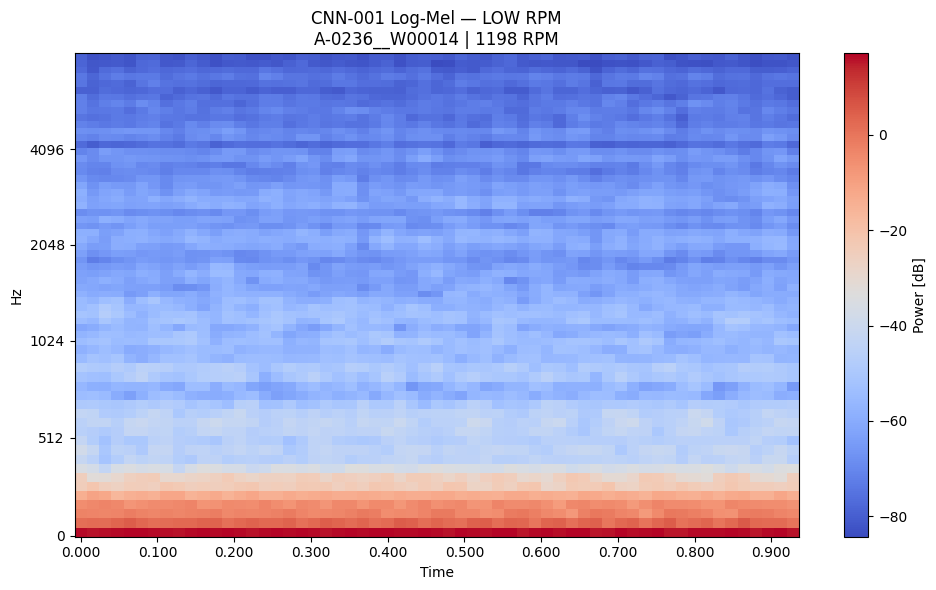

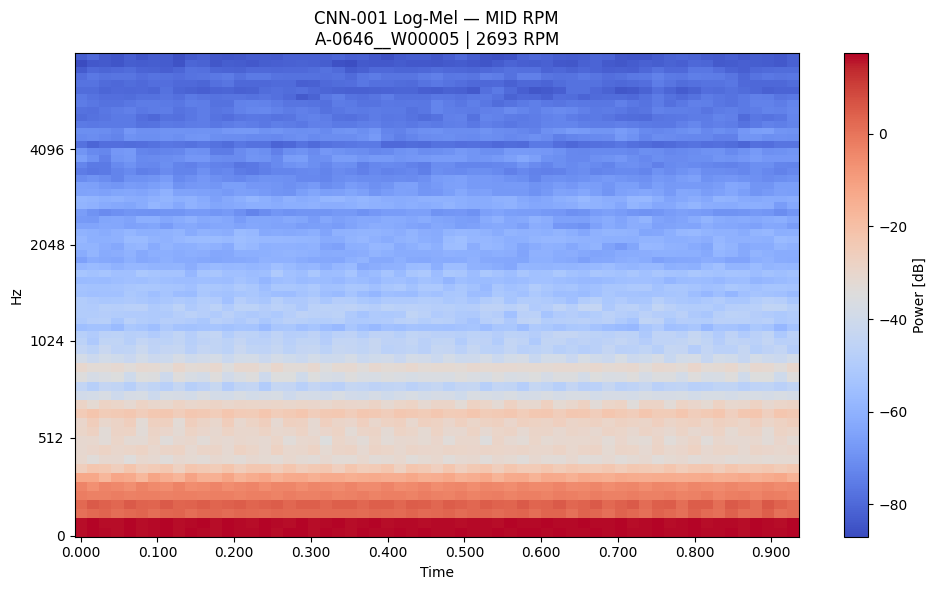

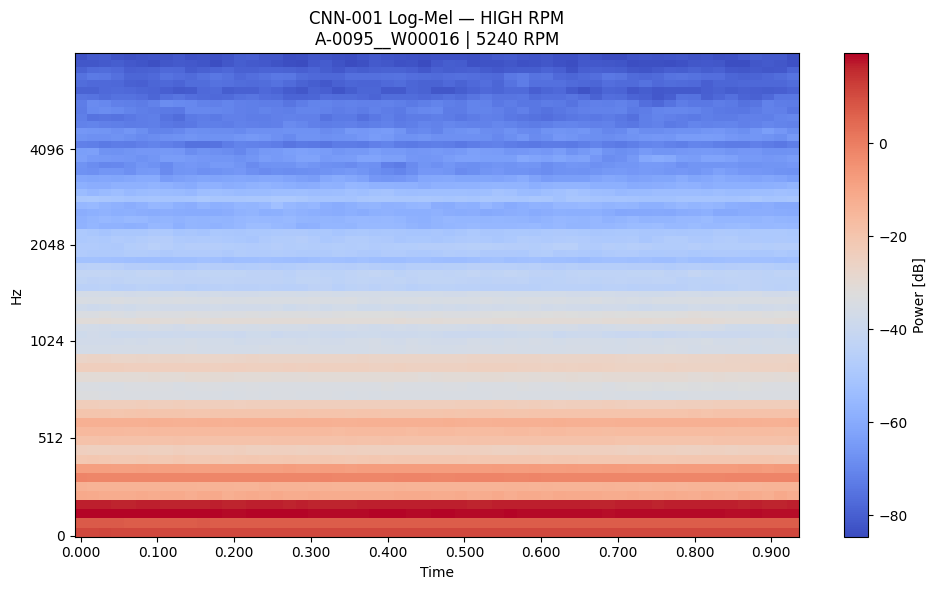

In [25]:
#..Plot
# You should confirm that the log-mels are not blank/corrupt and that
# spectral structure shifts as RPM changes.

import librosa.display

for record in (
    logmel_smoke_records
):

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    image = librosa.display.specshow(
        record[
            "log_mel"
        ],
        sr=
            TARGET_SAMPLE_RATE_HZ,
        hop_length=
            HOP_LENGTH,
        x_axis=
            "time",
        y_axis=
            "mel",
        fmin=
            FMIN_HZ,
        fmax=
            FMAX_HZ,
        ax=ax,
    )

    ax.set_title(
        f"CNN-001 Log-Mel — "
        f"{record['rpm_category'].upper()} RPM\n"
        f"{record['sample_id']} | "
        f"{record['rpm_mean']:.0f} RPM"
    )

    fig.colorbar(
        image,
        ax=ax,
        label="Power [dB]",
    )

    fig.tight_layout()

    output_path = (
        CNN_FIGURE_DIR
        / (
            "logmel_"
            f"{record['rpm_category']}"
            "_rpm_v001.png"
        )
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

In [26]:
# Step 5 — Create persistent CNN-001 log-mel cache

# Step 5A — Ensure h5py is permanent
# ============================================================
# STEP 5A — ENSURE h5py PROJECT DEPENDENCY
# ============================================================

REQUIREMENTS_PATH = (
    REPO_DIR
    / "requirements.txt"
)

requirements_text = (
    REQUIREMENTS_PATH
    .read_text(
        encoding="utf-8"
    )
)

existing_packages = {
    line.strip().lower()
    for line
    in requirements_text.splitlines()
    if line.strip()
}

if "h5py" not in existing_packages:

    with open(
        REQUIREMENTS_PATH,
        "a",
        encoding="utf-8",
    ) as file:

        file.write(
            "\nh5py\n"
        )

    print(
        "Added h5py to requirements.txt."
    )

else:

    print(
        "h5py already listed."
    )

Added h5py to requirements.txt.


In [27]:
#..Install in current runtime (assuming necessity)

!pip install -q h5py

In [28]:
import h5py

print(
    "h5py:",
    h5py.__version__,
)

h5py: 3.16.0


In [29]:
# Step 5B — Persistent cache path

CNN_CACHE_DIR = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "CNN-001"
)

CNN_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CNN_LOGMEL_CACHE_PATH = (
    CNN_CACHE_DIR
    / "logmel_v001.h5"
)

print(
    f"Cache location:\n"
    f"{CNN_LOGMEL_CACHE_PATH}"
)

Cache location:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/cached_features/CNN-001/logmel_v001.h5


In [30]:
# Step 5C — Generate the CNN cache

# ============================================================
# STEP 5C — GENERATE CNN-001 LOG-MEL CACHE
# ============================================================

import soundfile as sf

from scipy.signal import (
    resample_poly
)

from tqdm.auto import tqdm


num_samples = len(
    cnn_model_data
)

n_mels_expected = int(
    LOG_MEL_SHAPE[0]
)

n_frames_expected = int(
    LOG_MEL_SHAPE[1]
)

string_dtype = (
    h5py.string_dtype(
        encoding="utf-8"
    )
)


cache_errors = []
cache_row_index = 0


with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "w",
) as h5:

    logmel_dataset = (
        h5.create_dataset(
            "log_mel",
            shape=(
                num_samples,
                n_mels_expected,
                n_frames_expected,
            ),
            dtype="float32",
            compression="gzip",
            compression_opts=4,
        )
    )

    sample_id_dataset = (
        h5.create_dataset(
            "sample_id",
            shape=(
                num_samples,
            ),
            dtype=
                string_dtype,
        )
    )

    parent_id_dataset = (
        h5.create_dataset(
            "parent_file_id",
            shape=(
                num_samples,
            ),
            dtype=
                string_dtype,
        )
    )

    split_dataset = (
        h5.create_dataset(
            "split",
            shape=(
                num_samples,
            ),
            dtype=
                string_dtype,
        )
    )

    rpm_dataset = (
        h5.create_dataset(
            "rpm_mean",
            shape=(
                num_samples,
            ),
            dtype=
                "float32",
        )
    )

    torque_dataset = (
        h5.create_dataset(
            "torque_mean_nm",
            shape=(
                num_samples,
            ),
            dtype=
                "float32",
        )
    )


    # --------------------------------------------------------
    # Cache metadata
    # --------------------------------------------------------

    h5.attrs[
        "model_version"
    ] = CNN_VERSION

    h5.attrs[
        "preprocessing_version"
    ] = "PREP-001"

    h5.attrs[
        "split_version"
    ] = "SPLIT-001"

    h5.attrs[
        "sample_manifest_version"
    ] = "SAMPLE-MANIFEST-001"

    h5.attrs[
        "sample_rate_hz"
    ] = TARGET_SAMPLE_RATE_HZ

    h5.attrs[
        "n_fft"
    ] = N_FFT

    h5.attrs[
        "win_length"
    ] = WIN_LENGTH

    h5.attrs[
        "hop_length"
    ] = HOP_LENGTH

    h5.attrs[
        "n_mels"
    ] = N_MELS

    h5.attrs[
        "fmin_hz"
    ] = FMIN_HZ

    h5.attrs[
        "fmax_hz"
    ] = FMAX_HZ


    grouped = (
        cnn_model_data
        .groupby(
            "parent_file_id",
            sort=False,
        )
    )


    for (
        parent_file_id,
        parent_rows
    ) in tqdm(
        grouped,
        total=
            cnn_model_data[
                "parent_file_id"
            ].nunique(),
        desc=
            "Building CNN log-mel cache",
    ):

        first_row = (
            parent_rows.iloc[0]
        )

        wav_path = (
            RAW_ROOT
            / first_row[
                "relative_raw_path"
            ]
        )

        try:

            signal, sample_rate = (
                sf.read(
                    wav_path,
                    always_2d=True,
                )
            )

            if (
                sample_rate
                != SOURCE_SAMPLE_RATE_HZ
            ):

                raise ValueError(
                    "Unexpected source "
                    f"sample rate: {sample_rate}"
                )


            for _, row in (
                parent_rows
                .iterrows()
            ):

                start_sample = int(
                    row[
                        "source_start_sample"
                    ]
                )

                end_sample = int(
                    row[
                        "source_end_sample_exclusive"
                    ]
                )

                source_window = (
                    signal[
                        start_sample:
                        end_sample,
                        :
                    ]
                )

                left = (
                    source_window[
                        :,
                        AUDIO_LEFT_INDEX
                    ]
                )

                right = (
                    source_window[
                        :,
                        AUDIO_RIGHT_INDEX
                    ]
                )

                mono_source = (
                    left + right
                ) / 2.0


                gcd = np.gcd(
                    SOURCE_SAMPLE_RATE_HZ,
                    TARGET_SAMPLE_RATE_HZ,
                )

                mono_model = (
                    resample_poly(
                        mono_source,

                        TARGET_SAMPLE_RATE_HZ
                        // gcd,

                        SOURCE_SAMPLE_RATE_HZ
                        // gcd,
                    )
                )


                expected_length = int(
                    round(
                        WINDOW_DURATION_S
                        * TARGET_SAMPLE_RATE_HZ
                    )
                )

                if (
                    len(mono_model)
                    != expected_length
                ):

                    raise ValueError(
                        f"{row['sample_id']}: "
                        "unexpected model "
                        "audio length "
                        f"{len(mono_model)}"
                    )


                log_mel = (
                    compute_log_mel(
                        audio=
                            mono_model,

                        sample_rate_hz=
                            TARGET_SAMPLE_RATE_HZ,

                        n_fft=
                            N_FFT,

                        win_length=
                            WIN_LENGTH,

                        hop_length=
                            HOP_LENGTH,

                        n_mels=
                            N_MELS,

                        fmin_hz=
                            FMIN_HZ,

                        fmax_hz=
                            FMAX_HZ,
                    )
                )


                if (
                    log_mel.shape
                    != LOG_MEL_SHAPE
                ):

                    raise ValueError(
                        f"{row['sample_id']}: "
                        f"log-mel shape "
                        f"{log_mel.shape}; "
                        f"expected "
                        f"{LOG_MEL_SHAPE}"
                    )


                if not np.isfinite(
                    log_mel
                ).all():

                    raise ValueError(
                        f"{row['sample_id']}: "
                        "non-finite log-mel values"
                    )


                logmel_dataset[
                    cache_row_index
                ] = log_mel

                sample_id_dataset[
                    cache_row_index
                ] = row[
                    "sample_id"
                ]

                parent_id_dataset[
                    cache_row_index
                ] = row[
                    "parent_file_id"
                ]

                split_dataset[
                    cache_row_index
                ] = row[
                    "split"
                ]

                rpm_dataset[
                    cache_row_index
                ] = row[
                    "rpm_mean"
                ]

                torque_dataset[
                    cache_row_index
                ] = row[
                    "torque_mean_nm"
                ]

                cache_row_index += 1


        except Exception as error:

            cache_errors.append(
                {
                    "parent_file_id":
                        parent_file_id,

                    "error":
                        str(error),
                }
            )


print()
print(
    f"Rows written:  "
    f"{cache_row_index:,}"
)

print(
    f"Expected rows: "
    f"{num_samples:,}"
)

print(
    f"Errors:        "
    f"{len(cache_errors)}"
)

Building CNN log-mel cache:   0%|          | 0/680 [00:00<?, ?it/s]


Rows written:  11,646
Expected rows: 11,646
Errors:        0


In [31]:
# Step 5D — Validate cache

# ============================================================
# STEP 5D — VALIDATE CNN CACHE
# ============================================================

if cache_errors:

    cache_error_df = (
        pd.DataFrame(
            cache_errors
        )
    )

    display(
        cache_error_df
    )

    raise RuntimeError(
        "CNN cache generation errors occurred."
    )


assert (
    cache_row_index
    == num_samples
)


with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "r",
) as h5:

    print(
        "Cache log-mel shape:",
        h5[
            "log_mel"
        ].shape,
    )

    sample_ids_cache = (
        h5[
            "sample_id"
        ]
        .asstr()[:]
    )

    splits_cache = (
        h5[
            "split"
        ]
        .asstr()[:]
    )


    assert (
        h5[
            "log_mel"
        ].shape
        ==
        (
            num_samples,
            N_MELS,
            LOG_MEL_SHAPE[1],
        )
    )

    assert (
        len(
            np.unique(
                sample_ids_cache
            )
        )
        ==
        len(
            sample_ids_cache
        )
    )

    assert set(
        splits_cache
    ) == {
        "train",
        "validation",
        "test",
    }


    chunk_size = 256

    for start in range(
        0,
        num_samples,
        chunk_size,
    ):

        end = min(
            start
            + chunk_size,
            num_samples,
        )

        block = (
            h5[
                "log_mel"
            ][
                start:end
            ]
        )

        assert np.isfinite(
            block
        ).all()


assert set(
    sample_ids_cache
) == set(
    cnn_model_data[
        "sample_id"
    ]
)


print(
    "PASS: CNN-001 log-mel "
    "cache validated."
)

Cache log-mel shape: (11646, 64, 59)
PASS: CNN-001 log-mel cache validated.


In [32]:
# Step 5E — Fingerprint cache

import hashlib

sha256 = hashlib.sha256()

with open(
    CNN_LOGMEL_CACHE_PATH,
    "rb",
) as file:

    for block in iter(
        lambda:
            file.read(
                1024 * 1024
            ),
        b"",
    ):

        sha256.update(
            block
        )


CNN_LOGMEL_SHA256 = (
    sha256.hexdigest()
)

print(
    "CNN-001 cache SHA-256:"
)

print(
    CNN_LOGMEL_SHA256
)

CNN-001 cache SHA-256:
2cbcf01d0cd61616022a228a97271ae43b642c0148e3cf4f643f647aef9f7aa7


In [33]:
#.. create record

CNN_CACHE_RECORD_PATH = (
    REPO_DIR
    / "data"
    / "cnn001_logmel_cache_v001_record.yaml"
)


cnn_cache_record = {

    "artifact": {

        "name":
            "logmel_v001.h5",

        "model_version":
            CNN_VERSION,

        "status":
            "frozen",

        "storage":
            "Google Drive",

        "logical_path":
            (
                "data/cached_features/"
                "CNN-001/logmel_v001.h5"
            ),

        "sha256":
            CNN_LOGMEL_SHA256,
    },


    "population": {

        "sample_count":
            int(
                len(
                    cnn_model_data
                )
            ),

        "population_filter":
            (
                "model_eligible_rpm_v001 "
                "== True"
            ),
    },


    "representation": {

        "shape_per_sample":
            [
                int(
                    LOG_MEL_SHAPE[0]
                ),
                int(
                    LOG_MEL_SHAPE[1]
                ),
            ],

        "sample_rate_hz":
            TARGET_SAMPLE_RATE_HZ,

        "n_fft":
            N_FFT,

        "win_length":
            WIN_LENGTH,

        "hop_length":
            HOP_LENGTH,

        "n_mels":
            N_MELS,

        "fmin_hz":
            FMIN_HZ,

        "fmax_hz":
            FMAX_HZ,
    },


    "upstream": {

        "preprocessing":
            "PREP-001",

        "split":
            "SPLIT-001",

        "sample_manifest":
            "SAMPLE-MANIFEST-001",
    },
}


with open(
    CNN_CACHE_RECORD_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        cnn_cache_record,
        file,
        sort_keys=False,
    )


print(
    f"Saved:\n"
    f"{CNN_CACHE_RECORD_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/data/cnn001_logmel_cache_v001_record.yaml


In [34]:
# Session closeout steps

# Close-out 1. Save the representative-sample table

# ============================================================
# CLOSEOUT 1 — SAVE CNN REPRESENTATIVE SAMPLE TABLE
# ============================================================

CNN_FIGURE_DIR = (
    FIGURE_DIR
    / "cnn_rpm"
)

CNN_TABLE_DIR = (
    TABLE_DIR
    / "cnn_rpm"
)

CNN_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CNN_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CNN_REPRESENTATIVE_SAMPLE_PATH = (
    CNN_TABLE_DIR
    / "cnn001_representative_samples_v001.csv"
)

columns_to_save = [
    "rpm_category",
    "sample_id",
    "parent_file_id",
    "split",
    "rpm_mean",
    "torque_mean_nm",
    "rpm_range",
]

available_columns = [
    column
    for column in columns_to_save
    if column in cnn_representative_samples.columns
]

cnn_representative_samples[
    available_columns
].to_csv(
    CNN_REPRESENTATIVE_SAMPLE_PATH,
    index=False,
)

print(
    f"Saved:\n"
    f"{CNN_REPRESENTATIVE_SAMPLE_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/results/tables/cnn_rpm/cnn001_representative_samples_v001.csv


In [35]:
# ..verify

rep_check = pd.read_csv(
    CNN_REPRESENTATIVE_SAMPLE_PATH
)

assert len(rep_check) == 3

assert set(
    rep_check[
        "rpm_category"
    ]
) == {
    "low",
    "mid",
    "high",
}

print(
    "PASS: CNN representative samples saved."
)

PASS: CNN representative samples saved.


In [36]:
# Close-out 2. Verify the persistent CNN log-mel cache

# ============================================================
# CLOSEOUT 2 — VERIFY PERSISTENT CNN-001 CACHE
# ============================================================

import h5py
import hashlib
import yaml
import numpy as np

assert CNN_LOGMEL_CACHE_PATH.exists(), (
    "CNN-001 HDF5 cache is missing:\n"
    f"{CNN_LOGMEL_CACHE_PATH}"
)

assert CNN_CACHE_RECORD_PATH.exists(), (
    "CNN-001 cache record is missing:\n"
    f"{CNN_CACHE_RECORD_PATH}"
)


with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "r",
) as h5:

    cache_shape = (
        h5[
            "log_mel"
        ].shape
    )

    cache_sample_ids = (
        h5[
            "sample_id"
        ]
        .asstr()[:]
    )

    cache_splits = (
        h5[
            "split"
        ]
        .asstr()[:]
    )

    print(
        "Cache shape:",
        cache_shape,
    )

    print(
        "Samples:",
        len(
            cache_sample_ids
        ),
    )

    print(
        "Splits:",
        set(
            cache_splits
        ),
    )

    assert (
        cache_shape[0]
        ==
        len(
            cache_sample_ids
        )
    )

    assert (
        len(
            np.unique(
                cache_sample_ids
            )
        )
        ==
        len(
            cache_sample_ids
        )
    )

    assert set(
        cache_splits
    ) == {
        "train",
        "validation",
        "test",
    }


print(
    "PASS: Persistent CNN cache structure valid."
)

Cache shape: (11646, 64, 59)
Samples: 11646
Splits: {'train', 'validation', 'test'}
PASS: Persistent CNN cache structure valid.


In [37]:
# Close-out 3. Recalculate the SHA-256 and compare with the GitHub record
# This proves tomorrow's HDF5 is exactly today's cache

# ============================================================
# CLOSEOUT 3 — VERIFY CNN CACHE FINGERPRINT
# ============================================================

sha256 = hashlib.sha256()

with open(
    CNN_LOGMEL_CACHE_PATH,
    "rb",
) as file:

    for block in iter(
        lambda:
            file.read(
                1024 * 1024
            ),
        b"",
    ):

        sha256.update(
            block
        )


current_cache_sha256 = (
    sha256.hexdigest()
)


with open(
    CNN_CACHE_RECORD_PATH,
    "r",
    encoding="utf-8",
) as file:

    cache_record_check = (
        yaml.safe_load(
            file
        )
    )


recorded_cache_sha256 = (
    cache_record_check[
        "artifact"
    ]["sha256"]
)


print(
    "Current :",
    current_cache_sha256,
)

print(
    "Recorded:",
    recorded_cache_sha256,
)


assert (
    current_cache_sha256
    ==
    recorded_cache_sha256
)


print(
    "PASS: CNN-001 cache fingerprint matches."
)

Current : 2cbcf01d0cd61616022a228a97271ae43b642c0148e3cf4f643f647aef9f7aa7
Recorded: 2cbcf01d0cd61616022a228a97271ae43b642c0148e3cf4f643f647aef9f7aa7
PASS: CNN-001 cache fingerprint matches.


In [38]:
# Close-out 4. Verify today's GitHub-side artifacts
# You want: All expected artifacts present: True

# ============================================================
# CLOSEOUT 4 — NOTEBOOK 08 PARTIAL ARTIFACT AUDIT
# ============================================================

expected_outputs = [
    "configs/cnn_rpm_v001.yaml",
    "src/spectrogram_features.py",
    "data/cnn001_logmel_cache_v001_record.yaml",
    "results/tables/cnn_rpm/cnn001_representative_samples_v001.csv",
    "results/figures/cnn_rpm/logmel_low_rpm_v001.png",
    "results/figures/cnn_rpm/logmel_mid_rpm_v001.png",
    "results/figures/cnn_rpm/logmel_high_rpm_v001.png",
    "requirements.txt",
]

all_present = True

print(
    "Notebook 08 partial-stage artifact audit"
)

print(
    "=" * 72
)

for relative_path in expected_outputs:

    full_path = (
        REPO_DIR
        / relative_path
    )

    if full_path.exists():

        print(
            f"PASS : {relative_path}"
        )

    else:

        print(
            f"MISSING : {relative_path}"
        )

        all_present = False


print()

print(
    "All expected artifacts present:",
    all_present,
)

Notebook 08 partial-stage artifact audit
PASS : configs/cnn_rpm_v001.yaml
PASS : src/spectrogram_features.py
PASS : data/cnn001_logmel_cache_v001_record.yaml
PASS : results/tables/cnn_rpm/cnn001_representative_samples_v001.csv
PASS : results/figures/cnn_rpm/logmel_low_rpm_v001.png
PASS : results/figures/cnn_rpm/logmel_mid_rpm_v001.png
PASS : results/figures/cnn_rpm/logmel_high_rpm_v001.png
PASS : requirements.txt

All expected artifacts present: True


In [39]:
# Close-out 5. Confirm h5py is permanently in requirements.txt

# ============================================================
# CLOSEOUT 5 — VERIFY h5py DEPENDENCY
# ============================================================

REQUIREMENTS_PATH = (
    REPO_DIR
    / "requirements.txt"
)

requirements_lines = [
    line.strip().lower()
    for line
    in REQUIREMENTS_PATH
    .read_text(
        encoding="utf-8"
    )
    .splitlines()
    if line.strip()
]

assert "h5py" in requirements_lines

print(
    "PASS: h5py recorded in requirements.txt."
)

PASS: h5py recorded in requirements.txt.


In [40]:
# Close-out 6. Save Notebook 08 directly to GitHub
# -- DONE

# Close-out 7. Stage today's locally generated artifacts

# ============================================================
# CLOSEOUT 6 — STAGE NOTEBOOK 08 PARTIAL-STAGE ARTIFACTS
# ============================================================

import subprocess

paths_to_add = [
    "configs/cnn_rpm_v001.yaml",
    "src/spectrogram_features.py",
    "data/cnn001_logmel_cache_v001_record.yaml",
    "results/tables/cnn_rpm/cnn001_representative_samples_v001.csv",
    "results/figures/cnn_rpm",
    "requirements.txt",
]

existing_paths = [
    path
    for path in paths_to_add
    if (
        REPO_DIR
        / path
    ).exists()
]

print(
    "Staging:"
)

for path in existing_paths:

    print(
        " +",
        path,
    )


add_result = subprocess.run(
    [
        "git",
        "-C",
        str(
            REPO_DIR
        ),
        "add",
        *existing_paths,
    ],
    capture_output=True,
    text=True,
)


print(
    add_result.stdout
)

if add_result.stderr:

    print(
        add_result.stderr
    )


if (
    add_result.returncode
    != 0
):

    raise RuntimeError(
        "git add failed."
    )


print(
    "PASS: Notebook 08 partial-stage artifacts staged."
)

Staging:
 + configs/cnn_rpm_v001.yaml
 + src/spectrogram_features.py
 + data/cnn001_logmel_cache_v001_record.yaml
 + results/tables/cnn_rpm/cnn001_representative_samples_v001.csv
 + results/figures/cnn_rpm
 + requirements.txt

PASS: Notebook 08 partial-stage artifacts staged.


In [41]:
#.. check

status_result = subprocess.run(
    [
        "git",
        "-C",
        str(
            REPO_DIR
        ),
        "status",
        "--short",
    ],
    capture_output=True,
    text=True,
    check=True,
)

print(
    status_result.stdout
)

A  configs/cnn_rpm_v001.yaml
A  data/cnn001_logmel_cache_v001_record.yaml
M  requirements.txt
A  results/figures/cnn_rpm/logmel_high_rpm_v001.png
A  results/figures/cnn_rpm/logmel_low_rpm_v001.png
A  results/figures/cnn_rpm/logmel_mid_rpm_v001.png
A  results/tables/cnn_rpm/cnn001_representative_samples_v001.csv
A  src/spectrogram_features.py



In [42]:
# Close-out 8. Commit today's CNN input-pipeline work
# Use a commit message that reflects that the model has not been trained yet:

# ============================================================
# CLOSEOUT 7 — COMMIT CNN INPUT PIPELINE
# ============================================================

commit_result = subprocess.run(
    [
        "git",
        "-C",
        str(
            REPO_DIR
        ),
        "commit",
        "-m",
        "Add CNN-001 log-mel input pipeline",
    ],
    capture_output=True,
    text=True,
)


print(
    commit_result.stdout
)

if commit_result.stderr:

    print(
        commit_result.stderr
    )


combined_output = (
    commit_result.stdout
    +
    commit_result.stderr
).lower()


if (
    commit_result.returncode
    != 0
    and
    "nothing to commit"
    not in combined_output
):

    raise RuntimeError(
        "Git commit failed."
    )

[main 275b4e6] Add CNN-001 log-mel input pipeline
 8 files changed, 142 insertions(+)
 create mode 100644 configs/cnn_rpm_v001.yaml
 create mode 100644 data/cnn001_logmel_cache_v001_record.yaml
 create mode 100644 results/figures/cnn_rpm/logmel_high_rpm_v001.png
 create mode 100644 results/figures/cnn_rpm/logmel_low_rpm_v001.png
 create mode 100644 results/figures/cnn_rpm/logmel_mid_rpm_v001.png
 create mode 100644 results/tables/cnn_rpm/cnn001_representative_samples_v001.csv
 create mode 100644 src/spectrogram_features.py



In [43]:
# Close-out 9. Reconcile the notebook commit using git pull --rebase

# ============================================================
# CLOSEOUT 8 — DETERMINE CURRENT BRANCH
# ============================================================

current_branch = subprocess.run(
    [
        "git",
        "-C",
        str(
            REPO_DIR
        ),
        "branch",
        "--show-current",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


print(
    f"Current branch: "
    f"{current_branch}"
)

Current branch: main


In [44]:
# ..then

# ============================================================
# CLOSEOUT 9 — PULL DIRECT NOTEBOOK COMMIT
# ============================================================

pull_result = subprocess.run(
    [
        "git",
        "-C",
        str(
            REPO_DIR
        ),
        "pull",
        "--rebase",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)


print(
    pull_result.stdout
)

if pull_result.stderr:

    print(
        pull_result.stderr
    )


if (
    pull_result.returncode
    != 0
):

    raise RuntimeError(
        "git pull --rebase failed. "
        "Resolve this before ending "
        "the current Colab session."
    )


print(
    "PASS: Local artifacts rebased "
    "onto the saved Notebook 08 commit."
)


From https://github.com/vaibhavjiyer87/engine-nvh-deep-learning
 * branch            main       -> FETCH_HEAD
   5144d09..2bcdcb5  main       -> origin/main
Rebasing (1/1)

Successfully rebased and updated refs/heads/main.

PASS: Local artifacts rebased onto the saved Notebook 08 commit.


In [45]:
# Close-out 10. Push the reconciled state

# ============================================================
# CLOSEOUT 10 — PUSH NOTEBOOK 08 STATE
# ============================================================

push_result = subprocess.run(
    [
        "git",
        "-C",
        str(
            REPO_DIR
        ),
        "push",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)


print(
    push_result.stdout
)

if push_result.stderr:

    print(
        push_result.stderr
    )


if (
    push_result.returncode
    != 0
):

    raise RuntimeError(
        "Git push failed."
    )


print(
    "PASS: Notebook 08 partial-stage "
    "artifacts pushed to GitHub."
)


To https://github.com/vaibhavjiyer87/engine-nvh-deep-learning.git
   2bcdcb5..02e0816  main -> main

PASS: Notebook 08 partial-stage artifacts pushed to GitHub.


In [46]:
# Close-out 11. Final synchronization and clean-tree check

# ============================================================
# CLOSEOUT 11 — FINAL SYNCHRONIZATION CHECK
# ============================================================

subprocess.run(
    [
        "git",
        "-C",
        str(
            REPO_DIR
        ),
        "fetch",
        "origin",
    ],
    check=True,
)


local_head = subprocess.run(
    [
        "git",
        "-C",
        str(
            REPO_DIR
        ),
        "rev-parse",
        "HEAD",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


remote_head = subprocess.run(
    [
        "git",
        "-C",
        str(
            REPO_DIR
        ),
        "rev-parse",
        f"origin/{current_branch}",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


print(
    "Local :",
    local_head,
)

print(
    "Remote:",
    remote_head,
)


assert (
    local_head
    ==
    remote_head
)


final_status = subprocess.run(
    [
        "git",
        "-C",
        str(
            REPO_DIR
        ),
        "status",
        "--porcelain",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


if final_status:

    print()
    print(
        "WARNING: Uncommitted files remain:"
    )

    print(
        final_status
    )

else:

    print()
    print(
        "PASS: Working tree is clean."
    )


print()
print(
    "PASS: Notebook 08 partial-session "
    "closeout complete."
)

Local : 02e081695667eb1e54845de2b76ca9fcddfdbc8d
Remote: 02e081695667eb1e54845de2b76ca9fcddfdbc8d

PASS: Working tree is clean.

PASS: Notebook 08 partial-session closeout complete.


* ^ A session was closed after the 11 Close-out steps above.
* Restarting a new session from the cells below

In [6]:
# Step 5F — Restore CNN-001 state

# ============================================================
# NEXT SESSION — RESTORE CNN-001 CONFIGURATION
# ============================================================

import yaml
import h5py
import numpy as np
import pandas as pd
import torch

CNN_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v001.yaml"
)


if not CNN_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "CNN-001 configuration missing:\n"
        f"{CNN_CONFIG_PATH}"
    )


with open(
    CNN_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:

    cnn_config = (
        yaml.safe_load(
            file
        )
    )


CNN_VERSION = (
    cnn_config[
        "specification"
    ]["model_version"]
)


assert (
    CNN_VERSION
    == "CNN-001"
)


print(
    "PASS: CNN-001 configuration restored."
)

PASS: CNN-001 configuration restored.


In [7]:
# Restore runtime constants

# ============================================================
# RESTORE CNN-001 RUNTIME CONSTANTS
# ============================================================

N_FFT = int(
    cnn_config[
        "log_mel"
    ]["n_fft"]
)

WIN_LENGTH = int(
    cnn_config[
        "log_mel"
    ]["win_length"]
)

HOP_LENGTH = int(
    cnn_config[
        "log_mel"
    ]["hop_length"]
)

N_MELS = int(
    cnn_config[
        "log_mel"
    ]["n_mels"]
)

FMIN_HZ = float(
    cnn_config[
        "log_mel"
    ]["fmin_hz"]
)

FMAX_HZ = float(
    cnn_config[
        "log_mel"
    ]["fmax_hz"]
)

BATCH_SIZE = int(
    cnn_config[
        "training"
    ]["batch_size"]
)

MAX_EPOCHS = int(
    cnn_config[
        "training"
    ]["maximum_epochs"]
)

EARLY_STOPPING_PATIENCE = int(
    cnn_config[
        "training"
    ]["early_stopping_patience"]
)

LEARNING_RATE = float(
    cnn_config[
        "training"
    ]["learning_rate"]
)

WEIGHT_DECAY = float(
    cnn_config[
        "training"
    ]["weight_decay"]
)

RANDOM_SEED = int(
    cnn_config[
        "training"
    ]["random_seed"]
)

CNN_DROPOUT = float(
    cnn_config[
        "architecture"
    ]["dropout"]
)


print(
    "PASS: CNN-001 runtime constants restored."
)

PASS: CNN-001 runtime constants restored.


In [8]:
# Restore cache path and shape

# ============================================================
# RESTORE PERSISTENT CNN CACHE
# ============================================================

CNN_CACHE_DIR = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "CNN-001"
)

CNN_LOGMEL_CACHE_PATH = (
    CNN_CACHE_DIR
    / "logmel_v001.h5"
)


if not CNN_LOGMEL_CACHE_PATH.exists():

    raise FileNotFoundError(
        "CNN-001 log-mel cache missing:\n"
        f"{CNN_LOGMEL_CACHE_PATH}"
    )


with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "r",
) as h5:

    cache_shape = (
        h5[
            "log_mel"
        ].shape
    )

    LOG_MEL_SHAPE = (
        int(
            cache_shape[1]
        ),
        int(
            cache_shape[2]
        ),
    )


print(
    "Cache:",
    cache_shape,
)

print(
    "Per-sample shape:",
    LOG_MEL_SHAPE,
)

assert (
    LOG_MEL_SHAPE[0]
    == N_MELS
)

print(
    "PASS: CNN-001 persistent cache restored."
)

Cache: (11646, 64, 59)
Per-sample shape: (64, 59)
PASS: CNN-001 persistent cache restored.


In [9]:
# Step 6 — Training-only normalization
# The normalization statistics must be calculated from training samples only.
# Validation and test use those same training-derived values

# Step 6A — Recover train/validation/test cache indices

# ============================================================
# STEP 6A — RECOVER CACHE SPLIT INDICES
# ============================================================

import h5py
import numpy as np
import pandas as pd

with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "r",
) as h5:

    cache_splits = (
        h5["split"]
        .asstr()[:]
    )

    cache_sample_ids = (
        h5["sample_id"]
        .asstr()[:]
    )

    cache_rpm = (
        h5["rpm_mean"][:]
    )


TRAIN_INDICES = np.where(
    cache_splits == "train"
)[0]

VALIDATION_INDICES = np.where(
    cache_splits == "validation"
)[0]

TEST_INDICES = np.where(
    cache_splits == "test"
)[0]


print(
    f"Train samples:      "
    f"{len(TRAIN_INDICES):,}"
)

print(
    f"Validation samples: "
    f"{len(VALIDATION_INDICES):,}"
)

print(
    f"Test samples:       "
    f"{len(TEST_INDICES):,}"
)

assert len(TRAIN_INDICES) > 0
assert len(VALIDATION_INDICES) > 0
assert len(TEST_INDICES) > 0

assert (
    len(TRAIN_INDICES)
    + len(VALIDATION_INDICES)
    + len(TEST_INDICES)
    ==
    len(cache_splits)
)

print(
    "PASS: CNN-001 cache split indices restored."
)

Train samples:      7,958
Validation samples: 1,798
Test samples:       1,890
PASS: CNN-001 cache split indices restored.


In [10]:
# ..Also confirm there is no overlap

# ============================================================
# STEP 6A-2 — SPLIT OVERLAP CHECK
# ============================================================

assert len(
    np.intersect1d(
        TRAIN_INDICES,
        VALIDATION_INDICES,
    )
) == 0

assert len(
    np.intersect1d(
        TRAIN_INDICES,
        TEST_INDICES,
    )
) == 0

assert len(
    np.intersect1d(
        VALIDATION_INDICES,
        TEST_INDICES,
    )
) == 0

print(
    "PASS: Train/validation/test cache indices "
    "are mutually exclusive."
)

PASS: Train/validation/test cache indices are mutually exclusive.


In [11]:
# Step 6B — Calculate training-only log-mel mean/std
# Use a streaming calculation so you don't load the whole HDF5 cache into RAM

# ============================================================
# STEP 6B — TRAINING-ONLY LOG-MEL NORMALIZATION
# ============================================================

total_sum = 0.0
total_sum_squared = 0.0
total_elements = 0

chunk_size = 256


with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "r",
) as h5:

    log_mel_h5 = h5[
        "log_mel"
    ]

    for start in range(
        0,
        len(TRAIN_INDICES),
        chunk_size,
    ):

        index_chunk = (
            TRAIN_INDICES[
                start:
                start + chunk_size
            ]
        )

        block = (
            log_mel_h5[
                index_chunk
            ]
            .astype(
                np.float64
            )
        )

        total_sum += (
            block.sum()
        )

        total_sum_squared += (
            np.square(
                block
            ).sum()
        )

        total_elements += (
            block.size
        )


TRAIN_LOGMEL_MEAN = (
    total_sum
    / total_elements
)

train_logmel_variance = (
    total_sum_squared
    / total_elements
    -
    TRAIN_LOGMEL_MEAN ** 2
)

TRAIN_LOGMEL_STD = float(
    np.sqrt(
        max(
            train_logmel_variance,
            0.0,
        )
    )
)


assert np.isfinite(
    TRAIN_LOGMEL_MEAN
)

assert np.isfinite(
    TRAIN_LOGMEL_STD
)

assert TRAIN_LOGMEL_STD > 0


print(
    f"Training log-mel mean: "
    f"{TRAIN_LOGMEL_MEAN:.6f}"
)

print(
    f"Training log-mel std:  "
    f"{TRAIN_LOGMEL_STD:.6f}"
)

print(
    "PASS: Training-only log-mel "
    "normalization calculated."
)

Training log-mel mean: -55.559992
Training log-mel std:  27.285104
PASS: Training-only log-mel normalization calculated.


In [12]:
# Step 6C — Calculate training-only RPM normalization

# ============================================================
# STEP 6C — TRAINING-ONLY RPM NORMALIZATION
# ============================================================

train_rpm_values = (
    cache_rpm[
        TRAIN_INDICES
    ]
    .astype(
        np.float64
    )
)


TRAIN_RPM_MEAN = float(
    np.mean(
        train_rpm_values
    )
)

TRAIN_RPM_STD = float(
    np.std(
        train_rpm_values,
        ddof=0,
    )
)


assert np.isfinite(
    TRAIN_RPM_MEAN
)

assert np.isfinite(
    TRAIN_RPM_STD
)

assert TRAIN_RPM_STD > 0


print(
    f"Training RPM mean: "
    f"{TRAIN_RPM_MEAN:.3f} RPM"
)

print(
    f"Training RPM std:  "
    f"{TRAIN_RPM_STD:.3f} RPM"
)

print(
    "PASS: Training-only RPM "
    "normalization calculated."
)

Training RPM mean: 3010.708 RPM
Training RPM std:  1741.961 RPM
PASS: Training-only RPM normalization calculated.


In [13]:
# Step 6D — Save normalization record to GitHub-side repository
# create 'data/cnn001_normalization_v001.yaml'

# ============================================================
# STEP 6D — SAVE CNN-001 NORMALIZATION RECORD
# ============================================================

import yaml

CNN_NORMALIZATION_PATH = (
    REPO_DIR
    / "data"
    / "cnn001_normalization_v001.yaml"
)


cnn_normalization_record = {

    "model_version":
        CNN_VERSION,

    "fit_population":
        "training_split_only",

    "sample_counts": {

        "train":
            int(
                len(
                    TRAIN_INDICES
                )
            ),

        "validation":
            int(
                len(
                    VALIDATION_INDICES
                )
            ),

        "test":
            int(
                len(
                    TEST_INDICES
                )
            ),
    },

    "log_mel": {

        "mean":
            float(
                TRAIN_LOGMEL_MEAN
            ),

        "std":
            float(
                TRAIN_LOGMEL_STD
            ),
    },

    "rpm_target": {

        "mean_rpm":
            float(
                TRAIN_RPM_MEAN
            ),

        "std_rpm":
            float(
                TRAIN_RPM_STD
            ),
    },

    "leakage_policy": {

        "validation_statistics_used":
            False,

        "test_statistics_used":
            False,
    },
}


with open(
    CNN_NORMALIZATION_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        cnn_normalization_record,
        file,
        sort_keys=False,
    )


print(
    f"Saved:\n"
    f"{CNN_NORMALIZATION_PATH}"
)


Saved:
/content/engine-nvh-deep-learning/data/cnn001_normalization_v001.yaml


In [15]:
# .. validate it immediately

# ============================================================
# STEP 6D-2 — VALIDATE NORMALIZATION RECORD
# ============================================================

with open(
    CNN_NORMALIZATION_PATH,
    "r",
    encoding="utf-8",
) as file:

    normalization_check = (
        yaml.safe_load(
            file
        )
    )


assert (
    normalization_check[
        "model_version"
    ]
    == "CNN-001"
)

assert (
    normalization_check[
        "fit_population"
    ]
    == "training_split_only"
)

assert (
    normalization_check[
        "leakage_policy"
    ][
        "test_statistics_used"
    ]
    is False
)


print(
    "PASS: CNN-001 normalization "
    "record validated."
)

PASS: CNN-001 normalization record validated.


In [16]:
# Step 7 — Create PyTorch Dataset and DataLoaders
# The dataset will read log-mels directly from your persistent HDF5 cache

# Step 7A — Create physical src/cnn_dataset.py

# ============================================================
# STEP 7A — CREATE src/cnn_dataset.py
# ============================================================

from pathlib import Path
import textwrap

CNN_DATASET_MODULE_PATH = (
    REPO_DIR
    / "src"
    / "cnn_dataset.py"
)


cnn_dataset_code = r'''
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset


class H5LogMelDataset(Dataset):
    """
    Dataset for CNN-001 cached log-mel spectrograms.

    Returns
    -------
    x_tensor : torch.Tensor
        Shape [1, n_mels, time_frames]

    y_tensor : torch.Tensor
        Standardized RPM target.

    cache_index : int
        Original row index in the HDF5 cache.
    """

    def __init__(
        self,
        h5_path,
        indices,
        logmel_mean,
        logmel_std,
        rpm_mean,
        rpm_std,
    ):

        self.h5_path = str(
            h5_path
        )

        self.indices = np.asarray(
            indices,
            dtype=np.int64,
        )

        self.logmel_mean = float(
            logmel_mean
        )

        self.logmel_std = float(
            logmel_std
        )

        self.rpm_mean = float(
            rpm_mean
        )

        self.rpm_std = float(
            rpm_std
        )

        self._h5 = None


    def _get_h5(self):

        if self._h5 is None:

            self._h5 = h5py.File(
                self.h5_path,
                "r",
            )

        return self._h5


    def __len__(self):

        return len(
            self.indices
        )


    def __getitem__(
        self,
        dataset_index,
    ):

        h5 = self._get_h5()

        cache_index = int(
            self.indices[
                dataset_index
            ]
        )

        x = (
            h5[
                "log_mel"
            ][
                cache_index
            ]
            .astype(
                np.float32
            )
        )

        rpm = float(
            h5[
                "rpm_mean"
            ][
                cache_index
            ]
        )


        # --------------------------------------------
        # Training-derived input normalization
        # --------------------------------------------

        x = (
            x
            - self.logmel_mean
        ) / self.logmel_std


        # --------------------------------------------
        # Training-derived target normalization
        # --------------------------------------------

        y = (
            rpm
            - self.rpm_mean
        ) / self.rpm_std


        # [mel, time]
        #     ->
        # [channel, mel, time]

        x_tensor = (
            torch.from_numpy(
                x
            )
            .unsqueeze(0)
        )


        y_tensor = (
            torch.tensor(
                y,
                dtype=torch.float32,
            )
        )


        return (
            x_tensor,
            y_tensor,
            cache_index,
        )


    def close(self):

        if self._h5 is not None:

            self._h5.close()

            self._h5 = None


    def __del__(self):

        self.close()
'''


CNN_DATASET_MODULE_PATH.write_text(
    textwrap.dedent(
        cnn_dataset_code
    ).lstrip(),
    encoding="utf-8",
)


print(
    f"Created:\n"
    f"{CNN_DATASET_MODULE_PATH}"
)

print(
    "Exists:",
    CNN_DATASET_MODULE_PATH.exists(),
)

Created:
/content/engine-nvh-deep-learning/src/cnn_dataset.py
Exists: True


In [17]:
# Step 7B — Import the saved Dataset class

# ============================================================
# STEP 7B — IMPORT CNN DATASET MODULE
# ============================================================

import sys
import importlib

if str(REPO_DIR) not in sys.path:

    sys.path.insert(
        0,
        str(REPO_DIR),
    )


import src.cnn_dataset

importlib.reload(
    src.cnn_dataset
)


from src.cnn_dataset import (
    H5LogMelDataset
)


print(
    "PASS: src.cnn_dataset imported."
)

PASS: src.cnn_dataset imported.


In [18]:
# Step 7C — Create train/validation/test Dataset objects

# ============================================================
# STEP 7C — CREATE DATASET OBJECTS
# ============================================================

train_dataset = H5LogMelDataset(

    h5_path=
        CNN_LOGMEL_CACHE_PATH,

    indices=
        TRAIN_INDICES,

    logmel_mean=
        TRAIN_LOGMEL_MEAN,

    logmel_std=
        TRAIN_LOGMEL_STD,

    rpm_mean=
        TRAIN_RPM_MEAN,

    rpm_std=
        TRAIN_RPM_STD,
)


validation_dataset = H5LogMelDataset(

    h5_path=
        CNN_LOGMEL_CACHE_PATH,

    indices=
        VALIDATION_INDICES,

    logmel_mean=
        TRAIN_LOGMEL_MEAN,

    logmel_std=
        TRAIN_LOGMEL_STD,

    rpm_mean=
        TRAIN_RPM_MEAN,

    rpm_std=
        TRAIN_RPM_STD,
)


test_dataset = H5LogMelDataset(

    h5_path=
        CNN_LOGMEL_CACHE_PATH,

    indices=
        TEST_INDICES,

    logmel_mean=
        TRAIN_LOGMEL_MEAN,

    logmel_std=
        TRAIN_LOGMEL_STD,

    rpm_mean=
        TRAIN_RPM_MEAN,

    rpm_std=
        TRAIN_RPM_STD,
)


print(
    f"Train Dataset:      "
    f"{len(train_dataset):,}"
)

print(
    f"Validation Dataset: "
    f"{len(validation_dataset):,}"
)

print(
    f"Test Dataset:       "
    f"{len(test_dataset):,}"
)

# Creating test_dataset is harmless. We simply do not evaluate it yet

Train Dataset:      7,958
Validation Dataset: 1,798
Test Dataset:       1,890


In [19]:
# Step 7D — Create DataLoaders

# ============================================================
# STEP 7D — CREATE DATALOADERS
# ============================================================

import torch

from torch.utils.data import (
    DataLoader
)


train_loader = DataLoader(

    train_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=
        torch.cuda.is_available(),
)


validation_loader = DataLoader(

    validation_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=
        torch.cuda.is_available(),
)


test_loader = DataLoader(

    test_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=
        torch.cuda.is_available(),
)


print(
    "PASS: CNN DataLoaders created."
)

PASS: CNN DataLoaders created.


In [20]:
# Step 7E — Batch smoke test

# ============================================================
# STEP 7E — DATALOADER SMOKE TEST
# ============================================================

X_batch, y_batch, cache_index_batch = (
    next(
        iter(
            train_loader
        )
    )
)


print(
    "X batch shape:",
    X_batch.shape,
)

print(
    "y batch shape:",
    y_batch.shape,
)

print(
    "Index shape:",
    cache_index_batch.shape,
)


assert X_batch.ndim == 4

assert (
    X_batch.shape[1]
    == 1
)

assert (
    X_batch.shape[2]
    == N_MELS
)

assert (
    X_batch.shape[3]
    == LOG_MEL_SHAPE[1]
)

assert torch.isfinite(
    X_batch
).all()

assert torch.isfinite(
    y_batch
).all()


print(
    "Input normalized mean "
    f"(one batch): "
    f"{X_batch.mean().item():.3f}"
)

print(
    "Input normalized std "
    f"(one batch): "
    f"{X_batch.std().item():.3f}"
)


print(
    "PASS: CNN batch smoke test succeeded."
)

X batch shape: torch.Size([64, 1, 64, 59])
y batch shape: torch.Size([64])
Index shape: torch.Size([64])
Input normalized mean (one batch): -0.002
Input normalized std (one batch): 0.986
PASS: CNN batch smoke test succeeded.


In [21]:
# Step 8 — Build CNN-001
# Keep the first CNN intentionally modest

# Step 8A — Create physical src/cnn_models.py

# ============================================================
# STEP 8A — CREATE src/cnn_models.py
# ============================================================

CNN_MODEL_MODULE_PATH = (
    REPO_DIR
    / "src"
    / "cnn_models.py"
)


cnn_model_code = r'''
import torch
import torch.nn as nn


class CNNRPMRegressor(nn.Module):

    def __init__(
        self,
        dropout=0.20,
    ):

        super().__init__()


        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(
                16
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                2
            ),


            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(
                32
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                2
            ),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(
                64
            ),

            nn.ReLU(),

            nn.MaxPool2d(
                2
            ),


            nn.AdaptiveAvgPool2d(
                (1, 1)
            ),
        )


        self.regressor = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64,
                32,
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                32,
                1,
            ),
        )


    def forward(
        self,
        x,
    ):

        x = self.features(
            x
        )

        x = self.regressor(
            x
        )

        return x.squeeze(
            -1
        )
'''


CNN_MODEL_MODULE_PATH.write_text(
    textwrap.dedent(
        cnn_model_code
    ).lstrip(),
    encoding="utf-8",
)


print(
    f"Created:\n"
    f"{CNN_MODEL_MODULE_PATH}"
)

Created:
/content/engine-nvh-deep-learning/src/cnn_models.py


In [22]:
# Step 8B — Import and smoke-test the model

# ============================================================
# STEP 8B — IMPORT AND TEST CNN-001
# ============================================================

import src.cnn_models

importlib.reload(
    src.cnn_models
)

from src.cnn_models import (
    CNNRPMRegressor
)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


cnn_model = CNNRPMRegressor(
    dropout=
        CNN_DROPOUT
).to(
    device
)


with torch.no_grad():

    smoke_output = cnn_model(
        X_batch.to(
            device
        )
    )


print(
    "Device:",
    device,
)

print(
    "Input:",
    X_batch.shape,
)

print(
    "Output:",
    smoke_output.shape,
)


assert (
    smoke_output.shape[0]
    ==
    X_batch.shape[0]
)

assert torch.isfinite(
    smoke_output
).all()


parameter_count = sum(
    parameter.numel()
    for parameter
    in cnn_model.parameters()
)


print(
    f"Trainable parameters: "
    f"{parameter_count:,}"
)

print(
    "PASS: CNN-001 forward pass succeeded."
)

Device: cuda
Input: torch.Size([64, 1, 64, 59])
Output: torch.Size([64])
Trainable parameters: 25,633
PASS: CNN-001 forward pass succeeded.


In [23]:
# Step 9 — Train CNN-001

# Step 9A — Set reproducibility seed, then recreate model
# The seed needs to be set before initializing the final model.

# ============================================================
# STEP 9A — SET RANDOM SEEDS
# ============================================================

import random

random.seed(
    RANDOM_SEED
)

np.random.seed(
    RANDOM_SEED
)

torch.manual_seed(
    RANDOM_SEED
)


if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        RANDOM_SEED
    )


cnn_model = CNNRPMRegressor(
    dropout=
        CNN_DROPOUT
).to(
    device
)


print(
    f"Random seed: {RANDOM_SEED}"
)

print(
    "PASS: Final CNN-001 model initialized "
    "after reproducibility seed setup."
)

Random seed: 42
PASS: Final CNN-001 model initialized after reproducibility seed setup.


In [24]:
# Step 9B — Define training objects and persistent checkpoint

# ============================================================
# STEP 9B — LOSS, OPTIMIZER AND CHECKPOINT
# ============================================================

import torch.nn as nn


criterion = nn.MSELoss()


optimizer = torch.optim.AdamW(

    cnn_model.parameters(),

    lr=
        LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY,
)


CNN_MODEL_DIR = (
    PROJECT_DRIVE
    / "models"
    / "cnn"
)

CNN_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


CNN_BEST_MODEL_PATH = (
    CNN_MODEL_DIR
    / "cnn001_rpm_best_v001.pt"
)


print(
    f"Checkpoint location:\n"
    f"{CNN_BEST_MODEL_PATH}"
)

Checkpoint location:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/models/cnn/cnn001_rpm_best_v001.pt


In [25]:
# Step 9C — Define validation function

# ============================================================
# STEP 9C — CNN EVALUATION FUNCTION
# ============================================================

def evaluate_cnn(
    model,
    data_loader,
    criterion,
    device,
    rpm_mean,
    rpm_std,
):

    model.eval()

    loss_sum = 0.0
    sample_count = 0

    true_rpm = []
    predicted_rpm = []


    with torch.no_grad():

        for (
            X,
            y_standardized,
            _
        ) in data_loader:

            X = X.to(
                device
            )

            y_standardized = (
                y_standardized.to(
                    device
                )
            )


            prediction_standardized = (
                model(
                    X
                )
            )


            loss = criterion(
                prediction_standardized,
                y_standardized,
            )


            actual_batch_size = (
                X.shape[0]
            )

            loss_sum += (
                loss.item()
                * actual_batch_size
            )

            sample_count += (
                actual_batch_size
            )


            actual_rpm = (
                y_standardized
                .detach()
                .cpu()
                .numpy()
                * rpm_std
                + rpm_mean
            )


            prediction_rpm = (
                prediction_standardized
                .detach()
                .cpu()
                .numpy()
                * rpm_std
                + rpm_mean
            )


            true_rpm.extend(
                actual_rpm
            )

            predicted_rpm.extend(
                prediction_rpm
            )


    true_rpm = np.asarray(
        true_rpm
    )

    predicted_rpm = np.asarray(
        predicted_rpm
    )


    return {

        "loss":
            float(
                loss_sum
                / sample_count
            ),

        "mae_rpm":
            float(
                np.mean(
                    np.abs(
                        predicted_rpm
                        - true_rpm
                    )
                )
            ),

        "y_true":
            true_rpm,

        "y_pred":
            predicted_rpm,
    }

In [ ]:
# Step 9D — Train with early stopping

# ============================================================
# STEP 9D — TRAIN CNN-001
# ============================================================

training_history = []

best_validation_mae = np.inf

best_epoch = None

epochs_without_improvement = 0


for epoch in range(
    1,
    MAX_EPOCHS + 1,
):

    cnn_model.train()

    train_loss_sum = 0.0
    train_sample_count = 0


    for (
        X,
        y_standardized,
        _
    ) in train_loader:

        X = X.to(
            device
        )

        y_standardized = (
            y_standardized.to(
                device
            )
        )


        optimizer.zero_grad()


        prediction = cnn_model(
            X
        )


        loss = criterion(
            prediction,
            y_standardized,
        )


        loss.backward()


        optimizer.step()


        actual_batch_size = (
            X.shape[0]
        )

        train_loss_sum += (
            loss.item()
            * actual_batch_size
        )

        train_sample_count += (
            actual_batch_size
        )


    train_loss = (
        train_loss_sum
        / train_sample_count
    )


    validation_result = evaluate_cnn(

        model=
            cnn_model,

        data_loader=
            validation_loader,

        criterion=
            criterion,

        device=
            device,

        rpm_mean=
            TRAIN_RPM_MEAN,

        rpm_std=
            TRAIN_RPM_STD,
    )


    validation_loss = (
        validation_result[
            "loss"
        ]
    )

    validation_mae = (
        validation_result[
            "mae_rpm"
        ]
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    training_history.append(
        {

            "epoch":
                epoch,

            "train_loss":
                train_loss,

            "validation_loss":
                validation_loss,

            "validation_mae_rpm":
                validation_mae,

            "learning_rate":
                current_lr,
        }
    )


    print(
        f"Epoch {epoch:02d} | "
        f"train loss "
        f"{train_loss:.5f} | "
        f"val loss "
        f"{validation_loss:.5f} | "
        f"val MAE "
        f"{validation_mae:.2f} RPM"
    )


    if (
        validation_mae
        <
        best_validation_mae
    ):

        best_validation_mae = (
            validation_mae
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        torch.save(
            {

                "model_version":
                    CNN_VERSION,

                "epoch":
                    epoch,

                "model_state_dict":
                    cnn_model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "validation_mae_rpm":
                    validation_mae,

                "train_logmel_mean":
                    TRAIN_LOGMEL_MEAN,

                "train_logmel_std":
                    TRAIN_LOGMEL_STD,

                "train_rpm_mean":
                    TRAIN_RPM_MEAN,

                "train_rpm_std":
                    TRAIN_RPM_STD,

                "log_mel_shape":
                    LOG_MEL_SHAPE,

                "cnn_config":
                    cnn_config,
            },

            CNN_BEST_MODEL_PATH,
        )


        print(
            "  -> saved new best checkpoint"
        )


    else:

        epochs_without_improvement += 1


    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print()
        print(
            "Early stopping triggered."
        )

        break


print()
print("=" * 60)

print(
    f"Best epoch: "
    f"{best_epoch}"
)

print(
    f"Best validation MAE: "
    f"{best_validation_mae:.2f} RPM"
)

print("=" * 60)

Epoch 01 | train loss 0.11107 | val loss 0.01734 | val MAE 180.72 RPM
  -> saved new best checkpoint
Epoch 02 | train loss 0.05506 | val loss 0.07696 | val MAE 398.24 RPM
Epoch 03 | train loss 0.04784 | val loss 0.03755 | val MAE 253.69 RPM
Epoch 04 | train loss 0.04289 | val loss 0.06732 | val MAE 338.97 RPM
Epoch 05 | train loss 0.04717 | val loss 0.00530 | val MAE 97.08 RPM
  -> saved new best checkpoint
Epoch 06 | train loss 0.03947 | val loss 0.00847 | val MAE 119.14 RPM
Epoch 07 | train loss 0.04263 | val loss 0.03469 | val MAE 250.92 RPM
Epoch 08 | train loss 0.03903 | val loss 0.00761 | val MAE 126.76 RPM
Epoch 09 | train loss 0.03657 | val loss 0.00496 | val MAE 97.05 RPM
  -> saved new best checkpoint
Epoch 10 | train loss 0.03647 | val loss 0.04994 | val MAE 353.26 RPM
Epoch 11 | train loss 0.03503 | val loss 0.00664 | val MAE 111.52 RPM
Epoch 12 | train loss 0.03463 | val loss 0.01005 | val MAE 143.67 RPM
Epoch 13 | train loss 0.03081 | val loss 0.00506 | val MAE 102.51 RPM

* At this point, after Epoch 17 was identified as the best new checkpoint, Colab disconnected.
* Restriction around GPU (thrown by Colab's limits) were observed.
* After reviewing situation with ChatGPT, recommendation was made to re-run Start up cells 1 thru 5.
* The following steps are in continuation of those recommendations to be able to re-use the data gathered until the Colab disconnection.

In [6]:
# Recovery session

# A. Restore CNN-001 configuration and runtime constants
# ============================================================
# RECOVERY A — RESTORE CNN-001 CONFIG + RUNTIME CONSTANTS
# ============================================================

import yaml
import h5py
import numpy as np
import pandas as pd
import torch

CNN_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v001.yaml"
)

with open(
    CNN_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:

    cnn_config = yaml.safe_load(
        file
    )


CNN_VERSION = (
    cnn_config[
        "specification"
    ]["model_version"]
)

assert CNN_VERSION == "CNN-001"


N_FFT = int(
    cnn_config["log_mel"]["n_fft"]
)

WIN_LENGTH = int(
    cnn_config["log_mel"]["win_length"]
)

HOP_LENGTH = int(
    cnn_config["log_mel"]["hop_length"]
)

N_MELS = int(
    cnn_config["log_mel"]["n_mels"]
)

FMIN_HZ = float(
    cnn_config["log_mel"]["fmin_hz"]
)

FMAX_HZ = float(
    cnn_config["log_mel"]["fmax_hz"]
)

BATCH_SIZE = int(
    cnn_config["training"]["batch_size"]
)

MAX_EPOCHS = int(
    cnn_config["training"]["maximum_epochs"]
)

EARLY_STOPPING_PATIENCE = int(
    cnn_config[
        "training"
    ]["early_stopping_patience"]
)

LEARNING_RATE = float(
    cnn_config["training"]["learning_rate"]
)

WEIGHT_DECAY = float(
    cnn_config["training"]["weight_decay"]
)

RANDOM_SEED = int(
    cnn_config["training"]["random_seed"]
)

CNN_DROPOUT = float(
    cnn_config["architecture"]["dropout"]
)

print(
    "PASS: CNN-001 configuration "
    "and runtime constants restored."
)

PASS: CNN-001 configuration and runtime constants restored.


In [7]:
# Recovery session

# B. Restore the existing log-mel cache
# This replaces rerunning Steps 5A–5F from above

# ============================================================
# RECOVERY B — RESTORE EXISTING CNN CACHE
# ============================================================

CNN_CACHE_DIR = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "CNN-001"
)

CNN_LOGMEL_CACHE_PATH = (
    CNN_CACHE_DIR
    / "logmel_v001.h5"
)

if not CNN_LOGMEL_CACHE_PATH.exists():
    raise FileNotFoundError(
        CNN_LOGMEL_CACHE_PATH
    )


with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "r",
) as h5:

    cache_shape = (
        h5["log_mel"].shape
    )

    cache_splits = (
        h5["split"]
        .asstr()[:]
    )

    cache_rpm = (
        h5["rpm_mean"][:]
    )


LOG_MEL_SHAPE = (
    int(cache_shape[1]),
    int(cache_shape[2]),
)


TRAIN_INDICES = np.where(
    cache_splits == "train"
)[0]

VALIDATION_INDICES = np.where(
    cache_splits == "validation"
)[0]

TEST_INDICES = np.where(
    cache_splits == "test"
)[0]


print(
    "Cache shape:",
    cache_shape,
)

print(
    "Train:",
    len(TRAIN_INDICES),
)

print(
    "Validation:",
    len(VALIDATION_INDICES),
)

print(
    "Test:",
    len(TEST_INDICES),
)

print(
    "PASS: Existing CNN cache restored."
)

Cache shape: (11646, 64, 59)
Train: 7958
Validation: 1798
Test: 1890
PASS: Existing CNN cache restored.


In [9]:
# Recovery session

# C. Do not recompute normalization — reload the saved record
# Because you had already completed Step 6D before training began,
# load:data/cnn001_normalization_v001.yaml, instead of recalculating
# normalization

# ============================================================
# RECOVERY — RECONSTRUCT CNN-001 NORMALIZATION FROM CHECKPOINT
# ============================================================

from pathlib import Path
import torch
import yaml
import h5py
import numpy as np
import pandas as pd

CNN_MODEL_DIR = (
    PROJECT_DRIVE
    / "models"
    / "cnn"
)

CNN_BEST_MODEL_PATH = (
    CNN_MODEL_DIR
    / "cnn001_rpm_best_v001.pt"
)

if not CNN_BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        "Persistent CNN checkpoint is missing:\n"
        f"{CNN_BEST_MODEL_PATH}"
    )


checkpoint = torch.load(
    CNN_BEST_MODEL_PATH,
    map_location="cpu",
    weights_only=False,
)


required_checkpoint_fields = [
    "model_version",
    "epoch",
    "model_state_dict",
    "optimizer_state_dict",
    "validation_mae_rpm",
    "train_logmel_mean",
    "train_logmel_std",
    "train_rpm_mean",
    "train_rpm_std",
    "log_mel_shape",
]

missing_fields = [
    field
    for field in required_checkpoint_fields
    if field not in checkpoint
]

if missing_fields:
    raise RuntimeError(
        "Checkpoint is missing required recovery fields:\n"
        + "\n".join(
            f" - {field}"
            for field in missing_fields
        )
    )


assert (
    checkpoint["model_version"]
    == "CNN-001"
)


TRAIN_LOGMEL_MEAN = float(
    checkpoint[
        "train_logmel_mean"
    ]
)

TRAIN_LOGMEL_STD = float(
    checkpoint[
        "train_logmel_std"
    ]
)

TRAIN_RPM_MEAN = float(
    checkpoint[
        "train_rpm_mean"
    ]
)

TRAIN_RPM_STD = float(
    checkpoint[
        "train_rpm_std"
    ]
)

LOG_MEL_SHAPE = tuple(
    checkpoint[
        "log_mel_shape"
    ]
)


print(
    "Recovered from CNN checkpoint:"
)

print(
    f"Checkpoint epoch:      "
    f"{checkpoint['epoch']}"
)

print(
    f"Validation MAE:        "
    f"{checkpoint['validation_mae_rpm']:.2f} RPM"
)

print(
    f"Log-mel mean:          "
    f"{TRAIN_LOGMEL_MEAN:.6f}"
)

print(
    f"Log-mel std:           "
    f"{TRAIN_LOGMEL_STD:.6f}"
)

print(
    f"Training RPM mean:     "
    f"{TRAIN_RPM_MEAN:.3f}"
)

print(
    f"Training RPM std:      "
    f"{TRAIN_RPM_STD:.3f}"
)

print(
    f"Log-mel shape:         "
    f"{LOG_MEL_SHAPE}"
)

print(
    "PASS: Normalization recovered "
    "without recomputation."
)

Recovered from CNN checkpoint:
Checkpoint epoch:      17
Validation MAE:        64.22 RPM
Log-mel mean:          -55.559992
Log-mel std:           27.285104
Training RPM mean:     3010.708
Training RPM std:      1741.961
Log-mel shape:         (64, 59)
PASS: Normalization recovered without recomputation.


In [10]:
# Reconstruct the missing normalization YAML
# First recover the split counts directly from the persistent HDF5 cache:

# ============================================================
# RECOVER CACHE SPLIT COUNTS
# ============================================================

CNN_LOGMEL_CACHE_PATH = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "CNN-001"
    / "logmel_v001.h5"
)

if not CNN_LOGMEL_CACHE_PATH.exists():
    raise FileNotFoundError(
        "CNN log-mel cache missing:\n"
        f"{CNN_LOGMEL_CACHE_PATH}"
    )


with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "r",
) as h5:

    cache_splits = (
        h5[
            "split"
        ]
        .asstr()[:]
    )

    cache_rpm = (
        h5[
            "rpm_mean"
        ][:]
    )


TRAIN_INDICES = np.where(
    cache_splits == "train"
)[0]

VALIDATION_INDICES = np.where(
    cache_splits == "validation"
)[0]

TEST_INDICES = np.where(
    cache_splits == "test"
)[0]


print(
    f"Train:      "
    f"{len(TRAIN_INDICES):,}"
)

print(
    f"Validation: "
    f"{len(VALIDATION_INDICES):,}"
)

print(
    f"Test:       "
    f"{len(TEST_INDICES):,}"
)

Train:      7,958
Validation: 1,798
Test:       1,890


In [11]:
# Now recreate the lost file

# ============================================================
# RECREATE data/cnn001_normalization_v001.yaml
# ============================================================

CNN_NORMALIZATION_PATH = (
    REPO_DIR
    / "data"
    / "cnn001_normalization_v001.yaml"
)


cnn_normalization_record = {

    "model_version":
        "CNN-001",

    "fit_population":
        "training_split_only",

    "recovery_source":
        (
            "cnn001_rpm_best_v001.pt "
            f"checkpoint_epoch_{checkpoint['epoch']}"
        ),

    "sample_counts": {

        "train":
            int(
                len(
                    TRAIN_INDICES
                )
            ),

        "validation":
            int(
                len(
                    VALIDATION_INDICES
                )
            ),

        "test":
            int(
                len(
                    TEST_INDICES
                )
            ),
    },

    "log_mel": {

        "mean":
            TRAIN_LOGMEL_MEAN,

        "std":
            TRAIN_LOGMEL_STD,
    },

    "rpm_target": {

        "mean_rpm":
            TRAIN_RPM_MEAN,

        "std_rpm":
            TRAIN_RPM_STD,
    },

    "leakage_policy": {

        "validation_statistics_used":
            False,

        "test_statistics_used":
            False,
    },
}


CNN_NORMALIZATION_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)


with open(
    CNN_NORMALIZATION_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        cnn_normalization_record,
        file,
        sort_keys=False,
    )


print(
    f"Recreated:\n"
    f"{CNN_NORMALIZATION_PATH}"
)

Recreated:
/content/engine-nvh-deep-learning/data/cnn001_normalization_v001.yaml


In [12]:
# .. validate

# ============================================================
# VALIDATE RECONSTRUCTED NORMALIZATION RECORD
# ============================================================

with open(
    CNN_NORMALIZATION_PATH,
    "r",
    encoding="utf-8",
) as file:

    normalization_check = (
        yaml.safe_load(
            file
        )
    )


assert (
    normalization_check[
        "model_version"
    ]
    == "CNN-001"
)

assert np.isclose(
    normalization_check[
        "log_mel"
    ]["mean"],
    TRAIN_LOGMEL_MEAN,
)

assert np.isclose(
    normalization_check[
        "log_mel"
    ]["std"],
    TRAIN_LOGMEL_STD,
)

assert np.isclose(
    normalization_check[
        "rpm_target"
    ]["mean_rpm"],
    TRAIN_RPM_MEAN,
)

assert np.isclose(
    normalization_check[
        "rpm_target"
    ]["std_rpm"],
    TRAIN_RPM_STD,
)


print(
    "PASS: Reconstructed normalization "
    "record exactly matches the checkpoint."
)

PASS: Reconstructed normalization record exactly matches the checkpoint.


In [13]:
# Persist this recovered YAML immediately

# ============================================================
# PERSIST RECOVERED NORMALIZATION RECORD TO GITHUB
# ============================================================

import subprocess

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "add",
        "data/cnn001_normalization_v001.yaml",
    ],
    check=True,
)


status = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--short",
    ],
    capture_output=True,
    text=True,
    check=True,
)

print(
    status.stdout
)

A  data/cnn001_normalization_v001.yaml



In [14]:
# Commit it

commit_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "commit",
        "-m",
        "Persist CNN-001 training normalization",
    ],
    capture_output=True,
    text=True,
)

print(
    commit_result.stdout
)

if commit_result.stderr:
    print(
        commit_result.stderr
    )

[main ef71572] Persist CNN-001 training normalization
 1 file changed, 16 insertions(+)
 create mode 100644 data/cnn001_normalization_v001.yaml



In [15]:
# Commit it

commit_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "commit",
        "-m",
        "Persist CNN-001 training normalization",
    ],
    capture_output=True,
    text=True,
)

print(
    commit_result.stdout
)

if commit_result.stderr:
    print(
        commit_result.stderr
    )

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean



In [16]:
# Determine branch and reconcile

current_branch = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "branch",
        "--show-current",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


pull_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "pull",
        "--rebase",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)

print(
    pull_result.stdout
)

if pull_result.stderr:
    print(
        pull_result.stderr
    )

if pull_result.returncode != 0:
    raise RuntimeError(
        "git pull --rebase failed."
    )

Current branch main is up to date.

From https://github.com/vaibhavjiyer87/engine-nvh-deep-learning
 * branch            main       -> FETCH_HEAD



In [17]:
# Push it

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "push",
        "origin",
        current_branch,
    ],
    check=True,
)

print(
    "PASS: CNN normalization record "
    "is now persistent in GitHub."
)

PASS: CNN normalization record is now persistent in GitHub.


In [19]:
# Step 7 — Restore the CNN Dataset/DataLoader pipeline
# Step 7.1 — Recreate the physical src/cnn_dataset.py


# ============================================================
# STEP 7.1 — RECREATE src/cnn_dataset.py
# ============================================================

from pathlib import Path
import textwrap

SRC_DIR = (
    REPO_DIR
    / "src"
)

SRC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Ensure src is a Python package.
INIT_PATH = (
    SRC_DIR
    / "__init__.py"
)

if not INIT_PATH.exists():
    INIT_PATH.write_text(
        "",
        encoding="utf-8",
    )


CNN_DATASET_MODULE_PATH = (
    SRC_DIR
    / "cnn_dataset.py"
)


cnn_dataset_code = r'''
import h5py
import numpy as np
import torch

from torch.utils.data import Dataset


class H5LogMelDataset(Dataset):
    """
    PyTorch Dataset for CNN-001 cached log-mel spectrograms.

    Each item returns:
        x_tensor:
            [1, n_mels, time_frames]

        y_tensor:
            standardized RPM target

        cache_index:
            corresponding HDF5 row index
    """

    def __init__(
        self,
        h5_path,
        indices,
        logmel_mean,
        logmel_std,
        rpm_mean,
        rpm_std,
    ):

        self.h5_path = str(
            h5_path
        )

        self.indices = np.asarray(
            indices,
            dtype=np.int64,
        )

        self.logmel_mean = float(
            logmel_mean
        )

        self.logmel_std = float(
            logmel_std
        )

        self.rpm_mean = float(
            rpm_mean
        )

        self.rpm_std = float(
            rpm_std
        )

        self._h5 = None


    def _get_h5(self):

        if self._h5 is None:

            self._h5 = h5py.File(
                self.h5_path,
                "r",
            )

        return self._h5


    def __len__(self):

        return len(
            self.indices
        )


    def __getitem__(
        self,
        dataset_index,
    ):

        h5 = self._get_h5()

        cache_index = int(
            self.indices[
                dataset_index
            ]
        )


        x = (
            h5[
                "log_mel"
            ][
                cache_index
            ]
            .astype(
                np.float32
            )
        )


        rpm = float(
            h5[
                "rpm_mean"
            ][
                cache_index
            ]
        )


        # Input normalization using
        # TRAINING-ONLY statistics.
        x = (
            x
            - self.logmel_mean
        ) / self.logmel_std


        # Target normalization using
        # TRAINING-ONLY statistics.
        y = (
            rpm
            - self.rpm_mean
        ) / self.rpm_std


        # [mel, time] -> [channel, mel, time]
        x_tensor = (
            torch.from_numpy(
                x
            )
            .unsqueeze(0)
        )


        y_tensor = torch.tensor(
            y,
            dtype=torch.float32,
        )


        return (
            x_tensor,
            y_tensor,
            cache_index,
        )


    def close(self):

        if self._h5 is not None:

            self._h5.close()

            self._h5 = None


    def __del__(self):

        self.close()
'''


CNN_DATASET_MODULE_PATH.write_text(
    textwrap.dedent(
        cnn_dataset_code
    ).lstrip(),
    encoding="utf-8",
)


print(
    f"Created:\n"
    f"{CNN_DATASET_MODULE_PATH}"
)

assert CNN_DATASET_MODULE_PATH.exists()

print(
    "PASS: src/cnn_dataset.py recreated."
)

Created:
/content/engine-nvh-deep-learning/src/cnn_dataset.py
PASS: src/cnn_dataset.py recreated.


In [20]:
# Step 7.2 — Import the recreated module

# ============================================================
# STEP 7.2 — IMPORT src.cnn_dataset
# ============================================================

import sys
import importlib

if str(REPO_DIR) not in sys.path:

    sys.path.insert(
        0,
        str(REPO_DIR),
    )


import src.cnn_dataset

importlib.reload(
    src.cnn_dataset
)


from src.cnn_dataset import (
    H5LogMelDataset
)


print(
    "PASS: H5LogMelDataset imported."
)

PASS: H5LogMelDataset imported.


In [21]:
# Step 7.3 — Recreate Dataset objects

# ============================================================
# STEP 7.3 — RECREATE CNN DATASETS
# ============================================================

train_dataset = H5LogMelDataset(

    h5_path=
        CNN_LOGMEL_CACHE_PATH,

    indices=
        TRAIN_INDICES,

    logmel_mean=
        TRAIN_LOGMEL_MEAN,

    logmel_std=
        TRAIN_LOGMEL_STD,

    rpm_mean=
        TRAIN_RPM_MEAN,

    rpm_std=
        TRAIN_RPM_STD,
)


validation_dataset = H5LogMelDataset(

    h5_path=
        CNN_LOGMEL_CACHE_PATH,

    indices=
        VALIDATION_INDICES,

    logmel_mean=
        TRAIN_LOGMEL_MEAN,

    logmel_std=
        TRAIN_LOGMEL_STD,

    rpm_mean=
        TRAIN_RPM_MEAN,

    rpm_std=
        TRAIN_RPM_STD,
)


test_dataset = H5LogMelDataset(

    h5_path=
        CNN_LOGMEL_CACHE_PATH,

    indices=
        TEST_INDICES,

    logmel_mean=
        TRAIN_LOGMEL_MEAN,

    logmel_std=
        TRAIN_LOGMEL_STD,

    rpm_mean=
        TRAIN_RPM_MEAN,

    rpm_std=
        TRAIN_RPM_STD,
)


print(
    f"Train:      {len(train_dataset):,}"
)

print(
    f"Validation: {len(validation_dataset):,}"
)

print(
    f"Test:       {len(test_dataset):,}"
)

Train:      7,958
Validation: 1,798
Test:       1,890


In [22]:
# Step 7.4 — Recreate DataLoaders

# ============================================================
# STEP 7.4 — RECREATE CNN DATALOADERS
# ============================================================

import torch

from torch.utils.data import (
    DataLoader
)


train_loader = DataLoader(

    train_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=True,

    num_workers=0,
)


validation_loader = DataLoader(

    validation_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=0,
)


test_loader = DataLoader(

    test_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=0,
)


print(
    "PASS: CNN DataLoaders recreated."
)

PASS: CNN DataLoaders recreated.


In [23]:
# Step 7.5 — Smoke-test the DataLoader

# ============================================================
# STEP 7.5 — CNN DATALOADER SMOKE TEST
# ============================================================

X_batch, y_batch, cache_index_batch = (
    next(
        iter(
            train_loader
        )
    )
)


print(
    "X batch:",
    X_batch.shape,
)

print(
    "y batch:",
    y_batch.shape,
)

print(
    "Index batch:",
    cache_index_batch.shape,
)


assert X_batch.ndim == 4

assert (
    X_batch.shape[1]
    == 1
)

assert (
    X_batch.shape[2]
    == N_MELS
)

assert (
    X_batch.shape[3]
    == LOG_MEL_SHAPE[1]
)

assert torch.isfinite(
    X_batch
).all()

assert torch.isfinite(
    y_batch
).all()


print(
    "PASS: CNN Dataset/DataLoader pipeline restored."
)

X batch: torch.Size([64, 1, 64, 59])
y batch: torch.Size([64])
Index batch: torch.Size([64])
PASS: CNN Dataset/DataLoader pipeline restored.


In [24]:
# Step 8 — Restore the CNN model definition

# Step 8.1 — Recreate src/cnn_models.py

# ============================================================
# STEP 8.1 — RECREATE src/cnn_models.py
# ============================================================

CNN_MODEL_MODULE_PATH = (
    REPO_DIR
    / "src"
    / "cnn_models.py"
)


cnn_model_code = r'''
import torch
import torch.nn as nn


class CNNRPMRegressor(nn.Module):

    def __init__(
        self,
        dropout=0.20,
    ):

        super().__init__()


        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(16),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.AdaptiveAvgPool2d(
                (1, 1)
            ),
        )


        self.regressor = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64,
                32,
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                32,
                1,
            ),
        )


    def forward(
        self,
        x,
    ):

        x = self.features(
            x
        )

        x = self.regressor(
            x
        )

        return x.squeeze(
            -1
        )
'''


CNN_MODEL_MODULE_PATH.write_text(
    textwrap.dedent(
        cnn_model_code
    ).lstrip(),
    encoding="utf-8",
)


assert CNN_MODEL_MODULE_PATH.exists()

print(
    f"Created:\n"
    f"{CNN_MODEL_MODULE_PATH}"
)

print(
    "PASS: src/cnn_models.py recreated."
)

Created:
/content/engine-nvh-deep-learning/src/cnn_models.py
PASS: src/cnn_models.py recreated.


In [25]:
# Step 8.2 — Import and smoke-test the model

# ============================================================
# STEP 8.2 — IMPORT CNN MODEL
# ============================================================

import src.cnn_models

importlib.reload(
    src.cnn_models
)


from src.cnn_models import (
    CNNRPMRegressor
)


device = torch.device(
    "cpu"
)


model_smoke_test = (
    CNNRPMRegressor(
        dropout=
            CNN_DROPOUT
    )
    .to(
        device
    )
)


with torch.no_grad():

    smoke_prediction = (
        model_smoke_test(
            X_batch.to(
                device
            )
        )
    )


print(
    "Output:",
    smoke_prediction.shape,
)


assert (
    smoke_prediction.shape[0]
    ==
    X_batch.shape[0]
)


print(
    "PASS: CNNRPMRegressor restored."
)

Output: torch.Size([64])
PASS: CNNRPMRegressor restored.


In [26]:
# Step 8.3 — Persist both recovered source modules immediately
# Do this now so another runtime disconnect cannot erase them.

# ============================================================
# STEP 8.3 — COMMIT RECOVERED CNN SOURCE MODULES
# ============================================================

import subprocess


subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "add",
        "src/cnn_dataset.py",
        "src/cnn_models.py",
    ],
    check=True,
)


print(
    subprocess.run(
        [
            "git",
            "-C",
            str(REPO_DIR),
            "status",
            "--short",
        ],
        capture_output=True,
        text=True,
        check=True,
    ).stdout
)


A  src/cnn_dataset.py
A  src/cnn_models.py



In [27]:
# .. commit, reconcile and push

commit_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "commit",
        "-m",
        "Persist CNN-001 dataset and model modules",
    ],
    capture_output=True,
    text=True,
)

print(
    commit_result.stdout
)

if commit_result.stderr:
    print(
        commit_result.stderr
    )

current_branch = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "branch",
        "--show-current",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


pull_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "pull",
        "--rebase",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)


print(
    pull_result.stdout
)

if pull_result.stderr:
    print(
        pull_result.stderr
    )

if pull_result.returncode != 0:
    raise RuntimeError(
        "git pull --rebase failed."
    )


subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "push",
        "origin",
        current_branch,
    ],
    check=True,
)


print(
    "PASS: CNN dataset/model modules "
    "persisted to GitHub."
)

[main 3620ccf] Persist CNN-001 dataset and model modules
 2 files changed, 266 insertions(+)
 create mode 100644 src/cnn_dataset.py
 create mode 100644 src/cnn_models.py

Current branch main is up to date.

From https://github.com/vaibhavjiyer87/engine-nvh-deep-learning
 * branch            main       -> FETCH_HEAD

PASS: CNN dataset/model modules persisted to GitHub.


In [28]:
# Step 9 — Resume CNN-001 training without repeating epochs

# Step 9.1 — Restore the evaluation function
# ============================================================
# STEP 9.1 — RESTORE CNN EVALUATION FUNCTION
# ============================================================

import numpy as np
import torch.nn as nn


def evaluate_cnn(
    model,
    data_loader,
    criterion,
    device,
    rpm_mean,
    rpm_std,
):

    model.eval()

    loss_sum = 0.0
    sample_count = 0

    true_rpm = []
    predicted_rpm = []


    with torch.no_grad():

        for (
            X,
            y_standardized,
            _
        ) in data_loader:

            X = X.to(
                device
            )

            y_standardized = (
                y_standardized.to(
                    device
                )
            )


            prediction_standardized = (
                model(
                    X
                )
            )


            loss = criterion(
                prediction_standardized,
                y_standardized,
            )


            batch_size_actual = (
                X.shape[0]
            )

            loss_sum += (
                loss.item()
                * batch_size_actual
            )

            sample_count += (
                batch_size_actual
            )


            actual_rpm = (
                y_standardized
                .cpu()
                .numpy()
                * rpm_std
                + rpm_mean
            )


            prediction_rpm = (
                prediction_standardized
                .cpu()
                .numpy()
                * rpm_std
                + rpm_mean
            )


            true_rpm.extend(
                actual_rpm
            )

            predicted_rpm.extend(
                prediction_rpm
            )


    return {

        "loss":
            float(
                loss_sum
                / sample_count
            ),

        "mae_rpm":
            float(
                np.mean(
                    np.abs(
                        np.asarray(
                            predicted_rpm
                        )
                        -
                        np.asarray(
                            true_rpm
                        )
                    )
                )
            ),

        "y_true":
            np.asarray(
                true_rpm
            ),

        "y_pred":
            np.asarray(
                predicted_rpm
            ),
    }


print(
    "PASS: evaluate_cnn restored."
)

PASS: evaluate_cnn restored.


In [29]:
# Step 9.2 — Select the most recent persistent checkpoint
# This code prevents epoch repetition if a latest checkpoint already exists.

# ============================================================
# STEP 9.2 — SELECT MOST RECENT CNN CHECKPOINT
# ============================================================

CNN_MODEL_DIR = (
    PROJECT_DRIVE
    / "models"
    / "cnn"
)


CNN_BEST_MODEL_PATH = (
    CNN_MODEL_DIR
    / "cnn001_rpm_best_v001.pt"
)


CNN_LATEST_MODEL_PATH = (
    CNN_MODEL_DIR
    / "cnn001_rpm_latest_v001.pt"
)


if CNN_LATEST_MODEL_PATH.exists():

    RECOVERY_CHECKPOINT_PATH = (
        CNN_LATEST_MODEL_PATH
    )

else:

    RECOVERY_CHECKPOINT_PATH = (
        CNN_BEST_MODEL_PATH
    )


if not RECOVERY_CHECKPOINT_PATH.exists():

    raise FileNotFoundError(
        "No persistent CNN checkpoint found."
    )


recovery_checkpoint = torch.load(
    RECOVERY_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)


print(
    "Recovery checkpoint:"
)

print(
    RECOVERY_CHECKPOINT_PATH
)

print(
    "Last completed epoch:",
    recovery_checkpoint[
        "epoch"
    ],
)

print(
    "Next epoch:",
    int(
        recovery_checkpoint[
            "epoch"
        ]
    ) + 1,
)


Recovery checkpoint:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/models/cnn/cnn001_rpm_best_v001.pt
Last completed epoch: 17
Next epoch: 18


In [30]:
# Step 9.3 — Restore model and AdamW optimizer state

# ============================================================
# STEP 9.3 — RESTORE TRAINING STATE
# ============================================================

device = torch.device(
    "cpu"
)


cnn_model = (
    CNNRPMRegressor(
        dropout=
            CNN_DROPOUT
    )
    .to(
        device
    )
)


cnn_model.load_state_dict(
    recovery_checkpoint[
        "model_state_dict"
    ]
)


criterion = nn.MSELoss()


optimizer = torch.optim.AdamW(

    cnn_model.parameters(),

    lr=
        LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY,
)


optimizer.load_state_dict(
    recovery_checkpoint[
        "optimizer_state_dict"
    ]
)


for optimizer_state in (
    optimizer.state.values()
):

    for key, value in (
        optimizer_state.items()
    ):

        if torch.is_tensor(
            value
        ):

            optimizer_state[
                key
            ] = value.to(
                device
            )


RESUME_FROM_EPOCH = int(
    recovery_checkpoint[
        "epoch"
    ]
)

START_EPOCH = (
    RESUME_FROM_EPOCH
    + 1
)


print(
    f"Recovered through Epoch "
    f"{RESUME_FROM_EPOCH}."
)

print(
    f"Resume at Epoch "
    f"{START_EPOCH}."
)

print(
    "PASS: Model and AdamW state restored."
)

Recovered through Epoch 17.
Resume at Epoch 18.
PASS: Model and AdamW state restored.


In [31]:
# Step 9.4 — Restore best-model tracking
# ============================================================
# STEP 9.4 — RESTORE EARLY-STOPPING STATE
# ============================================================

if (
    "best_validation_mae_rpm"
    in recovery_checkpoint
):

    best_validation_mae = float(
        recovery_checkpoint[
            "best_validation_mae_rpm"
        ]
    )

    best_epoch = int(
        recovery_checkpoint[
            "best_epoch"
        ]
    )

    epochs_without_improvement = int(
        recovery_checkpoint[
            "epochs_without_improvement"
        ]
    )

else:

    # The original best-only checkpoint.
    best_validation_mae = float(
        recovery_checkpoint[
            "validation_mae_rpm"
        ]
    )

    best_epoch = int(
        recovery_checkpoint[
            "epoch"
        ]
    )

    epochs_without_improvement = 0


print(
    f"Best epoch so far: "
    f"{best_epoch}"
)

print(
    f"Best validation MAE: "
    f"{best_validation_mae:.2f} RPM"
)

print(
    f"Epochs without improvement: "
    f"{epochs_without_improvement}"
)

Best epoch so far: 17
Best validation MAE: 64.22 RPM
Epochs without improvement: 0


In [32]:
# Step 9.5 — Initialize durable training history

# ============================================================
# STEP 9.5 — RESTORE DURABLE TRAINING HISTORY
# ============================================================

CNN_RECOVERY_HISTORY_PATH = (
    CNN_MODEL_DIR
    / "cnn001_training_history_recovery_v001.csv"
)


if (
    CNN_RECOVERY_HISTORY_PATH.exists()
):

    recovery_training_history = (
        pd.read_csv(
            CNN_RECOVERY_HISTORY_PATH
        )
        .to_dict(
            orient="records"
        )
    )

else:

    recovery_training_history = []


print(
    f"Recovered continuation-history rows: "
    f"{len(recovery_training_history)}"
)


Recovered continuation-history rows: 0


In [33]:
# Step 9.6 — Resume training
# Use the recovery-safe loop that saves the latest checkpoint
# after every completed epoch.

# ============================================================
# STEP 9.6 — RESUME CNN-001 TRAINING
# ============================================================

for epoch in range(
    START_EPOCH,
    MAX_EPOCHS + 1,
):

    cnn_model.train()

    train_loss_sum = 0.0
    train_sample_count = 0


    for (
        X,
        y_standardized,
        _
    ) in train_loader:

        X = X.to(
            device
        )

        y_standardized = (
            y_standardized.to(
                device
            )
        )


        optimizer.zero_grad()


        prediction = cnn_model(
            X
        )


        loss = criterion(
            prediction,
            y_standardized,
        )


        loss.backward()

        optimizer.step()


        batch_size_actual = (
            X.shape[0]
        )


        train_loss_sum += (
            loss.item()
            * batch_size_actual
        )

        train_sample_count += (
            batch_size_actual
        )


    train_loss = (
        train_loss_sum
        / train_sample_count
    )


    validation_result = evaluate_cnn(

        model=
            cnn_model,

        data_loader=
            validation_loader,

        criterion=
            criterion,

        device=
            device,

        rpm_mean=
            TRAIN_RPM_MEAN,

        rpm_std=
            TRAIN_RPM_STD,
    )


    validation_loss = float(
        validation_result[
            "loss"
        ]
    )

    validation_mae = float(
        validation_result[
            "mae_rpm"
        ]
    )


    current_lr = float(
        optimizer
        .param_groups[0]["lr"]
    )


    epoch_record = {

        "epoch":
            epoch,

        "train_loss":
            train_loss,

        "validation_loss":
            validation_loss,

        "validation_mae_rpm":
            validation_mae,

        "learning_rate":
            current_lr,

        "device":
            str(
                device
            ),
    }


    recovery_training_history.append(
        epoch_record
    )


    print(
        f"Epoch {epoch:02d} | "
        f"train loss "
        f"{train_loss:.5f} | "
        f"val loss "
        f"{validation_loss:.5f} | "
        f"val MAE "
        f"{validation_mae:.2f} RPM"
    )


    if (
        validation_mae
        <
        best_validation_mae
    ):

        best_validation_mae = (
            validation_mae
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        torch.save(
            {
                "model_version":
                    CNN_VERSION,

                "epoch":
                    epoch,

                "model_state_dict":
                    cnn_model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "validation_mae_rpm":
                    validation_mae,

                "train_logmel_mean":
                    TRAIN_LOGMEL_MEAN,

                "train_logmel_std":
                    TRAIN_LOGMEL_STD,

                "train_rpm_mean":
                    TRAIN_RPM_MEAN,

                "train_rpm_std":
                    TRAIN_RPM_STD,

                "log_mel_shape":
                    LOG_MEL_SHAPE,

                "cnn_config":
                    cnn_config,
            },

            CNN_BEST_MODEL_PATH,
        )


        print(
            "  -> saved NEW BEST checkpoint"
        )


    else:

        epochs_without_improvement += 1


    # Always save latest completed epoch.
    torch.save(
        {
            "model_version":
                CNN_VERSION,

            "epoch":
                epoch,

            "model_state_dict":
                cnn_model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "validation_mae_rpm":
                validation_mae,

            "best_validation_mae_rpm":
                best_validation_mae,

            "best_epoch":
                best_epoch,

            "epochs_without_improvement":
                epochs_without_improvement,

            "train_logmel_mean":
                TRAIN_LOGMEL_MEAN,

            "train_logmel_std":
                TRAIN_LOGMEL_STD,

            "train_rpm_mean":
                TRAIN_RPM_MEAN,

            "train_rpm_std":
                TRAIN_RPM_STD,

            "log_mel_shape":
                LOG_MEL_SHAPE,

            "cnn_config":
                cnn_config,
        },

        CNN_LATEST_MODEL_PATH,
    )


    pd.DataFrame(
        recovery_training_history
    ).to_csv(
        CNN_RECOVERY_HISTORY_PATH,
        index=False,
    )


    print(
        f"  -> durable recovery saved "
        f"through Epoch {epoch}"
    )


    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print()
        print(
            "Early stopping triggered."
        )

        break


print()
print("=" * 64)

print(
    f"Best epoch: "
    f"{best_epoch}"
)

print(
    f"Best validation MAE: "
    f"{best_validation_mae:.2f} RPM"
)

print("=" * 64)

Epoch 18 | train loss 0.03165 | val loss 0.00192 | val MAE 60.19 RPM
  -> saved NEW BEST checkpoint
  -> durable recovery saved through Epoch 18
Epoch 19 | train loss 0.03124 | val loss 0.00695 | val MAE 108.25 RPM
  -> durable recovery saved through Epoch 19
Epoch 20 | train loss 0.03156 | val loss 0.00323 | val MAE 78.08 RPM
  -> durable recovery saved through Epoch 20
Epoch 21 | train loss 0.02843 | val loss 0.01026 | val MAE 146.62 RPM
  -> durable recovery saved through Epoch 21
Epoch 22 | train loss 0.02941 | val loss 0.01407 | val MAE 173.40 RPM
  -> durable recovery saved through Epoch 22
Epoch 23 | train loss 0.02948 | val loss 0.00319 | val MAE 76.18 RPM
  -> durable recovery saved through Epoch 23
Epoch 24 | train loss 0.02764 | val loss 0.00373 | val MAE 79.37 RPM
  -> durable recovery saved through Epoch 24
Epoch 25 | train loss 0.02660 | val loss 0.00269 | val MAE 71.78 RPM
  -> durable recovery saved through Epoch 25

Early stopping triggered.

Best epoch: 18
Best valida

In [34]:
# Step 10 — Validate the final best CNN-001
# After Step 9.6 finishes, reload the best checkpoint, not the latest checkpoint.

# Step 10.1 — Reload the best CNN-001

# ============================================================
# STEP 10.1 — RELOAD FINAL BEST CNN-001
# ============================================================

best_checkpoint = torch.load(
    CNN_BEST_MODEL_PATH,
    map_location=device,
    weights_only=False,
)


best_cnn_model = (
    CNNRPMRegressor(
        dropout=
            CNN_DROPOUT
    )
    .to(
        device
    )
)


best_cnn_model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)


best_cnn_model.eval()


print(
    f"Best epoch: "
    f"{best_checkpoint['epoch']}"
)

print(
    f"Stored validation MAE: "
    f"{best_checkpoint['validation_mae_rpm']:.2f} RPM"
)

Best epoch: 18
Stored validation MAE: 60.19 RPM


In [35]:
# Step 10.2 — Generate validation predictions

cnn_validation_result = evaluate_cnn(

    model=
        best_cnn_model,

    data_loader=
        validation_loader,

    criterion=
        criterion,

    device=
        device,

    rpm_mean=
        TRAIN_RPM_MEAN,

    rpm_std=
        TRAIN_RPM_STD,
)


cnn_validation_true = (
    cnn_validation_result[
        "y_true"
    ]
)

cnn_validation_pred = (
    cnn_validation_result[
        "y_pred"
    ]
)


In [36]:
# Step 10.3 — Calculate the full CNN validation metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


cnn_validation_metrics = {

    "mae_rpm":
        float(
            mean_absolute_error(
                cnn_validation_true,
                cnn_validation_pred,
            )
        ),

    "rmse_rpm":
        float(
            np.sqrt(
                mean_squared_error(
                    cnn_validation_true,
                    cnn_validation_pred,
                )
            )
        ),

    "r2":
        float(
            r2_score(
                cnn_validation_true,
                cnn_validation_pred,
            )
        ),

    "p95_absolute_error_rpm":
        float(
            np.percentile(
                np.abs(
                    cnn_validation_true
                    -
                    cnn_validation_pred
                ),
                95,
            )
        ),
}


for (
    metric,
    value
) in cnn_validation_metrics.items():

    print(
        f"{metric}: "
        f"{value:.4f}"
    )

mae_rpm: 60.1879
rmse_rpm: 76.3559
r2: 0.9979
p95_absolute_error_rpm: 145.3252


In [37]:
# Step 11 — Compare CNN-001 against BASE-002

# Step 11.1 — Load the frozen BASE-002 validation benchmark

EXPERIMENT_SUMMARY_PATH = (
    RESULTS_DIR
    / "experiment_summary.csv"
)


experiment_summary = pd.read_csv(
    EXPERIMENT_SUMMARY_PATH
)


base002 = (
    experiment_summary.loc[
        experiment_summary[
            "experiment_id"
        ]
        == "BASE-002"
    ]
    .iloc[0]
)

In [38]:
# Step 11.2 — Create the validation comparison

CNN_TABLE_DIR = (
    TABLE_DIR
    / "cnn_rpm"
)

CNN_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


cnn_validation_comparison = pd.DataFrame(
    [
        {
            "experiment_id":
                "BASE-002",

            "mae_rpm":
                float(
                    base002[
                        "validation_mae_rpm"
                    ]
                ),

            "rmse_rpm":
                float(
                    base002[
                        "validation_rmse_rpm"
                    ]
                ),

            "r2":
                float(
                    base002[
                        "validation_r2"
                    ]
                ),

            "p95_absolute_error_rpm":
                float(
                    base002[
                        "validation_p95_error_rpm"
                    ]
                ),
        },

        {
            "experiment_id":
                "CNN-001",

            **cnn_validation_metrics,
        },
    ]
)


display(
    cnn_validation_comparison
)


CNN_VALIDATION_COMPARISON_PATH = (
    CNN_TABLE_DIR
    / "cnn001_validation_comparison_v001.csv"
)


cnn_validation_comparison.to_csv(
    CNN_VALIDATION_COMPARISON_PATH,
    index=False,
)


print(
    f"Saved:\n"
    f"{CNN_VALIDATION_COMPARISON_PATH}"
)

,experiment_id,mae_rpm,rmse_rpm,r2,p95_absolute_error_rpm
0,BASE-002,37.617970,127.392182,0.994132,186.703983
1,CNN-001,60.187912,76.355882,0.997892,145.325226


Saved:
/content/engine-nvh-deep-learning/results/tables/cnn_rpm/cnn001_validation_comparison_v001.csv


* Plan to close the current session.
* The validation result is genuinely interesting:
  * BASE-002 wins MAE: 37.62 RPM vs 60.19 RPM.
  * CNN-001 wins RMSE: 76.36 vs 127.39 RPM.
  * CNN-001 wins R²: 0.99789 vs 0.99413.
  * CNN-001 wins P95: 145.33 vs 186.70 RPM.

* Because we froze validation MAE as the primary selection metric, BASE-002 remains the benchmark. We should not change that rule after seeing the results, and I recommend not exposing CNN-001 to the test set yet.

* The pattern is consistent with BASE-002 making lots of very accurate predictions but some nasty large misses, while CNN-001 may be making more moderate errors across a larger fraction of samples. Tomorrow's priority is to prove or disprove that using validation residuals. That will tell us how to design CNN-002.

In [39]:
# Step 12 — Freeze today's validation evidence

# Step 12.1 — Verify and persist the comparison table

# ============================================================
# STEP 12.1 — FREEZE CNN-001 VALIDATION COMPARISON
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

CNN_TABLE_DIR = (
    TABLE_DIR
    / "cnn_rpm"
)

CNN_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CNN_VALIDATION_COMPARISON_PATH = (
    CNN_TABLE_DIR
    / "cnn001_validation_comparison_v001.csv"
)

if not CNN_VALIDATION_COMPARISON_PATH.exists():

    if "cnn_validation_comparison" not in globals():
        raise RuntimeError(
            "Validation comparison table is not available."
        )

    cnn_validation_comparison.to_csv(
        CNN_VALIDATION_COMPARISON_PATH,
        index=False,
    )


validation_comparison_check = pd.read_csv(
    CNN_VALIDATION_COMPARISON_PATH
)

display(
    validation_comparison_check
)


assert set(
    validation_comparison_check[
        "experiment_id"
    ]
) == {
    "BASE-002",
    "CNN-001",
}


base002_row = (
    validation_comparison_check.loc[
        validation_comparison_check[
            "experiment_id"
        ] == "BASE-002"
    ]
    .iloc[0]
)

cnn001_row = (
    validation_comparison_check.loc[
        validation_comparison_check[
            "experiment_id"
        ] == "CNN-001"
    ]
    .iloc[0]
)


assert (
    base002_row["mae_rpm"]
    <
    cnn001_row["mae_rpm"]
)

print(
    "PASS: Validation evidence frozen."
)

print(
    f"BASE-002 MAE: "
    f"{base002_row['mae_rpm']:.2f} RPM"
)

print(
    f"CNN-001 MAE:  "
    f"{cnn001_row['mae_rpm']:.2f} RPM"
)

,experiment_id,mae_rpm,rmse_rpm,r2,p95_absolute_error_rpm
0,BASE-002,37.617970,127.392182,0.994132,186.703983
1,CNN-001,60.187912,76.355882,0.997892,145.325226


PASS: Validation evidence frozen.
BASE-002 MAE: 37.62 RPM
CNN-001 MAE:  60.19 RPM


In [40]:
# Step 12.2 — Create an interim CNN-001 validation review
# Create: reports/cnn001_validation_review_v001.md

# ============================================================
# STEP 12.2 — CREATE CNN-001 VALIDATION REVIEW
# ============================================================

CNN_VALIDATION_REVIEW_PATH = (
    REPORT_DIR
    / "cnn001_validation_review_v001.md"
)


report_text = f"""# CNN-001 Validation Review — v001

## Status

CNN-001 has completed training and validation evaluation.

The frozen primary selection metric for the RPM modeling workflow is
validation MAE. CNN-001 therefore has not yet been approved for
frozen test-set evaluation.

## Validation comparison

| Metric | BASE-002 | CNN-001 |
|---|---:|---:|
| MAE [RPM] | {base002_row['mae_rpm']:.2f} | {cnn001_row['mae_rpm']:.2f} |
| RMSE [RPM] | {base002_row['rmse_rpm']:.2f} | {cnn001_row['rmse_rpm']:.2f} |
| R² | {base002_row['r2']:.6f} | {cnn001_row['r2']:.6f} |
| P95 absolute error [RPM] | {base002_row['p95_absolute_error_rpm']:.2f} | {cnn001_row['p95_absolute_error_rpm']:.2f} |

## Current interpretation

BASE-002 remains superior according to the frozen primary metric,
validation MAE.

CNN-001 nevertheless produces lower RMSE, higher R², and lower P95
absolute error. This suggests that the two models may have
substantially different error distributions.

A likely hypothesis is that BASE-002 achieves very small errors for
many samples but experiences a smaller number of large errors,
whereas CNN-001 may produce more broadly distributed moderate errors.

This hypothesis has not yet been accepted and will be tested using
sample-level validation residual analysis.

## Test-set policy

CNN-001 has not been evaluated on the frozen test set.

The test set will remain untouched while CNN validation-stage
diagnostics and any subsequent CNN model iteration are performed.

## Next analysis

The next session will compare BASE-002 and CNN-001 validation errors
at sample level, including:

- absolute-error quantiles;
- residual behavior versus RPM;
- performance by RPM operating band;
- largest-error samples.

The results will guide the definition of CNN-002.
"""


CNN_VALIDATION_REVIEW_PATH.write_text(
    report_text,
    encoding="utf-8",
)


print(
    f"Saved:\n"
    f"{CNN_VALIDATION_REVIEW_PATH}"
)


Saved:
/content/engine-nvh-deep-learning/reports/cnn001_validation_review_v001.md


In [41]:
# Step 13 — Persist the training recovery state

# Step 13.1 — Copy the CPU recovery history into GitHub results
# Your Drive copy remains the recovery source. Make a GitHub-side archival copy

# ============================================================
# STEP 13.1 — ARCHIVE RECOVERY TRAINING HISTORY
# ============================================================

from shutil import copy2

CNN_RECOVERY_HISTORY_PATH = (
    PROJECT_DRIVE
    / "models"
    / "cnn"
    / "cnn001_training_history_recovery_v001.csv"
)

CNN_HISTORY_ARCHIVE_PATH = (
    CNN_TABLE_DIR
    / "cnn001_training_history_recovery_v001.csv"
)


if CNN_RECOVERY_HISTORY_PATH.exists():

    copy2(
        CNN_RECOVERY_HISTORY_PATH,
        CNN_HISTORY_ARCHIVE_PATH,
    )

    print(
        f"Archived:\n"
        f"{CNN_HISTORY_ARCHIVE_PATH}"
    )

else:

    print(
        "No recovery-history CSV found. "
        "Checkpoint state remains authoritative."
    )

# This history may start after the original GPU interruption rather than
# Epoch 1. That's okay—we should document reality rather than reconstruct
# missing history.

Archived:
/content/engine-nvh-deep-learning/results/tables/cnn_rpm/cnn001_training_history_recovery_v001.csv


In [42]:
# Step 13.2 — Fingerprint the persistent checkpoints

# ============================================================
# STEP 13.2 — FINGERPRINT CNN CHECKPOINTS
# ============================================================

import hashlib
import torch
import yaml


CNN_MODEL_DIR = (
    PROJECT_DRIVE
    / "models"
    / "cnn"
)

CNN_BEST_MODEL_PATH = (
    CNN_MODEL_DIR
    / "cnn001_rpm_best_v001.pt"
)

CNN_LATEST_MODEL_PATH = (
    CNN_MODEL_DIR
    / "cnn001_rpm_latest_v001.pt"
)


def calculate_sha256(
    path,
):

    hasher = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as file:

        for block in iter(
            lambda: file.read(
                1024 * 1024
            ),
            b"",
        ):

            hasher.update(
                block
            )

    return hasher.hexdigest()


if not CNN_BEST_MODEL_PATH.exists():

    raise FileNotFoundError(
        CNN_BEST_MODEL_PATH
    )


best_checkpoint = torch.load(
    CNN_BEST_MODEL_PATH,
    map_location="cpu",
    weights_only=False,
)

BEST_CHECKPOINT_SHA256 = (
    calculate_sha256(
        CNN_BEST_MODEL_PATH
    )
)


print(
    "Best checkpoint epoch:",
    best_checkpoint["epoch"],
)

print(
    "Best validation MAE:",
    best_checkpoint[
        "validation_mae_rpm"
    ],
)

print(
    "Best SHA-256:",
    BEST_CHECKPOINT_SHA256,
)

Best checkpoint epoch: 18
Best validation MAE: 60.18791198730469
Best SHA-256: fde7a5b4141aeb74e64bca80d0b9fe0dc3256e75dad565b4b70998d22c14b0c9


In [43]:
# Record the latest checkpoint too if it exists:

# ============================================================
# STEP 13.3 — CREATE CHECKPOINT RECORD
# ============================================================

checkpoint_record = {

    "model_version":
        "CNN-001",

    "best_checkpoint": {

        "storage":
            "Google Drive",

        "logical_path":
            (
                "models/cnn/"
                "cnn001_rpm_best_v001.pt"
            ),

        "epoch":
            int(
                best_checkpoint[
                    "epoch"
                ]
            ),

        "validation_mae_rpm":
            float(
                best_checkpoint[
                    "validation_mae_rpm"
                ]
            ),

        "sha256":
            BEST_CHECKPOINT_SHA256,
    },

    "validation_status":
        (
            "not_selected_by_primary_"
            "validation_mae"
        ),

    "test_evaluated":
        False,
}


if CNN_LATEST_MODEL_PATH.exists():

    latest_checkpoint = torch.load(
        CNN_LATEST_MODEL_PATH,
        map_location="cpu",
        weights_only=False,
    )

    checkpoint_record[
        "latest_checkpoint"
    ] = {

        "storage":
            "Google Drive",

        "logical_path":
            (
                "models/cnn/"
                "cnn001_rpm_latest_v001.pt"
            ),

        "epoch":
            int(
                latest_checkpoint[
                    "epoch"
                ]
            ),

        "sha256":
            calculate_sha256(
                CNN_LATEST_MODEL_PATH
            ),
    }


CNN_CHECKPOINT_RECORD_PATH = (
    REPO_DIR
    / "data"
    / "cnn001_checkpoint_v001_record.yaml"
)


with open(
    CNN_CHECKPOINT_RECORD_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        checkpoint_record,
        file,
        sort_keys=False,
    )


print(
    f"Saved:\n"
    f"{CNN_CHECKPOINT_RECORD_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/data/cnn001_checkpoint_v001_record.yaml


In [44]:
# Step 14 — Save Notebook 08
# In Colab, save the current notebook directly to GitHub as:
# notebooks/08_cnn_rpm_model.ipynb
# Do that before the Git commands below

# Step 15 — Commit and synchronize today's work
# Step 15.1 — Stage the current CNN artifacts

# ============================================================
# STEP 15.1 — STAGE CURRENT CNN-001 ARTIFACTS
# ============================================================

import subprocess

paths_to_add = [
    "configs/cnn_rpm_v001.yaml",
    "src/spectrogram_features.py",
    "src/cnn_dataset.py",
    "src/cnn_models.py",
    "data/cnn001_normalization_v001.yaml",
    "data/cnn001_logmel_cache_v001_record.yaml",
    "data/cnn001_checkpoint_v001_record.yaml",
    "results/tables/cnn_rpm",
    "results/figures/cnn_rpm",
    "reports/cnn001_validation_review_v001.md",
    "requirements.txt",
]

existing_paths = [
    path
    for path in paths_to_add
    if (
        REPO_DIR
        / path
    ).exists()
]


subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "add",
        *existing_paths,
    ],
    check=True,
)


print(
    subprocess.run(
        [
            "git",
            "-C",
            str(REPO_DIR),
            "status",
            "--short",
        ],
        capture_output=True,
        text=True,
        check=True,
    ).stdout
)


A  data/cnn001_checkpoint_v001_record.yaml
A  reports/cnn001_validation_review_v001.md
A  results/tables/cnn_rpm/cnn001_training_history_recovery_v001.csv
A  results/tables/cnn_rpm/cnn001_validation_comparison_v001.csv



In [45]:
# Step 15.2 — Commit

# ============================================================
# STEP 15.2 — COMMIT CNN-001 VALIDATION STATE
# ============================================================

commit_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "commit",
        "-m",
        "Record CNN-001 validation benchmark",
    ],
    capture_output=True,
    text=True,
)


print(
    commit_result.stdout
)

if commit_result.stderr:
    print(
        commit_result.stderr
    )


combined_output = (
    commit_result.stdout
    + commit_result.stderr
).lower()


if (
    commit_result.returncode != 0
    and
    "nothing to commit"
    not in combined_output
):

    raise RuntimeError(
        "Git commit failed."
    )

[main 00174a8] Record CNN-001 validation benchmark
 4 files changed, 79 insertions(+)
 create mode 100644 data/cnn001_checkpoint_v001_record.yaml
 create mode 100644 reports/cnn001_validation_review_v001.md
 create mode 100644 results/tables/cnn_rpm/cnn001_training_history_recovery_v001.csv
 create mode 100644 results/tables/cnn_rpm/cnn001_validation_comparison_v001.csv



In [46]:
# Step 15.3 — Reconcile the directly saved notebook and push

# ============================================================
# STEP 15.3 — REBASE AND PUSH
# ============================================================

current_branch = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "branch",
        "--show-current",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


pull_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "pull",
        "--rebase",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)


print(
    pull_result.stdout
)

if pull_result.stderr:
    print(
        pull_result.stderr
    )


if pull_result.returncode != 0:
    raise RuntimeError(
        "git pull --rebase failed."
    )


push_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "push",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)


print(
    push_result.stdout
)

if push_result.stderr:
    print(
        push_result.stderr
    )


if push_result.returncode != 0:
    raise RuntimeError(
        "Git push failed."
    )


print(
    "PASS: CNN-001 session pushed."
)



From https://github.com/vaibhavjiyer87/engine-nvh-deep-learning
 * branch            main       -> FETCH_HEAD
   3620ccf..2020edf  main       -> origin/main
Rebasing (1/1)

Successfully rebased and updated refs/heads/main.


To https://github.com/vaibhavjiyer87/engine-nvh-deep-learning.git
   2020edf..b2527f5  main -> main

PASS: CNN-001 session pushed.


In [47]:
# Step 15.4 — Final clean-state verification

# ============================================================
# STEP 15.4 — VERIFY CLEAN SESSION CLOSEOUT
# ============================================================

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "fetch",
        "origin",
    ],
    check=True,
)


local_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        "HEAD",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


remote_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        f"origin/{current_branch}",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


working_tree = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--porcelain",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


print(
    "Local :",
    local_head,
)

print(
    "Remote:",
    remote_head,
)


assert (
    local_head
    == remote_head
)


if working_tree:

    print(
        "\nWARNING: Working tree not clean:"
    )

    print(
        working_tree
    )

else:

    print(
        "\nPASS: Working tree clean."
    )


print(
    "\nPASS: August 16 CNN session "
    "closed safely."
)

Local : b2527f5d205ab5821848640fa94e85e68fa41623
Remote: b2527f5d205ab5821848640fa94e85e68fa41623

PASS: Working tree clean.

PASS: August 16 CNN session closed safely.


A new environment started after close-out from above.

We have to understand last session's mixed result and freeze a clean CNN-002 hypothesis

In [6]:
# Step 16 — Restore validation-analysis environment
# Self-contained restore cell

# ============================================================
# STEP 16 — RESTORE CNN VALIDATION ANALYSIS ENVIRONMENT
# ============================================================

import sys
import yaml
import h5py
import joblib
import torch
import numpy as np
import pandas as pd
import importlib

from torch.utils.data import DataLoader


CNN_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v001.yaml"
)

with open(
    CNN_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:

    cnn_config = yaml.safe_load(
        file
    )


CNN_DROPOUT = float(
    cnn_config[
        "architecture"
    ]["dropout"]
)

BATCH_SIZE = int(
    cnn_config[
        "training"
    ]["batch_size"]
)


CNN_NORMALIZATION_PATH = (
    REPO_DIR
    / "data"
    / "cnn001_normalization_v001.yaml"
)

with open(
    CNN_NORMALIZATION_PATH,
    "r",
    encoding="utf-8",
) as file:

    norm = yaml.safe_load(
        file
    )


TRAIN_LOGMEL_MEAN = float(
    norm["log_mel"]["mean"]
)

TRAIN_LOGMEL_STD = float(
    norm["log_mel"]["std"]
)

TRAIN_RPM_MEAN = float(
    norm["rpm_target"]["mean_rpm"]
)

TRAIN_RPM_STD = float(
    norm["rpm_target"]["std_rpm"]
)


CNN_LOGMEL_CACHE_PATH = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "CNN-001"
    / "logmel_v001.h5"
)


with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "r",
) as h5:

    cache_splits = (
        h5["split"]
        .asstr()[:]
    )

    cache_sample_ids = (
        h5["sample_id"]
        .asstr()[:]
    )

    cache_rpm = (
        h5["rpm_mean"][:]
    )


VALIDATION_INDICES = np.where(
    cache_splits
    == "validation"
)[0]


if str(REPO_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(REPO_DIR),
    )


import src.cnn_dataset
import src.cnn_models

importlib.reload(
    src.cnn_dataset
)

importlib.reload(
    src.cnn_models
)


from src.cnn_dataset import (
    H5LogMelDataset
)

from src.cnn_models import (
    CNNRPMRegressor
)


validation_dataset = H5LogMelDataset(
    CNN_LOGMEL_CACHE_PATH,
    VALIDATION_INDICES,
    TRAIN_LOGMEL_MEAN,
    TRAIN_LOGMEL_STD,
    TRAIN_RPM_MEAN,
    TRAIN_RPM_STD,
)


validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


device = torch.device(
    "cpu"
)


CNN_BEST_MODEL_PATH = (
    PROJECT_DRIVE
    / "models"
    / "cnn"
    / "cnn001_rpm_best_v001.pt"
)


best_checkpoint = torch.load(
    CNN_BEST_MODEL_PATH,
    map_location=device,
    weights_only=False,
)


best_cnn_model = CNNRPMRegressor(
    dropout=CNN_DROPOUT
).to(
    device
)


best_cnn_model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)

best_cnn_model.eval()


print(
    "PASS: CNN validation-analysis "
    "environment restored."
)

print(
    "Best CNN epoch:",
    best_checkpoint["epoch"],
)

PASS: CNN validation-analysis environment restored.
Best CNN epoch: 18


In [7]:
# Step 17 — Diagnose the mixed validation result
# reconstruct sample-level validation predictions from both models

# Step 17.1 — Generate CNN-001 validation predictions

# ============================================================
# STEP 17.1 — CNN-001 SAMPLE-LEVEL VALIDATION PREDICTIONS
# ============================================================

cnn_predictions = []


with torch.no_grad():

    for (
        X,
        y_standardized,
        cache_indices
    ) in validation_loader:

        prediction_standardized = (
            best_cnn_model(
                X.to(device)
            )
        )


        prediction_rpm = (
            prediction_standardized
            .cpu()
            .numpy()
            * TRAIN_RPM_STD
            + TRAIN_RPM_MEAN
        )


        for (
            cache_index,
            prediction
        ) in zip(
            cache_indices.numpy(),
            prediction_rpm,
        ):

            cnn_predictions.append(
                {
                    "sample_id":
                        cache_sample_ids[
                            cache_index
                        ],

                    "actual_rpm":
                        float(
                            cache_rpm[
                                cache_index
                            ]
                        ),

                    "cnn001_predicted_rpm":
                        float(
                            prediction
                        ),
                }
            )


cnn_validation_predictions = (
    pd.DataFrame(
        cnn_predictions
    )
)


cnn_validation_predictions[
    "cnn001_absolute_error_rpm"
] = np.abs(
    cnn_validation_predictions[
        "cnn001_predicted_rpm"
    ]
    -
    cnn_validation_predictions[
        "actual_rpm"
    ]
)


print(
    f"CNN validation rows: "
    f"{len(cnn_validation_predictions):,}"
)

CNN validation rows: 1,798


In [8]:
# Step 17.2 — Generate BASE-002 predictions on the same validation samples

# ============================================================
# STEP 17.2 — BASE-002 VALIDATION PREDICTIONS
# ============================================================

BASELINE_FEATURE_PATH = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "FEAT-001"
    / "baseline_features_v001.parquet"
)


baseline_features = pd.read_parquet(
    BASELINE_FEATURE_PATH
)


base_validation = (
    baseline_features.loc[
        (
            baseline_features[
                "split"
            ] == "validation"
        )
        &
        (
            baseline_features[
                "model_eligible_rpm_v001"
            ] == True
        )
    ]
    .copy()
)


NON_FEATURE_COLUMNS = [
    "sample_id",
    "parent_file_id",
    "split",
    "operating_state",
    "model_eligible_rpm_v001",
    "rpm_mean",
    "torque_mean_nm",
    "preprocessing_version",
    "split_version",
    "feature_version",
]


FEATURE_COLUMNS = [
    column
    for column
    in base_validation.columns
    if column not in NON_FEATURE_COLUMNS
]


BASE002_MODEL_PATH = (
    PROJECT_DRIVE
    / "models"
    / "baseline"
    / "base002_random_forest_rpm_v001.joblib"
)


base002_model = joblib.load(
    BASE002_MODEL_PATH
)


base_validation[
    "base002_predicted_rpm"
] = base002_model.predict(
    base_validation[
        FEATURE_COLUMNS
    ]
)


base_validation[
    "base002_absolute_error_rpm"
] = np.abs(
    base_validation[
        "base002_predicted_rpm"
    ]
    -
    base_validation[
        "rpm_mean"
    ]
)

In [9]:
# Step 17.3 — Merge both models and inspect the error distributions

# ============================================================
# STEP 17.3 — DIRECT SAMPLE-LEVEL COMPARISON
# ============================================================

validation_error_comparison = (
    cnn_validation_predictions
    .merge(
        base_validation[
            [
                "sample_id",
                "base002_predicted_rpm",
                "base002_absolute_error_rpm",
            ]
        ],
        on="sample_id",
        how="inner",
        validate="one_to_one",
    )
)


assert (
    len(
        validation_error_comparison
    )
    ==
    len(
        cnn_validation_predictions
    )
)


error_distribution_summary = pd.DataFrame(
    [
        {
            "model":
                "BASE-002",

            "median_abs_error":
                validation_error_comparison[
                    "base002_absolute_error_rpm"
                ].median(),

            "mae":
                validation_error_comparison[
                    "base002_absolute_error_rpm"
                ].mean(),

            "p75":
                validation_error_comparison[
                    "base002_absolute_error_rpm"
                ].quantile(0.75),

            "p90":
                validation_error_comparison[
                    "base002_absolute_error_rpm"
                ].quantile(0.90),

            "p95":
                validation_error_comparison[
                    "base002_absolute_error_rpm"
                ].quantile(0.95),

            "p99":
                validation_error_comparison[
                    "base002_absolute_error_rpm"
                ].quantile(0.99),

            "maximum":
                validation_error_comparison[
                    "base002_absolute_error_rpm"
                ].max(),
        },

        {
            "model":
                "CNN-001",

            "median_abs_error":
                validation_error_comparison[
                    "cnn001_absolute_error_rpm"
                ].median(),

            "mae":
                validation_error_comparison[
                    "cnn001_absolute_error_rpm"
                ].mean(),

            "p75":
                validation_error_comparison[
                    "cnn001_absolute_error_rpm"
                ].quantile(0.75),

            "p90":
                validation_error_comparison[
                    "cnn001_absolute_error_rpm"
                ].quantile(0.90),

            "p95":
                validation_error_comparison[
                    "cnn001_absolute_error_rpm"
                ].quantile(0.95),

            "p99":
                validation_error_comparison[
                    "cnn001_absolute_error_rpm"
                ].quantile(0.99),

            "maximum":
                validation_error_comparison[
                    "cnn001_absolute_error_rpm"
                ].max(),
        },
    ]
)


display(
    error_distribution_summary
)

,model,median_abs_error,mae,p75,p90,p95,p99,maximum
0,BASE-002,7.327112,37.617970,18.406103,79.945066,186.703983,848.726488,1438.898974
1,CNN-001,52.088440,60.187895,88.359589,124.551562,145.325232,198.428445,355.178223


In [11]:
# Step 17.4 — Restore CNN analysis output directories

# ============================================================
# STEP 17.4 — RESTORE CNN ANALYSIS OUTPUT DIRECTORIES
# ============================================================

from pathlib import Path

# Recreate standard result paths if they are not already
# present in this Colab runtime.

if "TABLE_DIR" not in globals():
    TABLE_DIR = (
        REPO_DIR
        / "results"
        / "tables"
    )

if "FIGURE_DIR" not in globals():
    FIGURE_DIR = (
        REPO_DIR
        / "results"
        / "figures"
    )


CNN_TABLE_DIR = (
    TABLE_DIR
    / "cnn_rpm"
)

CNN_FIGURE_DIR = (
    FIGURE_DIR
    / "cnn_rpm"
)


CNN_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CNN_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print(
    "CNN table directory:"
)

print(
    CNN_TABLE_DIR
)

print()

print(
    "CNN figure directory:"
)

print(
    CNN_FIGURE_DIR
)

print()

print(
    "PASS: CNN analysis output "
    "directories restored."
)

CNN table directory:
/content/engine-nvh-deep-learning/results/tables/cnn_rpm

CNN figure directory:
/content/engine-nvh-deep-learning/results/figures/cnn_rpm

PASS: CNN analysis output directories restored.


In [12]:
# Step 17.5 — Save the sample-level validation comparison and error summary

# ============================================================
# STEP 17.5 — SAVE VALIDATION DIAGNOSTIC TABLES
# ============================================================

required_objects = [
    "validation_error_comparison",
    "error_distribution_summary",
]

missing = [
    name
    for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Required validation-analysis objects "
        "are missing:\n"
        +
        "\n".join(
            f" - {name}"
            for name in missing
        )
    )


VALIDATION_PREDICTION_PATH = (
    CNN_TABLE_DIR
    / "cnn001_vs_base002_validation_predictions_v001.csv"
)

VALIDATION_DISTRIBUTION_PATH = (
    CNN_TABLE_DIR
    / "cnn001_vs_base002_error_distribution_v001.csv"
)


validation_error_comparison.to_csv(
    VALIDATION_PREDICTION_PATH,
    index=False,
)

error_distribution_summary.to_csv(
    VALIDATION_DISTRIBUTION_PATH,
    index=False,
)


print(
    "Saved:"
)

print(
    VALIDATION_PREDICTION_PATH
)

print()

print(
    VALIDATION_DISTRIBUTION_PATH
)

Saved:
/content/engine-nvh-deep-learning/results/tables/cnn_rpm/cnn001_vs_base002_validation_predictions_v001.csv

/content/engine-nvh-deep-learning/results/tables/cnn_rpm/cnn001_vs_base002_error_distribution_v001.csv


In [13]:
# ..Validate

# ============================================================
# STEP 17.5 — VERIFY SAVED TABLES
# ============================================================

import pandas as pd

prediction_check = pd.read_csv(
    VALIDATION_PREDICTION_PATH
)

distribution_check = pd.read_csv(
    VALIDATION_DISTRIBUTION_PATH
)


assert (
    len(prediction_check)
    ==
    len(validation_error_comparison)
)

assert set(
    distribution_check["model"]
) == {
    "BASE-002",
    "CNN-001",
}


print(
    "PASS: Validation diagnostic "
    "tables saved successfully."
)

PASS: Validation diagnostic tables saved successfully.


In [14]:
# Step 17.6 — Quantify which model wins sample by sample

# aggregate metrics showed an interesting trade-off
# BASE-002:
  # better MAE

# CNN-001:
  # better RMSE
  # better R²
  # better P95

# Now calculate how often each model actually produces the smaller error

# ============================================================
# STEP 17.6 — SAMPLE-LEVEL MODEL WIN ANALYSIS
# ============================================================

validation_error_comparison[
    "cnn_minus_base_absolute_error_rpm"
] = (
    validation_error_comparison[
        "cnn001_absolute_error_rpm"
    ]
    -
    validation_error_comparison[
        "base002_absolute_error_rpm"
    ]
)


validation_error_comparison[
    "better_model"
] = np.where(

    validation_error_comparison[
        "cnn001_absolute_error_rpm"
    ]
    <
    validation_error_comparison[
        "base002_absolute_error_rpm"
    ],

    "CNN-001",

    np.where(

        validation_error_comparison[
            "cnn001_absolute_error_rpm"
        ]
        >
        validation_error_comparison[
            "base002_absolute_error_rpm"
        ],

        "BASE-002",

        "Tie",
    )
)


model_win_counts = (
    validation_error_comparison[
        "better_model"
    ]
    .value_counts()
)


model_win_percent = (
    100
    *
    model_win_counts
    /
    len(
        validation_error_comparison
    )
)


model_win_summary = pd.DataFrame(
    {
        "sample_count":
            model_win_counts,

        "percent":
            model_win_percent,
    }
).reset_index(
    names="model"
)


display(
    model_win_summary
)

,model,sample_count,percent
0,BASE-002,1423,79.143493
1,CNN-001,375,20.856507


In [15]:
# ..Save it

MODEL_WIN_SUMMARY_PATH = (
    CNN_TABLE_DIR
    / "cnn001_vs_base002_sample_win_summary_v001.csv"
)


model_win_summary.to_csv(
    MODEL_WIN_SUMMARY_PATH,
    index=False,
)


print(
    f"Saved:\n"
    f"{MODEL_WIN_SUMMARY_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/results/tables/cnn_rpm/cnn001_vs_base002_sample_win_summary_v001.csv


In [16]:
# Step 17.7 — Compare the error tails more clearly
# Create a more complete quantile table.

# ============================================================
# STEP 17.7 — ERROR QUANTILE COMPARISON
# ============================================================

quantiles = [
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
]


base_errors = (
    validation_error_comparison[
        "base002_absolute_error_rpm"
    ]
)

cnn_errors = (
    validation_error_comparison[
        "cnn001_absolute_error_rpm"
    ]
)


error_quantile_comparison = pd.DataFrame(
    {
        "quantile":
            quantiles,

        "BASE-002":
            [
                base_errors.quantile(q)
                for q in quantiles
            ],

        "CNN-001":
            [
                cnn_errors.quantile(q)
                for q in quantiles
            ],
    }
)


error_quantile_comparison[
    "CNN_minus_BASE_RPM"
] = (
    error_quantile_comparison[
        "CNN-001"
    ]
    -
    error_quantile_comparison[
        "BASE-002"
    ]
)


display(
    error_quantile_comparison
)

,quantile,BASE-002,CNN-001,CNN_minus_BASE_RPM
0,0.25,2.827461,21.131561,18.304100
1,0.50,7.327112,52.088440,44.761328
2,0.75,18.406103,88.359589,69.953486
3,0.90,79.945066,124.551562,44.606497
4,0.95,186.703983,145.325232,-41.378751
5,0.99,848.726488,198.428445,-650.298043


In [17]:
# ..Save

ERROR_QUANTILE_PATH = (
    CNN_TABLE_DIR
    / "cnn001_vs_base002_error_quantiles_v001.csv"
)


error_quantile_comparison.to_csv(
    ERROR_QUANTILE_PATH,
    index=False,
)


print(
    f"Saved:\n"
    f"{ERROR_QUANTILE_PATH}"
)

# A negative value in:
# CNN_minus_BASE_RPM
# means CNN-001 is better at that error quantile.

Saved:
/content/engine-nvh-deep-learning/results/tables/cnn_rpm/cnn001_vs_base002_error_quantiles_v001.csv


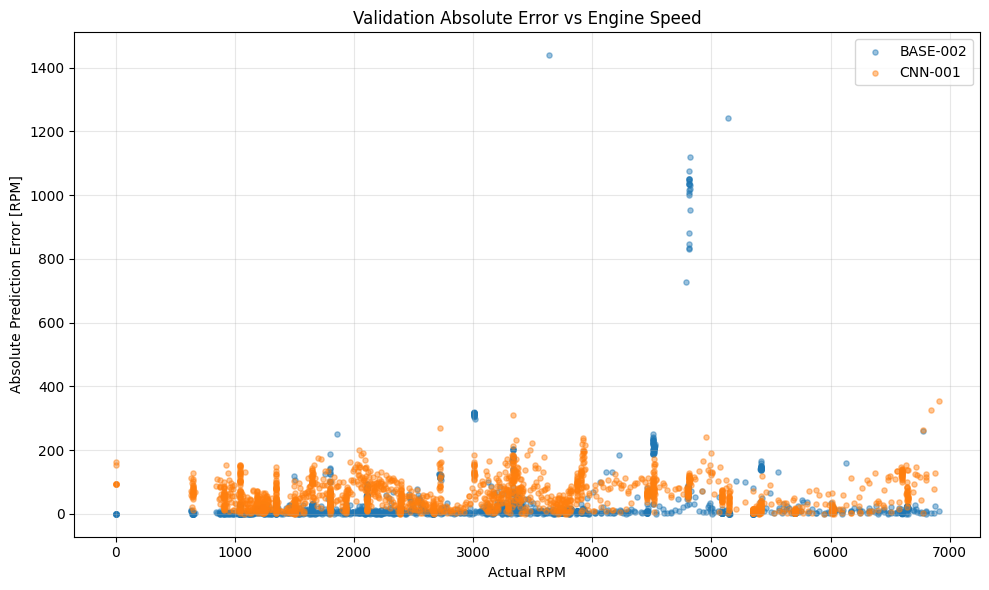

In [18]:
# Step 17.8 — Plot absolute error versus actual RPM
# This will tell us whether one model has trouble in a particular
# engine-speed region

# ============================================================
# STEP 17.8 — ERROR VS RPM
# ============================================================

import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(10, 6)
)


ax.scatter(
    validation_error_comparison[
        "actual_rpm"
    ],
    validation_error_comparison[
        "base002_absolute_error_rpm"
    ],
    s=14,
    alpha=0.45,
    label="BASE-002",
)


ax.scatter(
    validation_error_comparison[
        "actual_rpm"
    ],
    validation_error_comparison[
        "cnn001_absolute_error_rpm"
    ],
    s=14,
    alpha=0.45,
    label="CNN-001",
)


ax.set_xlabel(
    "Actual RPM"
)

ax.set_ylabel(
    "Absolute Prediction Error [RPM]"
)

ax.set_title(
    "Validation Absolute Error vs Engine Speed"
)

ax.legend()

ax.grid(
    True,
    alpha=0.3,
)


fig.tight_layout()


ERROR_VS_RPM_PATH = (
    CNN_FIGURE_DIR
    / "03_cnn001_vs_base002_validation_error_vs_rpm.png"
)


fig.savefig(
    ERROR_VS_RPM_PATH,
    dpi=300,
    bbox_inches="tight",
)


plt.show()
plt.close(fig)

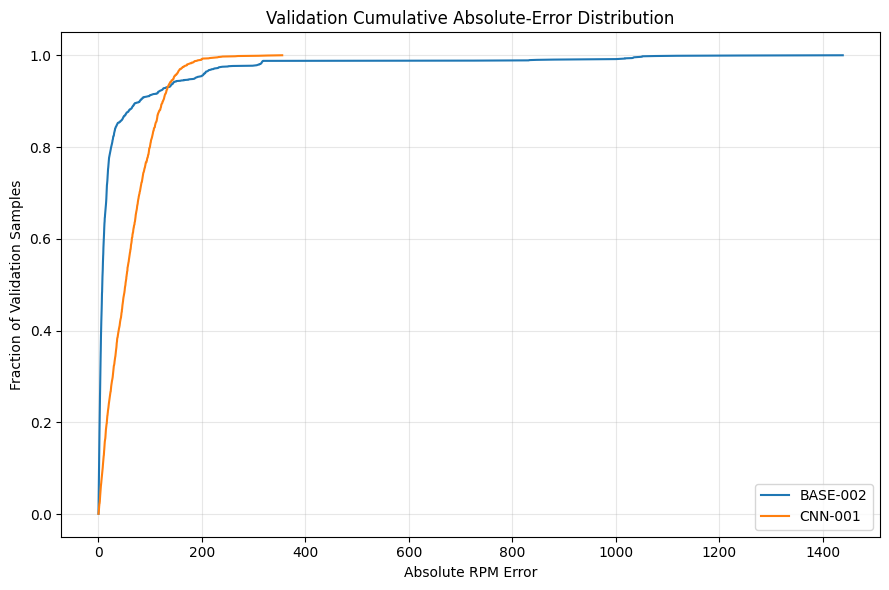

In [19]:
# Step 17.9 — Plot cumulative error distribution
# This is especially useful given our MAE/RMSE/P95 disagreement.

# ============================================================
# STEP 17.9 — CUMULATIVE ABSOLUTE-ERROR DISTRIBUTION
# ============================================================

base_sorted = np.sort(
    base_errors.to_numpy()
)

cnn_sorted = np.sort(
    cnn_errors.to_numpy()
)


base_cdf = (
    np.arange(
        1,
        len(base_sorted) + 1
    )
    /
    len(base_sorted)
)


cnn_cdf = (
    np.arange(
        1,
        len(cnn_sorted) + 1
    )
    /
    len(cnn_sorted)
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)


ax.plot(
    base_sorted,
    base_cdf,
    label="BASE-002",
)

ax.plot(
    cnn_sorted,
    cnn_cdf,
    label="CNN-001",
)


ax.set_xlabel(
    "Absolute RPM Error"
)

ax.set_ylabel(
    "Fraction of Validation Samples"
)

ax.set_title(
    "Validation Cumulative Absolute-Error Distribution"
)

ax.legend()

ax.grid(
    True,
    alpha=0.3,
)


fig.tight_layout()


ERROR_CDF_PATH = (
    CNN_FIGURE_DIR
    / "04_cnn001_vs_base002_validation_error_cdf.png"
)


fig.savefig(
    ERROR_CDF_PATH,
    dpi=300,
    bbox_inches="tight",
)


plt.show()
plt.close(fig)

# Interpretation:
# curve farther left = better;
# if BASE-002 is farther left early but CNN-001 crosses it in the upper tail,
# that explains our current metrics very nicely.

In [20]:
# Step 17.10 — Inspect the worst BASE-002 errors
# This tests the hypothesis that BASE-002 has a relatively small number of
# very large misses

# ============================================================
# STEP 17.10 — WORST BASE-002 VALIDATION ERRORS
# ============================================================

worst_base002 = (
    validation_error_comparison
    .sort_values(
        "base002_absolute_error_rpm",
        ascending=False,
    )
    .head(20)
)


display(
    worst_base002[
        [
            "sample_id",
            "actual_rpm",
            "base002_predicted_rpm",
            "base002_absolute_error_rpm",
            "cnn001_predicted_rpm",
            "cnn001_absolute_error_rpm",
            "better_model",
        ]
    ]
)

,sample_id,actual_rpm,base002_predicted_rpm,base002_absolute_error_rpm,cnn001_predicted_rpm,cnn001_absolute_error_rpm,better_model
1331,A-0573__W00017,3634.454346,5073.353269,1438.898974,3653.135742,18.681396,CNN-001
1423,A-0616__W00006,5136.039551,3894.280394,1241.759009,5133.106934,2.932617,CNN-001
1165,A-0544__W00000,4818.354492,3699.602494,1118.752164,4927.401367,109.046875,CNN-001
1184,A-0544__W00019,4814.528809,3738.447005,1076.081759,4926.688477,112.159668,CNN-001
1168,A-0544__W00003,4815.365234,3763.996637,1051.368385,4928.627930,113.262695,CNN-001
1172,A-0544__W00007,4815.118164,3763.999909,1051.118340,4920.258301,105.140137,CNN-001
1170,A-0544__W00005,4814.148438,3764.536036,1049.612326,4925.884277,111.735840,CNN-001
1167,A-0544__W00002,4816.104492,3772.716564,1043.388039,4944.009277,127.904785,CNN-001
1171,A-0544__W00006,4815.166016,3779.984935,1035.181271,4928.062500,112.896484,CNN-001
1173,A-0544__W00008,4814.210449,3779.984935,1034.225410,4934.106445,119.895996,CNN-001


In [21]:
# ..Save

WORST_BASE002_PATH = (
    CNN_TABLE_DIR
    / "base002_worst_validation_errors_v001.csv"
)


worst_base002.to_csv(
    WORST_BASE002_PATH,
    index=False,
)

In [22]:
# Step 17.11 — Inspect the worst CNN-001 errors

# ============================================================
# STEP 17.11 — WORST CNN-001 VALIDATION ERRORS
# ============================================================

worst_cnn001 = (
    validation_error_comparison
    .sort_values(
        "cnn001_absolute_error_rpm",
        ascending=False,
    )
    .head(20)
)


display(
    worst_cnn001[
        [
            "sample_id",
            "actual_rpm",
            "cnn001_predicted_rpm",
            "cnn001_absolute_error_rpm",
            "base002_predicted_rpm",
            "base002_absolute_error_rpm",
            "better_model",
        ]
    ]
)

,sample_id,actual_rpm,cnn001_predicted_rpm,cnn001_absolute_error_rpm,base002_predicted_rpm,base002_absolute_error_rpm,better_model
1245,A-0564__W00010,6908.601074,6553.422852,355.178223,6917.115831,8.514922,BASE-002
1244,A-0564__W00009,6845.769043,6518.832031,326.937012,6841.842711,3.926205,BASE-002
221,A-0140__W00011,3332.397705,3641.760010,309.362305,3155.896731,176.500857,BASE-002
1388,A-0604__W00009,2723.793945,2993.289551,269.495605,2844.348484,120.554609,BASE-002
1243,A-0564__W00008,6777.923828,6513.814453,264.109375,6518.312867,259.610902,BASE-002
1219,A-0563__W00007,4954.910156,5194.747070,239.836914,4950.097695,4.812691,BASE-002
665,A-0326__W00011,3918.372803,4155.534668,237.161865,3916.450405,1.922335,BASE-002
299,A-0175__W00007,3363.169922,3131.416016,231.753906,3362.880926,0.289075,BASE-002
670,A-0326__W00016,3922.628418,4153.062988,230.434570,3917.263207,5.365240,BASE-002
1324,A-0573__W00010,3496.472900,3272.812500,223.660400,3505.214010,8.741003,BASE-002


In [23]:
# ..Save

WORST_CNN001_PATH = (
    CNN_TABLE_DIR
    / "cnn001_worst_validation_errors_v001.csv"
)


worst_cnn001.to_csv(
    WORST_CNN001_PATH,
    index=False,
)

In [24]:
# Step 18 — Freeze the CNN-001 validation conclusion

# Because MAE was frozen as the primary metric, we should record:
# CNN-001 is not selected over BASE-002.

# However:
# CNN-001 has substantially better RMSE, R² and P95 behavior.

# Therefore:
# CNN-001 is useful evidence, not a failed experiment.

# Step 18.1 — Create the final CNN-001 validation decision report

# ============================================================
# STEP 18.1 — CNN-001 VALIDATION DECISION REPORT
# ============================================================

CNN001_DECISION_REPORT_PATH = (
    REPORT_DIR
    / "cnn001_validation_decision_v001.md"
)


base_row = (
    error_distribution_summary.loc[
        error_distribution_summary[
            "model"
        ] == "BASE-002"
    ]
    .iloc[0]
)

cnn_row = (
    error_distribution_summary.loc[
        error_distribution_summary[
            "model"
        ] == "CNN-001"
    ]
    .iloc[0]
)


report_text = f"""# CNN-001 Validation Decision — v001

## Objective

CNN-001 evaluates whether a convolutional neural network operating
directly on log-mel spectrograms can improve steady-state RPM
prediction relative to the conventional BASE-002 Random Forest.

## Primary selection metric

Validation MAE was frozen as the primary selection metric before
CNN-001 evaluation.

## Aggregate validation results

| Metric | BASE-002 | CNN-001 |
|---|---:|---:|
| MAE [RPM] | 37.62 | 60.19 |
| RMSE [RPM] | 127.39 | 76.36 |
| R² | 0.994132 | 0.997892 |
| P95 absolute error [RPM] | 186.70 | 145.33 |

## Decision

CNN-001 does not replace BASE-002 because its validation MAE is
higher than the frozen BASE-002 benchmark.

BASE-002 therefore remains the preferred RPM baseline according to
the pre-defined selection policy.

## Important secondary result

CNN-001 nevertheless demonstrates substantially lower RMSE, higher
R², and lower P95 absolute error.

This indicates that the two models have materially different error
distributions. The CNN appears to control larger errors more
effectively, while the Random Forest achieves lower average absolute
error.

Sample-level validation diagnostics were therefore performed before
defining the next CNN experiment.

## Test-set status

CNN-001 has not been evaluated on the frozen test set.

The test set remains untouched because CNN-001 was not selected by
the primary validation metric.

## Next model iteration

CNN-002 will preserve:

- PREP-001
- SPLIT-001
- SAMPLE-MANIFEST-001
- the CNN log-mel representation
- CNN-001 architecture
- optimizer
- learning rate
- training population

The primary experimental change will be the regression loss.

CNN-002 will replace MSELoss with SmoothL1Loss so that the effect of
the loss function on validation MAE can be evaluated independently
from changes in network architecture.

The frozen primary comparison metric remains validation MAE.
"""


CNN001_DECISION_REPORT_PATH.write_text(
    report_text,
    encoding="utf-8",
)


print(
    f"Saved:\n"
    f"{CNN001_DECISION_REPORT_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/reports/cnn001_validation_decision_v001.md


In [25]:
# Step 18.2 — Define CNN-002
# The next experiment should change one meaningful thing only.
# Use Smooth L1 loss rather than making the network deeper at the same time.

# ============================================================
# STEP 18.2 — CREATE CNN-002 SPECIFICATION
# ============================================================

import copy
import yaml


CNN001_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v001.yaml"
)


with open(
    CNN001_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:

    cnn001_config = yaml.safe_load(
        file
    )


cnn002_config = copy.deepcopy(
    cnn001_config
)


cnn002_config[
    "specification"
]["model_version"] = (
    "CNN-002"
)


cnn002_config[
    "specification"
]["status"] = (
    "planned_validation_iteration"
)


cnn002_config[
    "training"
]["loss"] = (
    "SmoothL1Loss"
)


cnn002_config[
    "training"
][
    "smooth_l1_beta_standardized_rpm"
] = 0.5


cnn002_config[
    "experiment_rationale"
] = (
    "CNN-001 produced higher validation MAE "
    "than BASE-002 but lower RMSE, higher R2, "
    "and lower P95 error. CNN-002 isolates the "
    "effect of the regression loss by replacing "
    "MSELoss with SmoothL1Loss while keeping "
    "the data representation, CNN architecture, "
    "optimizer, learning rate, split, and "
    "population unchanged."
)


CNN002_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v002.yaml"
)


with open(
    CNN002_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        cnn002_config,
        file,
        sort_keys=False,
    )


print(
    f"Created:\n"
    f"{CNN002_CONFIG_PATH}"
)


Created:
/content/engine-nvh-deep-learning/configs/cnn_rpm_v002.yaml


In [26]:
# ..Validate it

# ============================================================
# STEP 18.3 — VALIDATE CNN-002 SPECIFICATION
# ============================================================

with open(
    CNN002_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:

    cnn002_check = yaml.safe_load(
        file
    )


assert (
    cnn002_check[
        "specification"
    ]["model_version"]
    == "CNN-002"
)

assert (
    cnn002_check[
        "training"
    ]["loss"]
    == "SmoothL1Loss"
)

assert (
    cnn002_check[
        "training"
    ][
        "smooth_l1_beta_standardized_rpm"
    ]
    == 0.5
)


print(
    "PASS: CNN-002 specification validated."
)

PASS: CNN-002 specification validated.


In [27]:
# Step 19 — Save the current Notebook 08
# Save: notebooks/08_cnn_rpm_model.ipynb
# directly to GitHub through Colab before running the Git commands below.

# Step 20 — Stage the new analysis artifacts
# ============================================================
# STEP 20 — STAGE CNN VALIDATION-ANALYSIS ARTIFACTS
# ============================================================

import subprocess


paths_to_add = [
    "configs/cnn_rpm_v002.yaml",
    "reports/cnn001_validation_decision_v001.md",
    "results/tables/cnn_rpm",
    "results/figures/cnn_rpm",
]


existing_paths = [
    path
    for path in paths_to_add
    if (
        REPO_DIR
        / path
    ).exists()
]


subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "add",
        *existing_paths,
    ],
    check=True,
)


status_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--short",
    ],
    capture_output=True,
    text=True,
    check=True,
)


print(
    status_result.stdout
)

A  configs/cnn_rpm_v002.yaml
A  reports/cnn001_validation_decision_v001.md
A  results/figures/cnn_rpm/03_cnn001_vs_base002_validation_error_vs_rpm.png
A  results/figures/cnn_rpm/04_cnn001_vs_base002_validation_error_cdf.png
A  results/tables/cnn_rpm/base002_worst_validation_errors_v001.csv
A  results/tables/cnn_rpm/cnn001_vs_base002_error_distribution_v001.csv
A  results/tables/cnn_rpm/cnn001_vs_base002_error_quantiles_v001.csv
A  results/tables/cnn_rpm/cnn001_vs_base002_sample_win_summary_v001.csv
A  results/tables/cnn_rpm/cnn001_vs_base002_validation_predictions_v001.csv
A  results/tables/cnn_rpm/cnn001_worst_validation_errors_v001.csv



In [28]:
# Step 21 — Commit the CNN-001 diagnosis and CNN-002 specification

# ============================================================
# STEP 21 — COMMIT VALIDATION ANALYSIS
# ============================================================

commit_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "commit",
        "-m",
        "Analyze CNN-001 validation and define CNN-002",
    ],
    capture_output=True,
    text=True,
)


print(
    commit_result.stdout
)


if commit_result.stderr:

    print(
        commit_result.stderr
    )


combined_output = (
    commit_result.stdout
    +
    commit_result.stderr
).lower()


if (
    commit_result.returncode != 0
    and
    "nothing to commit"
    not in combined_output
):

    raise RuntimeError(
        "Git commit failed."
    )

[main 46a9088] Analyze CNN-001 validation and define CNN-002
 10 files changed, 1980 insertions(+)
 create mode 100644 configs/cnn_rpm_v002.yaml
 create mode 100644 reports/cnn001_validation_decision_v001.md
 create mode 100644 results/figures/cnn_rpm/03_cnn001_vs_base002_validation_error_vs_rpm.png
 create mode 100644 results/figures/cnn_rpm/04_cnn001_vs_base002_validation_error_cdf.png
 create mode 100644 results/tables/cnn_rpm/base002_worst_validation_errors_v001.csv
 create mode 100644 results/tables/cnn_rpm/cnn001_vs_base002_error_distribution_v001.csv
 create mode 100644 results/tables/cnn_rpm/cnn001_vs_base002_error_quantiles_v001.csv
 create mode 100644 results/tables/cnn_rpm/cnn001_vs_base002_sample_win_summary_v001.csv
 create mode 100644 results/tables/cnn_rpm/cnn001_vs_base002_validation_predictions_v001.csv
 create mode 100644 results/tables/cnn_rpm/cnn001_worst_validation_errors_v001.csv



In [29]:
# Step 22 — Rebase and push

# ============================================================
# STEP 22 — REBASE AND PUSH
# ============================================================

current_branch = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "branch",
        "--show-current",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


pull_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "pull",
        "--rebase",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)


print(
    pull_result.stdout
)

if pull_result.stderr:
    print(
        pull_result.stderr
    )


if pull_result.returncode != 0:
    raise RuntimeError(
        "git pull --rebase failed."
    )


push_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "push",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)


print(
    push_result.stdout
)

if push_result.stderr:
    print(
        push_result.stderr
    )


if push_result.returncode != 0:
    raise RuntimeError(
        "Git push failed."
    )


print(
    "PASS: Validation analysis pushed."
)


From https://github.com/vaibhavjiyer87/engine-nvh-deep-learning
 * branch            main       -> FETCH_HEAD
   b2527f5..9422eb1  main       -> origin/main
Rebasing (1/1)

Successfully rebased and updated refs/heads/main.


To https://github.com/vaibhavjiyer87/engine-nvh-deep-learning.git
   9422eb1..c2eb5fa  main -> main

PASS: Validation analysis pushed.


In [30]:
# Step 23 — Final synchronization check

# ============================================================
# STEP 23 — VERIFY CLEAN PROJECT STATE
# ============================================================

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "fetch",
        "origin",
    ],
    check=True,
)


local_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        "HEAD",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


remote_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        f"origin/{current_branch}",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


working_tree = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--porcelain",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


print(
    "Local :",
    local_head,
)

print(
    "Remote:",
    remote_head,
)


assert (
    local_head
    ==
    remote_head
)


if working_tree:

    print(
        "\nWARNING: Uncommitted files:"
    )

    print(
        working_tree
    )

else:

    print(
        "\nPASS: Working tree clean."
    )

Local : c2eb5fa3def40dbbf626e20fc03a99da6975d356
Remote: c2eb5fa3def40dbbf626e20fc03a99da6975d356

PASS: Working tree clean.


In [31]:
# Step 24 — Validate CNN-002 as a controlled experiment
# The point of CNN-002 is to change only the regression loss

# CNN-001 = MSELoss
# CNN-002 = SmoothL1Loss(beta=0.5)

# Same:
  # data
  # split
  # log-mel representation
  # architecture
  # optimizer
  # learning rate
  # batch size
  # training population
  # primary metric = validation MAE

# Step 24.1 — Load CNN-001 and CNN-002 configs
# ============================================================
# STEP 24.1 — LOAD CNN-001 AND CNN-002 SPECIFICATIONS
# ============================================================

import yaml
import copy
import numpy as np
import pandas as pd
import torch

CNN001_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v001.yaml"
)

CNN002_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v002.yaml"
)


for path in [
    CNN001_CONFIG_PATH,
    CNN002_CONFIG_PATH,
]:

    if not path.exists():
        raise FileNotFoundError(
            f"Required configuration missing:\n{path}"
        )


with open(
    CNN001_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:

    cnn001_config = yaml.safe_load(
        file
    )


with open(
    CNN002_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:

    cnn002_config = yaml.safe_load(
        file
    )


assert (
    cnn001_config[
        "specification"
    ]["model_version"]
    == "CNN-001"
)

assert (
    cnn002_config[
        "specification"
    ]["model_version"]
    == "CNN-002"
)


print(
    "PASS: CNN-001 and CNN-002 "
    "specifications loaded."
)

PASS: CNN-001 and CNN-002 specifications loaded.


In [32]:
# Step 24.2 — Verify that the important modeling sections are unchanged

# ============================================================
# STEP 24.2 — CONTROLLED-EXPERIMENT AUDIT
# ============================================================

sections_that_must_match = [
    "upstream",
    "population",
    "input_audio",
    "log_mel",
    "normalization",
    "architecture",
]


for section in sections_that_must_match:

    if (
        cnn001_config[section]
        != cnn002_config[section]
    ):

        raise RuntimeError(
            f"CNN-001 and CNN-002 differ "
            f"unexpectedly in section: {section}"
        )


assert (
    cnn001_config[
        "training"
    ]["optimizer"]
    ==
    cnn002_config[
        "training"
    ]["optimizer"]
)

assert (
    cnn001_config[
        "training"
    ]["learning_rate"]
    ==
    cnn002_config[
        "training"
    ]["learning_rate"]
)

assert (
    cnn001_config[
        "training"
    ]["weight_decay"]
    ==
    cnn002_config[
        "training"
    ]["weight_decay"]
)

assert (
    cnn001_config[
        "training"
    ]["batch_size"]
    ==
    cnn002_config[
        "training"
    ]["batch_size"]
)

assert (
    cnn002_config[
        "training"
    ]["loss"]
    == "SmoothL1Loss"
)


CNN002_VERSION = (
    cnn002_config[
        "specification"
    ]["model_version"]
)

CNN002_BETA = float(
    cnn002_config[
        "training"
    ][
        "smooth_l1_beta_standardized_rpm"
    ]
)


print(
    "PASS: CNN-002 is a controlled "
    "loss-function experiment."
)

print(
    f"Version: {CNN002_VERSION}"
)

print(
    f"Loss: SmoothL1Loss"
)

print(
    f"Beta: {CNN002_BETA}"
)

PASS: CNN-002 is a controlled loss-function experiment.
Version: CNN-002
Loss: SmoothL1Loss
Beta: 0.5


In [34]:
# Step 25 — Restore the CNN-002 training-data environment
# Step 25.1 — Restore CNN-001 normalization and the cached log-mel dataset

# ============================================================
# STEP 25.1 — RESTORE CNN TRAINING DATA STATE
# ============================================================

from pathlib import Path
import yaml
import h5py
import numpy as np
import pandas as pd
import torch
import sys
import importlib


# ------------------------------------------------------------
# Persistent log-mel cache
# ------------------------------------------------------------

CNN_LOGMEL_CACHE_PATH = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "CNN-001"
    / "logmel_v001.h5"
)

if not CNN_LOGMEL_CACHE_PATH.exists():
    raise FileNotFoundError(
        "CNN log-mel cache missing:\n"
        f"{CNN_LOGMEL_CACHE_PATH}"
    )


# ------------------------------------------------------------
# Persistent normalization record
# ------------------------------------------------------------

CNN_NORMALIZATION_PATH = (
    REPO_DIR
    / "data"
    / "cnn001_normalization_v001.yaml"
)

if not CNN_NORMALIZATION_PATH.exists():
    raise FileNotFoundError(
        "CNN normalization record missing:\n"
        f"{CNN_NORMALIZATION_PATH}"
    )


with open(
    CNN_NORMALIZATION_PATH,
    "r",
    encoding="utf-8",
) as file:

    normalization_record = yaml.safe_load(
        file
    )


TRAIN_LOGMEL_MEAN = float(
    normalization_record[
        "log_mel"
    ]["mean"]
)

TRAIN_LOGMEL_STD = float(
    normalization_record[
        "log_mel"
    ]["std"]
)

TRAIN_RPM_MEAN = float(
    normalization_record[
        "rpm_target"
    ]["mean_rpm"]
)

TRAIN_RPM_STD = float(
    normalization_record[
        "rpm_target"
    ]["std_rpm"]
)


# ------------------------------------------------------------
# Recover cache split indices
# ------------------------------------------------------------

with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "r",
) as h5:

    cache_shape = (
        h5[
            "log_mel"
        ].shape
    )

    cache_splits = (
        h5[
            "split"
        ]
        .asstr()[:]
    )

    cache_sample_ids = (
        h5[
            "sample_id"
        ]
        .asstr()[:]
    )

    cache_rpm = (
        h5[
            "rpm_mean"
        ][:]
    )


LOG_MEL_SHAPE = (
    int(
        cache_shape[1]
    ),
    int(
        cache_shape[2]
    ),
)


TRAIN_INDICES = np.where(
    cache_splits
    == "train"
)[0]

VALIDATION_INDICES = np.where(
    cache_splits
    == "validation"
)[0]

TEST_INDICES = np.where(
    cache_splits
    == "test"
)[0]


print(
    f"Cache shape: {cache_shape}"
)

print(
    f"Train samples:      "
    f"{len(TRAIN_INDICES):,}"
)

print(
    f"Validation samples: "
    f"{len(VALIDATION_INDICES):,}"
)

print(
    f"Test samples:       "
    f"{len(TEST_INDICES):,}"
)

print(
    f"Log-mel shape:      "
    f"{LOG_MEL_SHAPE}"
)

print(
    "PASS: Cached CNN training data state restored."
)

Cache shape: (11646, 64, 59)
Train samples:      7,958
Validation samples: 1,798
Test samples:       1,890
Log-mel shape:      (64, 59)
PASS: Cached CNN training data state restored.


In [35]:
# Step 25.2 — Restore H5LogMelDataset
# This first verifies that src/cnn_dataset.py exists.

# ============================================================
# STEP 25.2 — RESTORE CNN DATASET CLASS
# ============================================================

CNN_DATASET_MODULE_PATH = (
    REPO_DIR
    / "src"
    / "cnn_dataset.py"
)


if not CNN_DATASET_MODULE_PATH.exists():
    raise FileNotFoundError(
        "Persisted CNN Dataset module is missing:\n"
        f"{CNN_DATASET_MODULE_PATH}"
    )


if str(REPO_DIR) not in sys.path:

    sys.path.insert(
        0,
        str(REPO_DIR),
    )


import src.cnn_dataset

importlib.reload(
    src.cnn_dataset
)


from src.cnn_dataset import (
    H5LogMelDataset
)


print(
    "PASS: H5LogMelDataset restored."
)

PASS: H5LogMelDataset restored.


In [36]:
# Step 25.3 — Recreate the Dataset objects

# ============================================================
# STEP 25.3 — RECREATE CNN DATASETS
# ============================================================

train_dataset = H5LogMelDataset(

    h5_path=
        CNN_LOGMEL_CACHE_PATH,

    indices=
        TRAIN_INDICES,

    logmel_mean=
        TRAIN_LOGMEL_MEAN,

    logmel_std=
        TRAIN_LOGMEL_STD,

    rpm_mean=
        TRAIN_RPM_MEAN,

    rpm_std=
        TRAIN_RPM_STD,
)


validation_dataset = H5LogMelDataset(

    h5_path=
        CNN_LOGMEL_CACHE_PATH,

    indices=
        VALIDATION_INDICES,

    logmel_mean=
        TRAIN_LOGMEL_MEAN,

    logmel_std=
        TRAIN_LOGMEL_STD,

    rpm_mean=
        TRAIN_RPM_MEAN,

    rpm_std=
        TRAIN_RPM_STD,
)


test_dataset = H5LogMelDataset(

    h5_path=
        CNN_LOGMEL_CACHE_PATH,

    indices=
        TEST_INDICES,

    logmel_mean=
        TRAIN_LOGMEL_MEAN,

    logmel_std=
        TRAIN_LOGMEL_STD,

    rpm_mean=
        TRAIN_RPM_MEAN,

    rpm_std=
        TRAIN_RPM_STD,
)


print(
    f"Train Dataset:      "
    f"{len(train_dataset):,}"
)

print(
    f"Validation Dataset: "
    f"{len(validation_dataset):,}"
)

print(
    f"Test Dataset:       "
    f"{len(test_dataset):,}"
)

print(
    "PASS: CNN Dataset objects recreated."
)

Train Dataset:      7,958
Validation Dataset: 1,798
Test Dataset:       1,890
PASS: CNN Dataset objects recreated.


In [38]:
# ============================================================
# EDIT CNN-002 MAXIMUM EPOCHS: 50 -> 25
# ============================================================

import yaml

CNN002_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v002.yaml"
)

with open(
    CNN002_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:

    cnn002_config_edit = yaml.safe_load(
        file
    )

old_value = (
    cnn002_config_edit[
        "training"
    ]["maximum_epochs"]
)

cnn002_config_edit[
    "training"
]["maximum_epochs"] = 25

with open(
    CNN002_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        cnn002_config_edit,
        file,
        sort_keys=False,
    )

print(
    f"CNN-002 maximum_epochs changed "
    f"from {old_value} to "
    f"{cnn002_config_edit['training']['maximum_epochs']}."
)

CNN-002 maximum_epochs changed from 50 to 25.


In [39]:
# Step 26 — Create deterministic CNN-002 DataLoaders
# Step 26.1 — Restore CNN-002 configuration

# ============================================================
# STEP 26.1 — RESTORE CNN-002 CONFIGURATION
# ============================================================

CNN002_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v002.yaml"
)


if not CNN002_CONFIG_PATH.exists():
    raise FileNotFoundError(
        "CNN-002 configuration missing:\n"
        f"{CNN002_CONFIG_PATH}"
    )


with open(
    CNN002_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:

    cnn002_config = yaml.safe_load(
        file
    )


CNN002_VERSION = (
    cnn002_config[
        "specification"
    ]["model_version"]
)


CNN002_RANDOM_SEED = int(
    cnn002_config[
        "training"
    ]["random_seed"]
)


CNN002_BATCH_SIZE = int(
    cnn002_config[
        "training"
    ]["batch_size"]
)


CNN002_BETA = float(
    cnn002_config[
        "training"
    ][
        "smooth_l1_beta_standardized_rpm"
    ]
)


CNN002_LEARNING_RATE = float(
    cnn002_config[
        "training"
    ]["learning_rate"]
)


CNN002_WEIGHT_DECAY = float(
    cnn002_config[
        "training"
    ]["weight_decay"]
)


CNN002_MAX_EPOCHS = int(
    cnn002_config[
        "training"
    ]["maximum_epochs"]
)


CNN002_EARLY_STOPPING_PATIENCE = int(
    cnn002_config[
        "training"
    ][
        "early_stopping_patience"
    ]
)


CNN002_DROPOUT = float(
    cnn002_config[
        "architecture"
    ]["dropout"]
)


assert (
    CNN002_VERSION
    == "CNN-002"
)


print(
    "PASS: CNN-002 configuration restored."
)

print(
    f"Loss beta:     {CNN002_BETA}"
)

print(
    f"Batch size:    {CNN002_BATCH_SIZE}"
)

print(
    f"Maximum epoch: {CNN002_MAX_EPOCHS}"
)

PASS: CNN-002 configuration restored.
Loss beta:     0.5
Batch size:    64
Maximum epoch: 25


In [40]:
# Step 26.2 — Create deterministic loaders

# ============================================================
# STEP 26.2 — CREATE CNN-002 DATALOADERS
# ============================================================

from torch.utils.data import (
    DataLoader
)


cnn002_generator = (
    torch.Generator()
)

cnn002_generator.manual_seed(
    CNN002_RANDOM_SEED
)


cnn002_train_loader = DataLoader(

    train_dataset,

    batch_size=
        CNN002_BATCH_SIZE,

    shuffle=True,

    generator=
        cnn002_generator,

    num_workers=0,
)


cnn002_validation_loader = DataLoader(

    validation_dataset,

    batch_size=
        CNN002_BATCH_SIZE,

    shuffle=False,

    num_workers=0,
)


print(
    "PASS: CNN-002 DataLoaders created."
)

PASS: CNN-002 DataLoaders created.


In [41]:
#..Smoke test

# ============================================================
# STEP 26.3 — DATALOADER SMOKE TEST
# ============================================================

X_batch, y_batch, cache_index_batch = (
    next(
        iter(
            cnn002_train_loader
        )
    )
)


print(
    "X:",
    X_batch.shape,
)

print(
    "y:",
    y_batch.shape,
)


assert torch.isfinite(
    X_batch
).all()

assert torch.isfinite(
    y_batch
).all()


assert (
    X_batch.shape[1]
    == 1
)

assert (
    X_batch.shape[2:]
    == torch.Size(
        LOG_MEL_SHAPE
    )
)


print(
    "PASS: CNN-002 DataLoader smoke test succeeded."
)

X: torch.Size([64, 1, 64, 59])
y: torch.Size([64])
PASS: CNN-002 DataLoader smoke test succeeded.


In [42]:
# Step 27 — Initialize CNN-002

# Step 27.1 — Restore CNN model definition

# ============================================================
# STEP 27.1 — RESTORE CNN MODEL CLASS
# ============================================================

CNN_MODEL_MODULE_PATH = (
    REPO_DIR
    / "src"
    / "cnn_models.py"
)


if not CNN_MODEL_MODULE_PATH.exists():
    raise FileNotFoundError(
        "CNN model module missing:\n"
        f"{CNN_MODEL_MODULE_PATH}"
    )


import src.cnn_models

importlib.reload(
    src.cnn_models
)


from src.cnn_models import (
    CNNRPMRegressor
)


print(
    "PASS: CNNRPMRegressor restored."
)

PASS: CNNRPMRegressor restored.


In [43]:
# Step 27.2 — Set reproducibility seeds
# ============================================================
# STEP 27.2 — CNN-002 REPRODUCIBILITY
# ============================================================

import random

random.seed(
    CNN002_RANDOM_SEED
)

np.random.seed(
    CNN002_RANDOM_SEED
)

torch.manual_seed(
    CNN002_RANDOM_SEED
)


if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        CNN002_RANDOM_SEED
    )


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    f"CNN-002 device: "
    f"{device}"
)

CNN-002 device: cuda


In [44]:
# Step 27.3 — Initialize a fresh model
# Do not initialize CNN-002 from CNN-001 weights

# ============================================================
# STEP 27.3 — INITIALIZE FRESH CNN-002
# ============================================================

cnn002_model = (
    CNNRPMRegressor(
        dropout=
            CNN002_DROPOUT
    )
    .to(
        device
    )
)


parameter_count = sum(
    parameter.numel()
    for parameter
    in cnn002_model.parameters()
)


print(
    f"CNN-002 trainable parameters: "
    f"{parameter_count:,}"
)


CNN-002 trainable parameters: 25,633


In [45]:
# Step 27.4 — Define Smooth-L1 loss and AdamW

# ============================================================
# STEP 27.4 — LOSS AND OPTIMIZER
# ============================================================

import torch.nn as nn


cnn002_criterion = (
    nn.SmoothL1Loss(
        beta=
            CNN002_BETA
    )
)


cnn002_optimizer = (
    torch.optim.AdamW(

        cnn002_model.parameters(),

        lr=
            CNN002_LEARNING_RATE,

        weight_decay=
            CNN002_WEIGHT_DECAY,
    )
)


print(
    "CNN-002 training setup:"
)

print(
    f"Loss: SmoothL1Loss("
    f"beta={CNN002_BETA})"
)

print(
    f"Learning rate: "
    f"{CNN002_LEARNING_RATE}"
)

print(
    f"Weight decay: "
    f"{CNN002_WEIGHT_DECAY}"
)

CNN-002 training setup:
Loss: SmoothL1Loss(beta=0.5)
Learning rate: 0.001
Weight decay: 0.0001


In [46]:
# Step 28 — Create crash-safe CNN-002 persistence
# Step 28.1 — Define checkpoint paths

# ============================================================
# STEP 28.1 — CNN-002 PERSISTENT CHECKPOINT PATHS
# ============================================================

CNN_MODEL_DIR = (
    PROJECT_DRIVE
    / "models"
    / "cnn"
)

CNN_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


CNN002_BEST_MODEL_PATH = (
    CNN_MODEL_DIR
    / "cnn002_rpm_best_v001.pt"
)


CNN002_LATEST_MODEL_PATH = (
    CNN_MODEL_DIR
    / "cnn002_rpm_latest_v001.pt"
)


CNN002_LIVE_HISTORY_PATH = (
    CNN_MODEL_DIR
    / "cnn002_training_history_live_v001.csv"
)


print(
    "Best checkpoint:"
)

print(
    CNN002_BEST_MODEL_PATH
)

print()

print(
    "Latest checkpoint:"
)

print(
    CNN002_LATEST_MODEL_PATH
)

Best checkpoint:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/models/cnn/cnn002_rpm_best_v001.pt

Latest checkpoint:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/models/cnn/cnn002_rpm_latest_v001.pt


In [47]:
# Step 29 — Train CNN-002
# Step 29.1 — Define reusable validation function

# ============================================================
# STEP 29.1 — CNN REGRESSION EVALUATION FUNCTION
# ============================================================

def evaluate_cnn_regression(
    model,
    data_loader,
    loss_function,
    device,
    rpm_mean,
    rpm_std,
):

    model.eval()

    loss_sum = 0.0
    sample_count = 0

    true_rpm = []
    predicted_rpm = []


    with torch.no_grad():

        for (
            X,
            y_standardized,
            _
        ) in data_loader:

            X = X.to(
                device
            )

            y_standardized = (
                y_standardized.to(
                    device
                )
            )


            prediction_standardized = (
                model(
                    X
                )
            )


            loss = loss_function(
                prediction_standardized,
                y_standardized,
            )


            batch_size_actual = (
                X.shape[0]
            )


            loss_sum += (
                loss.item()
                * batch_size_actual
            )

            sample_count += (
                batch_size_actual
            )


            true_batch = (
                y_standardized
                .detach()
                .cpu()
                .numpy()
                * rpm_std
                + rpm_mean
            )


            predicted_batch = (
                prediction_standardized
                .detach()
                .cpu()
                .numpy()
                * rpm_std
                + rpm_mean
            )


            true_rpm.extend(
                true_batch
            )

            predicted_rpm.extend(
                predicted_batch
            )


    return {

        "loss":
            float(
                loss_sum
                / sample_count
            ),

        "mae_rpm":
            float(
                np.mean(
                    np.abs(
                        np.asarray(
                            predicted_rpm
                        )
                        -
                        np.asarray(
                            true_rpm
                        )
                    )
                )
            ),

        "y_true":
            np.asarray(
                true_rpm
            ),

        "y_pred":
            np.asarray(
                predicted_rpm
            ),
    }


print(
    "PASS: CNN evaluation function ready."
)

PASS: CNN evaluation function ready.


In [48]:
# Step 29.2 — Train with durable checkpointing

# ============================================================
# STEP 29.2 — TRAIN CNN-002
# ============================================================

cnn002_training_history = []

best_validation_mae = np.inf

best_epoch = None

epochs_without_improvement = 0


for epoch in range(
    1,
    CNN002_MAX_EPOCHS + 1,
):

    cnn002_model.train()

    train_loss_sum = 0.0
    train_sample_count = 0


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    for (
        X,
        y_standardized,
        _
    ) in cnn002_train_loader:

        X = X.to(
            device
        )

        y_standardized = (
            y_standardized.to(
                device
            )
        )


        cnn002_optimizer.zero_grad()


        prediction = (
            cnn002_model(
                X
            )
        )


        loss = (
            cnn002_criterion(
                prediction,
                y_standardized,
            )
        )


        loss.backward()

        cnn002_optimizer.step()


        batch_size_actual = (
            X.shape[0]
        )


        train_loss_sum += (
            loss.item()
            * batch_size_actual
        )

        train_sample_count += (
            batch_size_actual
        )


    train_loss = (
        train_loss_sum
        / train_sample_count
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    validation_result = (
        evaluate_cnn_regression(

            model=
                cnn002_model,

            data_loader=
                cnn002_validation_loader,

            loss_function=
                cnn002_criterion,

            device=
                device,

            rpm_mean=
                TRAIN_RPM_MEAN,

            rpm_std=
                TRAIN_RPM_STD,
        )
    )


    validation_loss = float(
        validation_result[
            "loss"
        ]
    )


    validation_mae = float(
        validation_result[
            "mae_rpm"
        ]
    )


    epoch_record = {

        "epoch":
            epoch,

        "train_loss":
            train_loss,

        "validation_loss":
            validation_loss,

        "validation_mae_rpm":
            validation_mae,

        "learning_rate":
            float(
                cnn002_optimizer
                .param_groups[0]["lr"]
            ),

        "device":
            str(
                device
            ),
    }


    cnn002_training_history.append(
        epoch_record
    )


    print(
        f"Epoch {epoch:02d} | "
        f"train loss "
        f"{train_loss:.5f} | "
        f"val loss "
        f"{validation_loss:.5f} | "
        f"val MAE "
        f"{validation_mae:.2f} RPM"
    )


    # --------------------------------------------------------
    # BEST CHECKPOINT
    # --------------------------------------------------------

    if (
        validation_mae
        <
        best_validation_mae
    ):

        best_validation_mae = (
            validation_mae
        )

        best_epoch = (
            epoch
        )

        epochs_without_improvement = 0


        torch.save(
            {

                "model_version":
                    "CNN-002",

                "epoch":
                    epoch,

                "model_state_dict":
                    cnn002_model.state_dict(),

                "optimizer_state_dict":
                    cnn002_optimizer.state_dict(),

                "validation_mae_rpm":
                    validation_mae,

                "train_logmel_mean":
                    TRAIN_LOGMEL_MEAN,

                "train_logmel_std":
                    TRAIN_LOGMEL_STD,

                "train_rpm_mean":
                    TRAIN_RPM_MEAN,

                "train_rpm_std":
                    TRAIN_RPM_STD,

                "log_mel_shape":
                    LOG_MEL_SHAPE,

                "cnn_config":
                    cnn002_config,
            },

            CNN002_BEST_MODEL_PATH,
        )


        print(
            "  -> saved NEW BEST checkpoint"
        )


    else:

        epochs_without_improvement += 1


    # --------------------------------------------------------
    # ALWAYS SAVE LATEST COMPLETED EPOCH
    # --------------------------------------------------------

    torch.save(
        {

            "model_version":
                "CNN-002",

            "epoch":
                epoch,

            "model_state_dict":
                cnn002_model.state_dict(),

            "optimizer_state_dict":
                cnn002_optimizer.state_dict(),

            "validation_mae_rpm":
                validation_mae,

            "best_validation_mae_rpm":
                best_validation_mae,

            "best_epoch":
                best_epoch,

            "epochs_without_improvement":
                epochs_without_improvement,

            "train_logmel_mean":
                TRAIN_LOGMEL_MEAN,

            "train_logmel_std":
                TRAIN_LOGMEL_STD,

            "train_rpm_mean":
                TRAIN_RPM_MEAN,

            "train_rpm_std":
                TRAIN_RPM_STD,

            "log_mel_shape":
                LOG_MEL_SHAPE,

            "cnn_config":
                cnn002_config,
        },

        CNN002_LATEST_MODEL_PATH,
    )


    # --------------------------------------------------------
    # PERSIST HISTORY AFTER EVERY EPOCH
    # --------------------------------------------------------

    pd.DataFrame(
        cnn002_training_history
    ).to_csv(
        CNN002_LIVE_HISTORY_PATH,
        index=False,
    )


    print(
        f"  -> recovery state saved "
        f"through Epoch {epoch}"
    )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if (
        epochs_without_improvement
        >=
        CNN002_EARLY_STOPPING_PATIENCE
    ):

        print()

        print(
            "Early stopping triggered."
        )

        break


print()
print("=" * 65)

print(
    f"CNN-002 best epoch: "
    f"{best_epoch}"
)

print(
    f"CNN-002 best validation MAE: "
    f"{best_validation_mae:.2f} RPM"
)

print("=" * 65)

Epoch 01 | train loss 0.09805 | val loss 0.01461 | val MAE 164.82 RPM
  -> saved NEW BEST checkpoint
  -> recovery state saved through Epoch 1
Epoch 02 | train loss 0.05281 | val loss 0.04125 | val MAE 270.54 RPM
  -> recovery state saved through Epoch 2
Epoch 03 | train loss 0.04332 | val loss 0.00962 | val MAE 128.35 RPM
  -> saved NEW BEST checkpoint
  -> recovery state saved through Epoch 3
Epoch 04 | train loss 0.03938 | val loss 0.01105 | val MAE 150.90 RPM
  -> recovery state saved through Epoch 4
Epoch 05 | train loss 0.04209 | val loss 0.00723 | val MAE 118.81 RPM
  -> saved NEW BEST checkpoint
  -> recovery state saved through Epoch 5
Epoch 06 | train loss 0.03706 | val loss 0.02173 | val MAE 196.45 RPM
  -> recovery state saved through Epoch 6
Epoch 07 | train loss 0.03827 | val loss 0.00542 | val MAE 101.62 RPM
  -> saved NEW BEST checkpoint
  -> recovery state saved through Epoch 7
Epoch 08 | train loss 0.03357 | val loss 0.03627 | val MAE 259.85 RPM
  -> recovery state sa

A fresh Colab session was started after this cell on 08/20/26

In [6]:
# Step 29.3 — Restore CNN-002 evaluation environment

# ============================================================
# STEP 29.3 — RESTORE CNN-002 EVALUATION ENVIRONMENT
# ============================================================

import sys
import importlib
import yaml
import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import DataLoader


# ------------------------------------------------------------
# Load CNN-002 configuration
# ------------------------------------------------------------

CNN002_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v002.yaml"
)

if not CNN002_CONFIG_PATH.exists():

    raise FileNotFoundError(
        "CNN-002 configuration missing:\n"
        f"{CNN002_CONFIG_PATH}"
    )


with open(
    CNN002_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:

    cnn002_config = yaml.safe_load(
        file
    )


CNN002_VERSION = (
    cnn002_config[
        "specification"
    ]["model_version"]
)

CNN002_DROPOUT = float(
    cnn002_config[
        "architecture"
    ]["dropout"]
)

CNN002_BATCH_SIZE = int(
    cnn002_config[
        "training"
    ]["batch_size"]
)

CNN002_BETA = float(
    cnn002_config[
        "training"
    ][
        "smooth_l1_beta_standardized_rpm"
    ]
)


assert CNN002_VERSION == "CNN-002"


# ------------------------------------------------------------
# Restore training-only normalization
# ------------------------------------------------------------

CNN_NORMALIZATION_PATH = (
    REPO_DIR
    / "data"
    / "cnn001_normalization_v001.yaml"
)

if not CNN_NORMALIZATION_PATH.exists():

    raise FileNotFoundError(
        "CNN normalization record missing:\n"
        f"{CNN_NORMALIZATION_PATH}"
    )


with open(
    CNN_NORMALIZATION_PATH,
    "r",
    encoding="utf-8",
) as file:

    normalization_record = yaml.safe_load(
        file
    )


TRAIN_LOGMEL_MEAN = float(
    normalization_record[
        "log_mel"
    ]["mean"]
)

TRAIN_LOGMEL_STD = float(
    normalization_record[
        "log_mel"
    ]["std"]
)

TRAIN_RPM_MEAN = float(
    normalization_record[
        "rpm_target"
    ]["mean_rpm"]
)

TRAIN_RPM_STD = float(
    normalization_record[
        "rpm_target"
    ]["std_rpm"]
)


# ------------------------------------------------------------
# Restore persistent log-mel cache
# ------------------------------------------------------------

CNN_LOGMEL_CACHE_PATH = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "CNN-001"
    / "logmel_v001.h5"
)

if not CNN_LOGMEL_CACHE_PATH.exists():

    raise FileNotFoundError(
        "CNN log-mel cache missing:\n"
        f"{CNN_LOGMEL_CACHE_PATH}"
    )


with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "r",
) as h5:

    cache_shape = (
        h5["log_mel"].shape
    )

    cache_splits = (
        h5["split"]
        .asstr()[:]
    )


LOG_MEL_SHAPE = (
    int(cache_shape[1]),
    int(cache_shape[2]),
)


VALIDATION_INDICES = np.where(
    cache_splits
    == "validation"
)[0]


# ------------------------------------------------------------
# Restore physical Python modules
# ------------------------------------------------------------

if str(REPO_DIR) not in sys.path:

    sys.path.insert(
        0,
        str(REPO_DIR),
    )


import src.cnn_dataset
import src.cnn_models

importlib.reload(
    src.cnn_dataset
)

importlib.reload(
    src.cnn_models
)


from src.cnn_dataset import (
    H5LogMelDataset
)

from src.cnn_models import (
    CNNRPMRegressor
)


# ------------------------------------------------------------
# Recreate validation Dataset / DataLoader
# ------------------------------------------------------------

validation_dataset = H5LogMelDataset(

    h5_path=
        CNN_LOGMEL_CACHE_PATH,

    indices=
        VALIDATION_INDICES,

    logmel_mean=
        TRAIN_LOGMEL_MEAN,

    logmel_std=
        TRAIN_LOGMEL_STD,

    rpm_mean=
        TRAIN_RPM_MEAN,

    rpm_std=
        TRAIN_RPM_STD,
)


cnn002_validation_loader = DataLoader(

    validation_dataset,

    batch_size=
        CNN002_BATCH_SIZE,

    shuffle=False,

    num_workers=0,
)


# ------------------------------------------------------------
# Restore CNN-002 validation loss
# ------------------------------------------------------------

cnn002_criterion = nn.SmoothL1Loss(
    beta=
        CNN002_BETA
)


# Evaluation can run on either available GPU or CPU.
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ------------------------------------------------------------
# Restore persistent model paths
# ------------------------------------------------------------

CNN_MODEL_DIR = (
    PROJECT_DRIVE
    / "models"
    / "cnn"
)

CNN002_BEST_MODEL_PATH = (
    CNN_MODEL_DIR
    / "cnn002_rpm_best_v001.pt"
)

CNN002_LATEST_MODEL_PATH = (
    CNN_MODEL_DIR
    / "cnn002_rpm_latest_v001.pt"
)


print("=" * 68)
print("CNN-002 EVALUATION ENVIRONMENT RESTORED")
print("=" * 68)

print(
    f"Model version:       "
    f"{CNN002_VERSION}"
)

print(
    f"Validation samples:  "
    f"{len(VALIDATION_INDICES):,}"
)

print(
    f"Log-mel shape:       "
    f"{LOG_MEL_SHAPE}"
)

print(
    f"SmoothL1 beta:       "
    f"{CNN002_BETA}"
)

print(
    f"Evaluation device:   "
    f"{device}"
)

print("=" * 68)

CNN-002 EVALUATION ENVIRONMENT RESTORED
Model version:       CNN-002
Validation samples:  1,798
Log-mel shape:       (64, 59)
SmoothL1 beta:       0.5
Evaluation device:   cuda


In [7]:
# Step 29.4 — Verify the persisted CNN-002 training result
# Before moving forward, confirm that the persistent best checkpoint
# really is the Epoch-7 model you expect.

# ============================================================
# STEP 29.4 — VERIFY CNN-002 BEST CHECKPOINT
# ============================================================

if not CNN002_BEST_MODEL_PATH.exists():

    raise FileNotFoundError(
        "CNN-002 best checkpoint missing:\n"
        f"{CNN002_BEST_MODEL_PATH}"
    )


checkpoint_check = torch.load(
    CNN002_BEST_MODEL_PATH,
    map_location="cpu",
    weights_only=False,
)


assert (
    checkpoint_check[
        "model_version"
    ]
    == "CNN-002"
)


BEST_CNN002_EPOCH = int(
    checkpoint_check[
        "epoch"
    ]
)

BEST_CNN002_VALIDATION_MAE = float(
    checkpoint_check[
        "validation_mae_rpm"
    ]
)


print(
    f"Model version:       "
    f"{checkpoint_check['model_version']}"
)

print(
    f"Best epoch:          "
    f"{BEST_CNN002_EPOCH}"
)

print(
    f"Best validation MAE: "
    f"{BEST_CNN002_VALIDATION_MAE:.2f} RPM"
)


if BEST_CNN002_EPOCH != 7:

    print()
    print(
        "WARNING: Persistent best checkpoint "
        "is not Epoch 7."
    )

    print(
        "Do not continue until we inspect why."
    )

else:

    print()
    print(
        "PASS: Persistent CNN-002 best "
        "checkpoint is Epoch 7."
    )

Model version:       CNN-002
Best epoch:          7
Best validation MAE: 101.62 RPM

PASS: Persistent CNN-002 best checkpoint is Epoch 7.


In [8]:
# Step 29.5 — Restore the evaluation function
# Because it was a notebook-memory function, it disappeared with the old runtime

# ============================================================
# STEP 29.5 — RESTORE CNN REGRESSION EVALUATION FUNCTION
# ============================================================

def evaluate_cnn_regression(
    model,
    data_loader,
    loss_function,
    device,
    rpm_mean,
    rpm_std,
):

    model.eval()

    loss_sum = 0.0
    sample_count = 0

    true_rpm = []
    predicted_rpm = []


    with torch.no_grad():

        for (
            X,
            y_standardized,
            _
        ) in data_loader:

            X = X.to(
                device
            )

            y_standardized = (
                y_standardized.to(
                    device
                )
            )


            prediction_standardized = (
                model(
                    X
                )
            )


            loss = loss_function(
                prediction_standardized,
                y_standardized,
            )


            batch_size_actual = (
                X.shape[0]
            )


            loss_sum += (
                loss.item()
                * batch_size_actual
            )

            sample_count += (
                batch_size_actual
            )


            true_batch = (
                y_standardized
                .cpu()
                .numpy()
                * rpm_std
                + rpm_mean
            )


            predicted_batch = (
                prediction_standardized
                .cpu()
                .numpy()
                * rpm_std
                + rpm_mean
            )


            true_rpm.extend(
                true_batch
            )

            predicted_rpm.extend(
                predicted_batch
            )


    return {

        "loss":
            float(
                loss_sum
                / sample_count
            ),

        "mae_rpm":
            float(
                np.mean(
                    np.abs(
                        np.asarray(
                            predicted_rpm
                        )
                        -
                        np.asarray(
                            true_rpm
                        )
                    )
                )
            ),

        "y_true":
            np.asarray(
                true_rpm
            ),

        "y_pred":
            np.asarray(
                predicted_rpm
            ),
    }


print(
    "PASS: CNN evaluation function restored."
)

PASS: CNN evaluation function restored.


In [9]:
# Step 30 — Evaluate the best CNN-002 model
# Step 30.1 — Reload the best checkpoint
# ============================================================
# STEP 30.1 — RELOAD BEST CNN-002
# ============================================================

best_cnn002_checkpoint = torch.load(
    CNN002_BEST_MODEL_PATH,
    map_location=device,
    weights_only=False,
)


best_cnn002_model = (
    CNNRPMRegressor(
        dropout=
            CNN002_DROPOUT
    )
    .to(
        device
    )
)


best_cnn002_model.load_state_dict(
    best_cnn002_checkpoint[
        "model_state_dict"
    ]
)


best_cnn002_model.eval()


print(
    f"Best epoch: "
    f"{best_cnn002_checkpoint['epoch']}"
)

print(
    f"Stored validation MAE: "
    f"{best_cnn002_checkpoint['validation_mae_rpm']:.2f} RPM"
)

Best epoch: 7
Stored validation MAE: 101.62 RPM


In [10]:
# Step 30.2 — Generate validation predictions

# ============================================================
# STEP 30.2 — CNN-002 VALIDATION PREDICTIONS
# ============================================================

cnn002_validation_result = (
    evaluate_cnn_regression(

        model=
            best_cnn002_model,

        data_loader=
            cnn002_validation_loader,

        loss_function=
            cnn002_criterion,

        device=
            device,

        rpm_mean=
            TRAIN_RPM_MEAN,

        rpm_std=
            TRAIN_RPM_STD,
    )
)


cnn002_validation_true = (
    cnn002_validation_result[
        "y_true"
    ]
)

cnn002_validation_pred = (
    cnn002_validation_result[
        "y_pred"
    ]
)

In [11]:
# Step 30.3 — Calculate full validation metrics

# ============================================================
# STEP 30.3 — CNN-002 VALIDATION METRICS
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


cnn002_validation_metrics = {

    "mae_rpm":
        float(
            mean_absolute_error(
                cnn002_validation_true,
                cnn002_validation_pred,
            )
        ),

    "rmse_rpm":
        float(
            np.sqrt(
                mean_squared_error(
                    cnn002_validation_true,
                    cnn002_validation_pred,
                )
            )
        ),

    "r2":
        float(
            r2_score(
                cnn002_validation_true,
                cnn002_validation_pred,
            )
        ),

    "p95_absolute_error_rpm":
        float(
            np.percentile(
                np.abs(
                    cnn002_validation_true
                    -
                    cnn002_validation_pred
                ),
                95,
            )
        ),
}


print(
    "CNN-002 validation metrics:"
)


for metric, value in (
    cnn002_validation_metrics.items()
):

    print(
        f"{metric}: "
        f"{value:.4f}"
    )


CNN-002 validation metrics:
mae_rpm: 101.6230
rmse_rpm: 128.2418
r2: 0.9941
p95_absolute_error_rpm: 243.5976


In [12]:
# Step 31 — Compare BASE-002, CNN-001 and CNN-002

# Step 31.1 — Load the existing BASE-002/CNN-001 comparison

# ============================================================
# STEP 31.1 — LOAD EXISTING VALIDATION BENCHMARKS
# ============================================================

CNN001_COMPARISON_PATH = (
    REPO_DIR
    / "results"
    / "tables"
    / "cnn_rpm"
    / "cnn001_validation_comparison_v001.csv"
)


if not CNN001_COMPARISON_PATH.exists():
    raise FileNotFoundError(
        CNN001_COMPARISON_PATH
    )


previous_comparison = pd.read_csv(
    CNN001_COMPARISON_PATH
)


display(
    previous_comparison
)

,experiment_id,mae_rpm,rmse_rpm,r2,p95_absolute_error_rpm
0,BASE-002,37.617970,127.392182,0.994132,186.703983
1,CNN-001,60.187912,76.355882,0.997892,145.325226


In [13]:
# Step 31.2 — Add CNN-002

# ============================================================
# STEP 31.2 — THREE-MODEL VALIDATION COMPARISON
# ============================================================

cnn002_row = pd.DataFrame(
    [
        {
            "experiment_id":
                "CNN-002",

            "mae_rpm":
                cnn002_validation_metrics[
                    "mae_rpm"
                ],

            "rmse_rpm":
                cnn002_validation_metrics[
                    "rmse_rpm"
                ],

            "r2":
                cnn002_validation_metrics[
                    "r2"
                ],

            "p95_absolute_error_rpm":
                cnn002_validation_metrics[
                    "p95_absolute_error_rpm"
                ],
        }
    ]
)


three_model_comparison = pd.concat(
    [
        previous_comparison[
            [
                "experiment_id",
                "mae_rpm",
                "rmse_rpm",
                "r2",
                "p95_absolute_error_rpm",
            ]
        ],

        cnn002_row,
    ],

    ignore_index=True,
)


display(
    three_model_comparison
)

,experiment_id,mae_rpm,rmse_rpm,r2,p95_absolute_error_rpm
0,BASE-002,37.617970,127.392182,0.994132,186.703983
1,CNN-001,60.187912,76.355882,0.997892,145.325226
2,CNN-002,101.623039,128.241753,0.994053,243.597565


In [14]:
# Persist it

# ============================================================
# STEP 31.3 — SAVE THREE-MODEL COMPARISON
# ============================================================

CNN_TABLE_DIR = (
    REPO_DIR
    / "results"
    / "tables"
    / "cnn_rpm"
)

CNN_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


CNN002_COMPARISON_PATH = (
    CNN_TABLE_DIR
    / "cnn002_validation_comparison_v001.csv"
)


three_model_comparison.to_csv(
    CNN002_COMPARISON_PATH,
    index=False,
)


print(
    f"Saved:\n"
    f"{CNN002_COMPARISON_PATH}"
)


Saved:
/content/engine-nvh-deep-learning/results/tables/cnn_rpm/cnn002_validation_comparison_v001.csv


In [15]:
# Step 32 — Determine CNN-002 validation status

# Step 32.1 — Compare the frozen primary metric

# ============================================================
# STEP 32.1 — CNN-002 VALIDATION DECISION
# ============================================================

base002_mae = float(
    three_model_comparison.loc[
        three_model_comparison[
            "experiment_id"
        ] == "BASE-002",
        "mae_rpm",
    ].iloc[0]
)


cnn001_mae = float(
    three_model_comparison.loc[
        three_model_comparison[
            "experiment_id"
        ] == "CNN-001",
        "mae_rpm",
    ].iloc[0]
)


cnn002_mae = float(
    cnn002_validation_metrics[
        "mae_rpm"
    ]
)


if cnn002_mae < base002_mae:

    CNN002_DECISION = (
        "selected_validation_candidate"
    )

    CNN002_DECISION_TEXT = (
        "CNN-002 beats BASE-002 on "
        "the frozen primary validation MAE."
    )


elif cnn002_mae < cnn001_mae:

    CNN002_DECISION = (
        "improved_cnn_not_selected"
    )

    CNN002_DECISION_TEXT = (
        "CNN-002 improves CNN-001 but "
        "does not beat BASE-002 on "
        "validation MAE."
    )


else:

    CNN002_DECISION = (
        "not_selected"
    )

    CNN002_DECISION_TEXT = (
        "CNN-002 does not improve sufficiently "
        "on the primary validation MAE metric."
    )


print(
    f"BASE-002 MAE: "
    f"{base002_mae:.2f} RPM"
)

print(
    f"CNN-001 MAE:  "
    f"{cnn001_mae:.2f} RPM"
)

print(
    f"CNN-002 MAE:  "
    f"{cnn002_mae:.2f} RPM"
)

print()

print(
    CNN002_DECISION
)

print(
    CNN002_DECISION_TEXT
)

BASE-002 MAE: 37.62 RPM
CNN-001 MAE:  60.19 RPM
CNN-002 MAE:  101.62 RPM

not_selected
CNN-002 does not improve sufficiently on the primary validation MAE metric.


In [17]:
# Step 33 — Persist CNN-002 artifacts

# Step 33.1 — Restore and archive CNN-002 training history

# ============================================================
# STEP 33.1 — RESTORE AND ARCHIVE CNN-002 TRAINING HISTORY
# ============================================================

from pathlib import Path
from shutil import copy2
import pandas as pd


# ------------------------------------------------------------
# Restore persistent Drive location
# ------------------------------------------------------------

CNN_MODEL_DIR = (
    PROJECT_DRIVE
    / "models"
    / "cnn"
)


CNN002_LIVE_HISTORY_PATH = (
    CNN_MODEL_DIR
    / "cnn002_training_history_live_v001.csv"
)


# ------------------------------------------------------------
# Restore GitHub-side results location
# ------------------------------------------------------------

CNN_TABLE_DIR = (
    REPO_DIR
    / "results"
    / "tables"
    / "cnn_rpm"
)

CNN_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


CNN002_HISTORY_ARCHIVE_PATH = (
    CNN_TABLE_DIR
    / "cnn002_training_history_v001.csv"
)


# ------------------------------------------------------------
# Verify persistent training history exists
# ------------------------------------------------------------

if not CNN002_LIVE_HISTORY_PATH.exists():

    raise FileNotFoundError(
        "CNN-002 persistent training history "
        "was not found:\n"
        f"{CNN002_LIVE_HISTORY_PATH}"
    )


# Inspect before copying
cnn002_history_check = pd.read_csv(
    CNN002_LIVE_HISTORY_PATH
)


print(
    f"Training-history rows: "
    f"{len(cnn002_history_check)}"
)

print(
    f"Last completed epoch: "
    f"{int(cnn002_history_check['epoch'].max())}"
)


display(
    cnn002_history_check
)


# ------------------------------------------------------------
# Archive into GitHub repository
# ------------------------------------------------------------

copy2(
    CNN002_LIVE_HISTORY_PATH,
    CNN002_HISTORY_ARCHIVE_PATH,
)


assert (
    CNN002_HISTORY_ARCHIVE_PATH.exists()
)


archived_history_check = pd.read_csv(
    CNN002_HISTORY_ARCHIVE_PATH
)


assert (
    len(archived_history_check)
    ==
    len(cnn002_history_check)
)


print()
print(
    "PASS: CNN-002 training history archived."
)

print(
    f"Saved:\n"
    f"{CNN002_HISTORY_ARCHIVE_PATH}"
)

Training-history rows: 14
Last completed epoch: 14


,epoch,train_loss,validation_loss,validation_mae_rpm,learning_rate,device
0,1,0.098050,0.014610,164.818726,0.001,cuda
1,2,0.052812,0.041254,270.537262,0.001,cuda
2,3,0.043324,0.009622,128.353027,0.001,cuda
3,4,0.039379,0.011052,150.895340,0.001,cuda
4,5,0.042088,0.007226,118.813019,0.001,cuda
5,6,0.037064,0.021728,196.447021,0.001,cuda
6,7,0.038268,0.005420,101.623039,0.001,cuda
7,8,0.033566,0.036270,259.852722,0.001,cuda
8,9,0.030684,0.011358,133.522980,0.001,cuda
9,10,0.031318,0.061306,373.480682,0.001,cuda



PASS: CNN-002 training history archived.
Saved:
/content/engine-nvh-deep-learning/results/tables/cnn_rpm/cnn002_training_history_v001.csv


In [18]:
# Step 33.2 — Create the CNN-002 checkpoint record
# This version reloads the necessary evidence from persistent files
# rather than relying on old notebook variables.

# ============================================================
# STEP 33.2 — CREATE CNN-002 CHECKPOINT RECORD
# ============================================================

import hashlib
import torch
import yaml
import pandas as pd


# ------------------------------------------------------------
# Restore persistent best checkpoint
# ------------------------------------------------------------

CNN002_BEST_MODEL_PATH = (
    PROJECT_DRIVE
    / "models"
    / "cnn"
    / "cnn002_rpm_best_v001.pt"
)


if not CNN002_BEST_MODEL_PATH.exists():

    raise FileNotFoundError(
        "CNN-002 best checkpoint missing:\n"
        f"{CNN002_BEST_MODEL_PATH}"
    )


best_cnn002_checkpoint = torch.load(
    CNN002_BEST_MODEL_PATH,
    map_location="cpu",
    weights_only=False,
)


assert (
    best_cnn002_checkpoint[
        "model_version"
    ]
    == "CNN-002"
)


# ------------------------------------------------------------
# Restore three-model validation comparison
# ------------------------------------------------------------

CNN002_COMPARISON_PATH = (
    CNN_TABLE_DIR
    / "cnn002_validation_comparison_v001.csv"
)


if not CNN002_COMPARISON_PATH.exists():

    raise FileNotFoundError(
        "CNN-002 validation comparison missing:\n"
        f"{CNN002_COMPARISON_PATH}"
    )


three_model_comparison = pd.read_csv(
    CNN002_COMPARISON_PATH
)


base002_mae = float(
    three_model_comparison.loc[
        three_model_comparison[
            "experiment_id"
        ] == "BASE-002",
        "mae_rpm",
    ].iloc[0]
)


cnn001_mae = float(
    three_model_comparison.loc[
        three_model_comparison[
            "experiment_id"
        ] == "CNN-001",
        "mae_rpm",
    ].iloc[0]
)


cnn002_mae = float(
    three_model_comparison.loc[
        three_model_comparison[
            "experiment_id"
        ] == "CNN-002",
        "mae_rpm",
    ].iloc[0]
)


# ------------------------------------------------------------
# Reconstruct frozen validation decision
# ------------------------------------------------------------

if cnn002_mae < base002_mae:

    CNN002_DECISION = (
        "selected_validation_candidate"
    )

elif cnn002_mae < cnn001_mae:

    CNN002_DECISION = (
        "improved_cnn_not_selected"
    )

else:

    CNN002_DECISION = (
        "not_selected"
    )


# ------------------------------------------------------------
# SHA-256 fingerprint
# ------------------------------------------------------------

def sha256_file(path):

    digest = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as file:

        for chunk in iter(
            lambda:
                file.read(
                    1024 * 1024
                ),
            b"",
        ):

            digest.update(
                chunk
            )

    return digest.hexdigest()


CNN002_BEST_SHA256 = (
    sha256_file(
        CNN002_BEST_MODEL_PATH
    )
)


# ------------------------------------------------------------
# Create record
# ------------------------------------------------------------

CNN002_CHECKPOINT_RECORD_PATH = (
    REPO_DIR
    / "data"
    / "cnn002_checkpoint_v001_record.yaml"
)


cnn002_checkpoint_record = {

    "model_version":
        "CNN-002",

    "status":
        CNN002_DECISION,

    "best_checkpoint": {

        "storage":
            "Google Drive",

        "logical_path":
            (
                "models/cnn/"
                "cnn002_rpm_best_v001.pt"
            ),

        "epoch":
            int(
                best_cnn002_checkpoint[
                    "epoch"
                ]
            ),

        "validation_mae_rpm":
            cnn002_mae,

        "sha256":
            CNN002_BEST_SHA256,
    },

    "comparison": {

        "base002_validation_mae_rpm":
            base002_mae,

        "cnn001_validation_mae_rpm":
            cnn001_mae,

        "cnn002_validation_mae_rpm":
            cnn002_mae,
    },

    "test_evaluated":
        False,
}


with open(
    CNN002_CHECKPOINT_RECORD_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        cnn002_checkpoint_record,
        file,
        sort_keys=False,
    )


print(
    f"Best CNN-002 epoch: "
    f"{best_cnn002_checkpoint['epoch']}"
)

print(
    f"BASE-002 MAE: "
    f"{base002_mae:.2f} RPM"
)

print(
    f"CNN-001 MAE: "
    f"{cnn001_mae:.2f} RPM"
)

print(
    f"CNN-002 MAE: "
    f"{cnn002_mae:.2f} RPM"
)

print(
    f"Decision: "
    f"{CNN002_DECISION}"
)

print()

print(
    f"Checkpoint SHA-256:\n"
    f"{CNN002_BEST_SHA256}"
)

print()

print(
    f"Saved:\n"
    f"{CNN002_CHECKPOINT_RECORD_PATH}"
)


Best CNN-002 epoch: 7
BASE-002 MAE: 37.62 RPM
CNN-001 MAE: 60.19 RPM
CNN-002 MAE: 101.62 RPM
Decision: not_selected

Checkpoint SHA-256:
0f327aa40a8d0c6d641bfe8e5894b5ed9ba3a8cc61b18921cdabe5682dd003a0

Saved:
/content/engine-nvh-deep-learning/data/cnn002_checkpoint_v001_record.yaml


In [19]:
# Step 33.3 — Validate the checkpoint record

# ============================================================
# STEP 33.3 — VALIDATE CNN-002 CHECKPOINT RECORD
# ============================================================

with open(
    CNN002_CHECKPOINT_RECORD_PATH,
    "r",
    encoding="utf-8",
) as file:

    checkpoint_record_check = yaml.safe_load(
        file
    )


assert (
    checkpoint_record_check[
        "model_version"
    ]
    == "CNN-002"
)


assert (
    checkpoint_record_check[
        "best_checkpoint"
    ]["epoch"]
    ==
    int(
        best_cnn002_checkpoint[
            "epoch"
        ]
    )
)


assert (
    checkpoint_record_check[
        "best_checkpoint"
    ]["sha256"]
    ==
    CNN002_BEST_SHA256
)


assert (
    checkpoint_record_check[
        "test_evaluated"
    ]
    is False
)


print(
    "PASS: CNN-002 checkpoint record validated."
)

PASS: CNN-002 checkpoint record validated.


In [20]:
# Step 34 — Save Notebook 08
# Before touching Git, save the current Colab notebook directly to GitHub as:
# notebooks/08_cnn_rpm_model.ipynb
# This is a manual Colab action.

# Step 35 — Stage CNN-002 artifacts
# ============================================================
# STEP 35 — STAGE CNN-002 ARTIFACTS
# ============================================================

import subprocess


paths_to_add = [
    "configs/cnn_rpm_v002.yaml",
    "data/cnn002_checkpoint_v001_record.yaml",
    "results/tables/cnn_rpm",
]


existing_paths = [
    path
    for path in paths_to_add
    if (
        REPO_DIR
        / path
    ).exists()
]


subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "add",
        *existing_paths,
    ],
    check=True,
)


git_status = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--short",
    ],
    capture_output=True,
    text=True,
    check=True,
)


print(
    git_status.stdout
)

A  data/cnn002_checkpoint_v001_record.yaml
A  results/tables/cnn_rpm/cnn002_training_history_v001.csv
A  results/tables/cnn_rpm/cnn002_validation_comparison_v001.csv



In [21]:
# Step 36 — Commit the completed CNN-002 validation experiment

# ============================================================
# STEP 36 — COMMIT CNN-002 VALIDATION EXPERIMENT
# ============================================================

commit_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "commit",
        "-m",
        "Complete CNN-002 validation experiment",
    ],
    capture_output=True,
    text=True,
)


print(
    commit_result.stdout
)


if commit_result.stderr:

    print(
        commit_result.stderr
    )


combined_output = (
    commit_result.stdout
    +
    commit_result.stderr
).lower()


if (
    commit_result.returncode != 0
    and
    "nothing to commit"
    not in combined_output
):

    raise RuntimeError(
        "Git commit failed."
    )

[main 93df4ea] Complete CNN-002 validation experiment
 3 files changed, 32 insertions(+)
 create mode 100644 data/cnn002_checkpoint_v001_record.yaml
 create mode 100644 results/tables/cnn_rpm/cnn002_training_history_v001.csv
 create mode 100644 results/tables/cnn_rpm/cnn002_validation_comparison_v001.csv



In [22]:
# Step 37 — Rebase against the notebook commit and push
# Because saving the notebook directly from Colab can create a separate
# GitHub commit, reconcile before pushing.

# ============================================================
# STEP 37 — REBASE AND PUSH
# ============================================================

current_branch = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "branch",
        "--show-current",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


print(
    f"Current branch: "
    f"{current_branch}"
)


pull_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "pull",
        "--rebase",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)


print(
    pull_result.stdout
)


if pull_result.stderr:

    print(
        pull_result.stderr
    )


if pull_result.returncode != 0:

    raise RuntimeError(
        "git pull --rebase failed. "
        "Do not force push."
    )


push_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "push",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)


print(
    push_result.stdout
)


if push_result.stderr:

    print(
        push_result.stderr
    )


if push_result.returncode != 0:

    raise RuntimeError(
        "Git push failed."
    )


print(
    "PASS: CNN-002 work pushed."
)

Current branch: main

From https://github.com/vaibhavjiyer87/engine-nvh-deep-learning
 * branch            main       -> FETCH_HEAD
   c2eb5fa..eff9383  main       -> origin/main
Rebasing (1/1)

Successfully rebased and updated refs/heads/main.


To https://github.com/vaibhavjiyer87/engine-nvh-deep-learning.git
   eff9383..fb36d0d  main -> main

PASS: CNN-002 work pushed.


In [23]:
# Step 38 — Final project synchronization check

# ============================================================
# STEP 38 — FINAL SESSION SYNCHRONIZATION CHECK
# ============================================================

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "fetch",
        "origin",
    ],
    check=True,
)


local_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        "HEAD",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


remote_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        f"origin/{current_branch}",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


working_tree = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--porcelain",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


print(
    "Local HEAD:"
)

print(
    local_head
)

print()

print(
    "Remote HEAD:"
)

print(
    remote_head
)

print()


assert (
    local_head
    ==
    remote_head
)


if working_tree:

    print(
        "WARNING: Working tree is not clean:"
    )

    print(
        working_tree
    )

else:

    print(
        "PASS: Working tree clean."
    )


print()
print("=" * 68)
print(
    "CNN-002 VALIDATION SESSION CLOSED SAFELY"
)
print("=" * 68)

Local HEAD:
fb36d0dffd9d2f89258cd1c41a46b82bebffd42e

Remote HEAD:
fb36d0dffd9d2f89258cd1c41a46b82bebffd42e

PASS: Working tree clean.

CNN-002 VALIDATION SESSION CLOSED SAFELY


In [24]:
# Step 39 — Reconstruct the CNN-002 validation decision
# This deliberately reloads the persisted comparison rather than relying on RAM.

# ============================================================
# STEP 39 — RECONSTRUCT CNN-002 VALIDATION DECISION
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

CNN_TABLE_DIR = (
    REPO_DIR
    / "results"
    / "tables"
    / "cnn_rpm"
)

CNN002_COMPARISON_PATH = (
    CNN_TABLE_DIR
    / "cnn002_validation_comparison_v001.csv"
)

if not CNN002_COMPARISON_PATH.exists():
    raise FileNotFoundError(
        f"Missing comparison table:\n{CNN002_COMPARISON_PATH}"
    )

three_model_comparison = pd.read_csv(
    CNN002_COMPARISON_PATH
)

required_models = {
    "BASE-002",
    "CNN-001",
    "CNN-002",
}

assert required_models.issubset(
    set(
        three_model_comparison[
            "experiment_id"
        ]
    )
)

base002_mae = float(
    three_model_comparison.loc[
        three_model_comparison["experiment_id"] == "BASE-002",
        "mae_rpm",
    ].iloc[0]
)

cnn001_mae = float(
    three_model_comparison.loc[
        three_model_comparison["experiment_id"] == "CNN-001",
        "mae_rpm",
    ].iloc[0]
)

cnn002_mae = float(
    three_model_comparison.loc[
        three_model_comparison["experiment_id"] == "CNN-002",
        "mae_rpm",
    ].iloc[0]
)

CNN002_SELECTED = (
    cnn002_mae
    <
    base002_mae
)

if CNN002_SELECTED:

    CNN002_DECISION = (
        "selected_validation_candidate"
    )

    NEXT_PROJECT_STEP = (
        "STEP 41 — one-time frozen test evaluation"
    )

else:

    CNN002_DECISION = (
        "not_selected_for_test"
    )

    NEXT_PROJECT_STEP = (
        "STEP 43 — define CNN-003"
    )


display(
    three_model_comparison
)

print()
print("=" * 68)

print(
    f"BASE-002 validation MAE: "
    f"{base002_mae:.2f} RPM"
)

print(
    f"CNN-001 validation MAE:  "
    f"{cnn001_mae:.2f} RPM"
)

print(
    f"CNN-002 validation MAE:  "
    f"{cnn002_mae:.2f} RPM"
)

print()

print(
    f"CNN-002 decision: "
    f"{CNN002_DECISION}"
)

print()

print(
    f"NEXT: {NEXT_PROJECT_STEP}"
)

print("=" * 68)

,experiment_id,mae_rpm,rmse_rpm,r2,p95_absolute_error_rpm
0,BASE-002,37.617970,127.392182,0.994132,186.703983
1,CNN-001,60.187912,76.355882,0.997892,145.325226
2,CNN-002,101.623039,128.241753,0.994053,243.597565



BASE-002 validation MAE: 37.62 RPM
CNN-001 validation MAE:  60.19 RPM
CNN-002 validation MAE:  101.62 RPM

CNN-002 decision: not_selected_for_test

NEXT: STEP 43 — define CNN-003


In [25]:
# Step 40 — Freeze the CNN-002 validation decision
# Do this regardless of whether CNN-002 won.

# ============================================================
# STEP 40 — FREEZE CNN-002 VALIDATION DECISION
# ============================================================

REPORT_DIR = (
    REPO_DIR
    / "reports"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CNN002_VALIDATION_REPORT_PATH = (
    REPORT_DIR
    / "cnn002_validation_decision_v001.md"
)


cnn002_rmse = float(
    three_model_comparison.loc[
        three_model_comparison["experiment_id"] == "CNN-002",
        "rmse_rpm",
    ].iloc[0]
)

cnn002_r2 = float(
    three_model_comparison.loc[
        three_model_comparison["experiment_id"] == "CNN-002",
        "r2",
    ].iloc[0]
)

cnn002_p95 = float(
    three_model_comparison.loc[
        three_model_comparison["experiment_id"] == "CNN-002",
        "p95_absolute_error_rpm",
    ].iloc[0]
)


if CNN002_SELECTED:

    decision_text = """
CNN-002 improves upon the frozen BASE-002 benchmark on the primary
selection metric, validation MAE. CNN-002 is therefore frozen as the
selected CNN candidate and is approved for one-time evaluation on the
untouched test split.
""".strip()

else:

    decision_text = """
CNN-002 does not improve upon the frozen BASE-002 benchmark on the
primary selection metric, validation MAE. CNN-002 is therefore not
approved for test-set evaluation. The frozen test split remains
untouched while the next CNN iteration is developed.
""".strip()


report_text = f"""# CNN-002 Validation Decision — v001

## Experiment

CNN-002 evaluates SmoothL1Loss while retaining the CNN-001 data,
log-mel representation, model architecture, split, optimizer and
training protocol.

The primary model-selection metric remains validation MAE.

## Validation comparison

| Model | Validation MAE [RPM] |
|---|---:|
| BASE-002 | {base002_mae:.2f} |
| CNN-001 | {cnn001_mae:.2f} |
| CNN-002 | {cnn002_mae:.2f} |

CNN-002 additional validation metrics:

- RMSE: {cnn002_rmse:.2f} RPM
- R²: {cnn002_r2:.6f}
- P95 absolute error: {cnn002_p95:.2f} RPM

## Decision

{decision_text}

## Status

Decision: `{CNN002_DECISION}`
"""


CNN002_VALIDATION_REPORT_PATH.write_text(
    report_text,
    encoding="utf-8",
)

print(
    f"Saved:\n{CNN002_VALIDATION_REPORT_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/reports/cnn002_validation_decision_v001.md


Steps 41 & 42 were meant to be run only if CNN-002 was selected. But it wasnt (see output of Step 39)

This is the path I recommend rather than randomly making the network larger.

The architecture issue worth testing is that CNN-001/CNN-002 use:

AdaptiveAvgPool2d((1,1))

,which averages away the absolute frequency location of spectral energy. For RPM prediction, that can be undesirable because engine orders move in frequency as RPM changes.

CNN-003 should therefore preserve the frequency axis much longer.

In [26]:
# Step 43 — Define CNN-003 only if CNN-002 did not win
# Step 43.1 — Select the better CNN loss as the CNN-003 starting point
# ============================================================
# STEP 43.1 — SELECT CNN-003 PARENT EXPERIMENT
# ============================================================

if CNN002_SELECTED:
    raise RuntimeError(
        "CNN-002 already won validation. "
        "CNN-003 is not justified at this stage."
    )


if cnn002_mae < cnn001_mae:

    CNN003_PARENT = "CNN-002"

    CNN003_LOSS = "SmoothL1Loss"

    CNN003_BETA = 0.5

else:

    CNN003_PARENT = "CNN-001"

    CNN003_LOSS = "MSELoss"

    CNN003_BETA = None


print(
    f"CNN-003 parent: "
    f"{CNN003_PARENT}"
)

print(
    f"CNN-003 loss: "
    f"{CNN003_LOSS}"
)


CNN-003 parent: CNN-001
CNN-003 loss: MSELoss


In [27]:
# Step 43.2 — Create the CNN-003 specification

# ============================================================
# STEP 43.2 — CREATE CNN-003 SPECIFICATION
# ============================================================

import copy
import yaml


parent_config_path = (
    CONFIG_DIR
    / (
        "cnn_rpm_v002.yaml"
        if CNN003_PARENT == "CNN-002"
        else "cnn_rpm_v001.yaml"
    )
)


with open(
    parent_config_path,
    "r",
    encoding="utf-8",
) as file:

    parent_config = yaml.safe_load(
        file
    )


cnn003_config = copy.deepcopy(
    parent_config
)


cnn003_config[
    "specification"
]["model_version"] = (
    "CNN-003"
)

cnn003_config[
    "specification"
]["status"] = (
    "frozen_initial_spec"
)


cnn003_config[
    "architecture"
] = {

    "type":
        "frequency_aware_2d_cnn",

    "conv_channels":
        [16, 32, 64],

    "kernel_size":
        [3, 3],

    "pooling_sequence":
        [
            [1, 2],
            [1, 2],
            [2, 2],
        ],

    "adaptive_pool_output":
        [32, 1],

    "dense_units":
        64,

    "dropout":
        0.20,
}


cnn003_config[
    "training"
]["maximum_epochs"] = 25


cnn003_config[
    "experiment_rationale"
] = (
    "CNN-001 and CNN-002 globally average both frequency and time "
    "before regression. RPM information is physically associated "
    "with the absolute frequency locations and spacing of harmonic "
    "and order-related energy. CNN-003 therefore preserves the "
    "frequency axis through the first two pooling stages, performs "
    "only one frequency downsampling stage, and averages mainly "
    "over time before regression. The better validated loss from "
    "CNN-001/CNN-002 is retained so that architecture is the main "
    "new experimental variable."
)


CNN003_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v003.yaml"
)


with open(
    CNN003_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        cnn003_config,
        file,
        sort_keys=False,
    )


print(
    f"Created:\n"
    f"{CNN003_CONFIG_PATH}"
)

Created:
/content/engine-nvh-deep-learning/configs/cnn_rpm_v003.yaml


In [28]:
# Step 44 — Build and smoke-test the CNN-003 architecture
# Again, only taking this path because CNN-002 did not win validation.

# Step 44.1 — Create a separate physical model module

# ============================================================
# STEP 44.1 — CREATE FREQUENCY-AWARE CNN MODEL
# ============================================================

import textwrap


CNN003_MODEL_MODULE_PATH = (
    REPO_DIR
    / "src"
    / "cnn_models_v003.py"
)


cnn003_model_code = r'''
import torch
import torch.nn as nn


class FrequencyAwareCNNRPMRegressor(nn.Module):

    def __init__(
        self,
        dropout=0.20,
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1, 16,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            # Preserve frequency;
            # downsample time only.
            nn.MaxPool2d(
                kernel_size=(1, 2)
            ),


            nn.Conv2d(
                16, 32,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Again preserve frequency.
            nn.MaxPool2d(
                kernel_size=(1, 2)
            ),


            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # Only one frequency reduction.
            nn.MaxPool2d(
                kernel_size=(2, 2)
            ),

            # Preserve 32 frequency positions;
            # collapse time.
            nn.AdaptiveAvgPool2d(
                (32, 1)
            ),
        )


        self.regressor = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64 * 32,
                64,
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                64,
                1,
            ),
        )


    def forward(
        self,
        x,
    ):

        x = self.features(
            x
        )

        x = self.regressor(
            x
        )

        return x.squeeze(-1)
'''


CNN003_MODEL_MODULE_PATH.write_text(
    textwrap.dedent(
        cnn003_model_code
    ).lstrip(),
    encoding="utf-8",
)


print(
    f"Created:\n"
    f"{CNN003_MODEL_MODULE_PATH}"
)

Created:
/content/engine-nvh-deep-learning/src/cnn_models_v003.py


In [29]:
# Step 44.2 — Smoke-test CNN-003

# ============================================================
# STEP 44.2 — CNN-003 FORWARD-PASS SMOKE TEST
# ============================================================

import sys
import importlib
import torch


if str(REPO_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(REPO_DIR),
    )


import src.cnn_models_v003

importlib.reload(
    src.cnn_models_v003
)


from src.cnn_models_v003 import (
    FrequencyAwareCNNRPMRegressor
)


cnn003_smoke_model = (
    FrequencyAwareCNNRPMRegressor(
        dropout=0.20
    )
)


dummy_input = torch.randn(
    4,
    1,
    64,
    59,
)


with torch.no_grad():

    dummy_output = (
        cnn003_smoke_model(
            dummy_input
        )
    )


print(
    f"Input shape:  "
    f"{dummy_input.shape}"
)

print(
    f"Output shape: "
    f"{dummy_output.shape}"
)


parameter_count = sum(
    parameter.numel()
    for parameter
    in cnn003_smoke_model.parameters()
)


print(
    f"CNN-003 parameters: "
    f"{parameter_count:,}"
)


assert (
    dummy_output.shape
    ==
    torch.Size([4])
)


assert torch.isfinite(
    dummy_output
).all()


print(
    "PASS: CNN-003 architecture "
    "forward pass succeeded."
)

Input shape:  torch.Size([4, 1, 64, 59])
Output shape: torch.Size([4])
CNN-003 parameters: 154,721
PASS: CNN-003 architecture forward pass succeeded.


In [30]:
# Step 45 — Save today's new project state
# Save notebooks/08_cnn_rpm_model.ipynb directly to GitHub first.
# Then stage whichever branch you actually executed:

# ============================================================
# STEP 45 — STAGE CURRENT SESSION ARTIFACTS
# ============================================================

import subprocess


paths_to_add = [
    "reports/cnn002_validation_decision_v001.md",
    "results/tables/cnn_rpm",
]


if (
    REPO_DIR
    / "configs"
    / "cnn_rpm_v003.yaml"
).exists():

    paths_to_add.append(
        "configs/cnn_rpm_v003.yaml"
    )


if (
    REPO_DIR
    / "src"
    / "cnn_models_v003.py"
).exists():

    paths_to_add.append(
        "src/cnn_models_v003.py"
    )


existing_paths = [
    path
    for path in paths_to_add
    if (
        REPO_DIR
        / path
    ).exists()
]


subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "add",
        *existing_paths,
    ],
    check=True,
)


print(
    subprocess.run(
        [
            "git",
            "-C",
            str(REPO_DIR),
            "status",
            "--short",
        ],
        capture_output=True,
        text=True,
        check=True,
    ).stdout
)

A  configs/cnn_rpm_v003.yaml
A  reports/cnn002_validation_decision_v001.md
A  src/cnn_models_v003.py



In [31]:
# Step 46 — Commit, reconcile and push

# ============================================================
# STEP 46 — COMMIT CURRENT MODEL-DECISION STATE
# ============================================================

commit_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "commit",
        "-m",
        (
            "Finalize CNN-002 decision "
            "and prepare next RPM model stage"
        ),
    ],
    capture_output=True,
    text=True,
)


print(
    commit_result.stdout
)

if commit_result.stderr:
    print(
        commit_result.stderr
    )

[main 9b691f0] Finalize CNN-002 decision and prepare next RPM model stage
 3 files changed, 202 insertions(+)
 create mode 100644 configs/cnn_rpm_v003.yaml
 create mode 100644 reports/cnn002_validation_decision_v001.md
 create mode 100644 src/cnn_models_v003.py



In [32]:
# ..then
# Rebase and Push

# ============================================================
# STEP 46.1 — REBASE AND PUSH
# ============================================================

current_branch = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "branch",
        "--show-current",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


pull_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "pull",
        "--rebase",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)


print(
    pull_result.stdout
)

if pull_result.stderr:
    print(
        pull_result.stderr
    )


if pull_result.returncode != 0:
    raise RuntimeError(
        "git pull --rebase failed. "
        "Do not force push."
    )


subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "push",
        "origin",
        current_branch,
    ],
    check=True,
)


print(
    "PASS: Session artifacts pushed."
)


From https://github.com/vaibhavjiyer87/engine-nvh-deep-learning
 * branch            main       -> FETCH_HEAD
   fb36d0d..17d7f72  main       -> origin/main
Rebasing (1/1)

Successfully rebased and updated refs/heads/main.

PASS: Session artifacts pushed.


In [33]:
# Step 47 — Final synchronization check

# ============================================================
# STEP 47 — VERIFY CLEAN PROJECT STATE
# ============================================================

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "fetch",
        "origin",
    ],
    check=True,
)


local_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        "HEAD",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


remote_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        f"origin/{current_branch}",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


working_tree = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--porcelain",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


assert local_head == remote_head


print(
    "Local :",
    local_head,
)

print(
    "Remote:",
    remote_head,
)


if working_tree:

    print(
        "\nWARNING: Working tree not clean:"
    )

    print(
        working_tree
    )

else:

    print(
        "\nPASS: Working tree clean."
    )

Local : a61133700f7a54b842298e23d46e664d3e4c90d9
Remote: a61133700f7a54b842298e23d46e664d3e4c90d9

PASS: Working tree clean.


In [14]:
# We are starting a new Colab session here and ran into unexpected
# Start-up cells issue.
# Step 48 below is to try and fix that startup issue before
# we continue with the project.

# Step 48.1 — Inspect the stale /content/drive mountpoint

# ============================================================
# STEP 48.1 — INSPECT STALE COLAB DRIVE MOUNTPOINT
# ============================================================

from pathlib import Path
import os

MOUNTPOINT = Path(
    "/content/drive"
)

print(
    "Mountpoint exists:",
    MOUNTPOINT.exists()
)

print(
    "OS considers it mounted:",
    os.path.ismount(
        MOUNTPOINT
    )
)

if MOUNTPOINT.exists():

    contents = list(
        MOUNTPOINT.iterdir()
    )

    print(
        f"Items currently inside "
        f"/content/drive: {len(contents)}"
    )

    for item in contents[:20]:

        print(
            " -",
            item
        )

Mountpoint exists: True
OS considers it mounted: False
Items currently inside /content/drive: 1
 - /content/drive/MyDrive


In [15]:
# Step 48.2 — Remove only the stale local mountpoint

# ============================================================
# STEP 48.2 — REMOVE STALE LOCAL DRIVE MOUNTPOINT
# ============================================================

from pathlib import Path
import shutil
import os

MOUNTPOINT = Path(
    "/content/drive"
)


if os.path.ismount(
    MOUNTPOINT
):

    raise RuntimeError(
        "/content/drive is currently mounted. "
        "Do not remove the directory."
    )


if MOUNTPOINT.exists():

    shutil.rmtree(
        MOUNTPOINT
    )


assert not MOUNTPOINT.exists()


print(
    "PASS: Stale local /content/drive "
    "mountpoint removed."
)

PASS: Stale local /content/drive mountpoint removed.


In [16]:
# Step 48.3 — Mount Google Drive again

# ============================================================
# STEP 48.3 — REMOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount(
    "/content/drive"
)

print(
    "\nPASS: Google Drive mount command completed."
)

Mounted at /content/drive

PASS: Google Drive mount command completed.


In [17]:
# Step 48.4 — Verify the mount itself

# ============================================================
# STEP 48.4 — VERIFY GOOGLE DRIVE MOUNT
# ============================================================

from pathlib import Path
import os

MOUNTPOINT = Path(
    "/content/drive"
)

MYDRIVE = (
    MOUNTPOINT
    / "MyDrive"
)


print(
    "Mountpoint exists:",
    MOUNTPOINT.exists()
)

print(
    "OS considers it mounted:",
    os.path.ismount(
        MOUNTPOINT
    )
)

print(
    "MyDrive exists:",
    MYDRIVE.exists()
)


if not MYDRIVE.exists():

    raise RuntimeError(
        "Google Drive mount completed, "
        "but /content/drive/MyDrive is not visible."
    )


print(
    "\nPASS: Google Drive is visible."
)

Mountpoint exists: True
OS considers it mounted: True
MyDrive exists: True

PASS: Google Drive is visible.


In [18]:
# Step 48.5 — Verify your actual NVH project tree

# ============================================================
# STEP 48.5 — VERIFY NVH PROJECT DRIVE TREE
# ============================================================

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/"
    "NVH_DeepLearning/"
    "01_EngineOperatingState"
)


RAW_MANIFEST_PATH = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
    / "raw_file_manifest_v001.csv"
)


required_paths = {

    "Project root":
        PROJECT_DRIVE,

    "data folder":
        (
            PROJECT_DRIVE
            / "data"
        ),

    "manifests folder":
        (
            PROJECT_DRIVE
            / "data"
            / "manifests"
        ),

    "raw manifest":
        RAW_MANIFEST_PATH,

    "sample manifest":
        (
            PROJECT_DRIVE
            / "data"
            / "manifests"
            / "sample_manifest_v001.csv"
        ),

    "FEAT-001 cache":
        (
            PROJECT_DRIVE
            / "data"
            / "cached_features"
            / "FEAT-001"
            / "baseline_features_v001.parquet"
        ),

    "CNN log-mel cache":
        (
            PROJECT_DRIVE
            / "data"
            / "cached_features"
            / "CNN-001"
            / "logmel_v001.h5"
        ),

    "CNN-002 checkpoint":
        (
            PROJECT_DRIVE
            / "models"
            / "cnn"
            / "cnn002_rpm_best_v001.pt"
        ),
}


all_found = True


for name, path in (
    required_paths.items()
):

    exists = path.exists()

    print(
        f"{name:24s}: "
        f"{'FOUND' if exists else 'MISSING'}"
    )

    if not exists:

        print(
            f"  {path}"
        )

        all_found = False


if not all_found:

    raise RuntimeError(
        "Google Drive is mounted, but part of the "
        "NVH project tree is still not visible."
    )


print()
print(
    "PASS: Persistent NVH project "
    "artifacts are visible."
)

Project root            : FOUND
data folder             : FOUND
manifests folder        : FOUND
raw manifest            : FOUND
sample manifest         : FOUND
FEAT-001 cache          : FOUND
CNN log-mel cache       : FOUND
CNN-002 checkpoint      : FOUND

PASS: Persistent NVH project artifacts are visible.


Step 48.6 — Rerun Startup Cell 5 only

If Step 48.5 passes, do not rerun Startup Cells 1–4.

Rerun only your existing:

Startup Cell 5 — Load persistent analysis data

The earlier FileNotFoundError should now disappear because the same exact path:

/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/manifests/raw_file_manifest_v001.csv

will actually be visible through the remounted Drive filesystem.

Step 48.7 — Continue the planned CNN-003 session

Once Startup Cell 5 succeeds, continue directly at:

Step 49.1 — Restore CNN-003 specification

In [20]:
# Step 49 — Restore the CNN-003 training environment

# Step 49.1 — Load the frozen CNN-003 specification

# ============================================================
# STEP 49.1 — RESTORE CNN-003 SPECIFICATION
# ============================================================

import yaml
import h5py
import numpy as np
import pandas as pd
import torch
import sys
import importlib


CNN003_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v003.yaml"
)


if not CNN003_CONFIG_PATH.exists():

    raise FileNotFoundError(
        f"CNN-003 config missing:\n"
        f"{CNN003_CONFIG_PATH}"
    )


with open(
    CNN003_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:

    cnn003_config = yaml.safe_load(
        file
    )


CNN003_VERSION = (
    cnn003_config[
        "specification"
    ]["model_version"]
)


CNN003_MAX_EPOCHS = int(
    cnn003_config[
        "training"
    ]["maximum_epochs"]
)


CNN003_BATCH_SIZE = int(
    cnn003_config[
        "training"
    ]["batch_size"]
)


CNN003_LEARNING_RATE = float(
    cnn003_config[
        "training"
    ]["learning_rate"]
)


CNN003_WEIGHT_DECAY = float(
    cnn003_config[
        "training"
    ]["weight_decay"]
)


CNN003_RANDOM_SEED = int(
    cnn003_config[
        "training"
    ]["random_seed"]
)


CNN003_PATIENCE = int(
    cnn003_config[
        "training"
    ]["early_stopping_patience"]
)


CNN003_DROPOUT = float(
    cnn003_config[
        "architecture"
    ]["dropout"]
)


CNN003_LOSS_NAME = (
    cnn003_config[
        "training"
    ].get(
        "loss",
        "MSELoss",
    )
)


CNN003_BETA = (
    cnn003_config[
        "training"
    ].get(
        "smooth_l1_beta_standardized_rpm"
    )
)


assert CNN003_VERSION == "CNN-003"

assert CNN003_MAX_EPOCHS == 25


print(
    f"Model:          {CNN003_VERSION}"
)

print(
    f"Maximum epochs: {CNN003_MAX_EPOCHS}"
)

print(
    f"Loss:           {CNN003_LOSS_NAME}"
)

if CNN003_BETA is not None:
    print(
        f"Loss beta:      {CNN003_BETA}"
    )

print(
    "PASS: CNN-003 specification restored."
)

Model:          CNN-003
Maximum epochs: 25
Loss:           MSE
PASS: CNN-003 specification restored.


In [21]:
# Step 49.2 — Restore normalization and cache indices

# CNN-003 uses the exact same frozen log-mel input population.

# ============================================================
# STEP 49.2 — RESTORE CNN INPUT STATE
# ============================================================

CNN_NORMALIZATION_PATH = (
    REPO_DIR
    / "data"
    / "cnn001_normalization_v001.yaml"
)


with open(
    CNN_NORMALIZATION_PATH,
    "r",
    encoding="utf-8",
) as file:

    normalization_record = yaml.safe_load(
        file
    )


TRAIN_LOGMEL_MEAN = float(
    normalization_record[
        "log_mel"
    ]["mean"]
)

TRAIN_LOGMEL_STD = float(
    normalization_record[
        "log_mel"
    ]["std"]
)

TRAIN_RPM_MEAN = float(
    normalization_record[
        "rpm_target"
    ]["mean_rpm"]
)

TRAIN_RPM_STD = float(
    normalization_record[
        "rpm_target"
    ]["std_rpm"]
)


CNN_LOGMEL_CACHE_PATH = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "CNN-001"
    / "logmel_v001.h5"
)


if not CNN_LOGMEL_CACHE_PATH.exists():

    raise FileNotFoundError(
        f"Log-mel cache missing:\n"
        f"{CNN_LOGMEL_CACHE_PATH}"
    )


with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "r",
) as h5:

    cache_shape = (
        h5["log_mel"].shape
    )

    cache_splits = (
        h5["split"]
        .asstr()[:]
    )

    cache_sample_ids = (
        h5["sample_id"]
        .asstr()[:]
    )


LOG_MEL_SHAPE = (
    int(cache_shape[1]),
    int(cache_shape[2]),
)


TRAIN_INDICES = np.where(
    cache_splits == "train"
)[0]


VALIDATION_INDICES = np.where(
    cache_splits == "validation"
)[0]


TEST_INDICES = np.where(
    cache_splits == "test"
)[0]


print(
    f"Train:      {len(TRAIN_INDICES):,}"
)

print(
    f"Validation: {len(VALIDATION_INDICES):,}"
)

print(
    f"Test:       {len(TEST_INDICES):,}"
)

print(
    f"Log-mel:    {LOG_MEL_SHAPE}"
)

print(
    "PASS: CNN-003 population restored."
)

Train:      7,958
Validation: 1,798
Test:       1,890
Log-mel:    (64, 59)
PASS: CNN-003 population restored.


In [22]:
# Step 49.3 — Recreate only train and validation datasets
# Notice that we're not creating a test DataLoader yet.

# ============================================================
# STEP 49.3 — RESTORE TRAIN / VALIDATION DATASETS
# ============================================================

if str(REPO_DIR) not in sys.path:

    sys.path.insert(
        0,
        str(REPO_DIR),
    )


import src.cnn_dataset

importlib.reload(
    src.cnn_dataset
)


from src.cnn_dataset import (
    H5LogMelDataset
)


train_dataset = H5LogMelDataset(

    CNN_LOGMEL_CACHE_PATH,
    TRAIN_INDICES,

    TRAIN_LOGMEL_MEAN,
    TRAIN_LOGMEL_STD,

    TRAIN_RPM_MEAN,
    TRAIN_RPM_STD,
)


validation_dataset = H5LogMelDataset(

    CNN_LOGMEL_CACHE_PATH,
    VALIDATION_INDICES,

    TRAIN_LOGMEL_MEAN,
    TRAIN_LOGMEL_STD,

    TRAIN_RPM_MEAN,
    TRAIN_RPM_STD,
)


print(
    f"Training samples:   "
    f"{len(train_dataset):,}"
)

print(
    f"Validation samples: "
    f"{len(validation_dataset):,}"
)

Training samples:   7,958
Validation samples: 1,798


In [23]:
# Step 49.4 — Create deterministic DataLoaders

# ============================================================
# STEP 49.4 — CNN-003 DATALOADERS
# ============================================================

from torch.utils.data import DataLoader


cnn003_generator = torch.Generator()

cnn003_generator.manual_seed(
    CNN003_RANDOM_SEED
)


cnn003_train_loader = DataLoader(

    train_dataset,

    batch_size=
        CNN003_BATCH_SIZE,

    shuffle=True,

    generator=
        cnn003_generator,

    num_workers=0,
)


cnn003_validation_loader = DataLoader(

    validation_dataset,

    batch_size=
        CNN003_BATCH_SIZE,

    shuffle=False,

    num_workers=0,
)


X_smoke, y_smoke, _ = next(
    iter(
        cnn003_train_loader
    )
)


assert torch.isfinite(
    X_smoke
).all()

assert torch.isfinite(
    y_smoke
).all()


print(
    f"Input batch: "
    f"{X_smoke.shape}"
)

print(
    "PASS: CNN-003 DataLoaders ready."
)

Input batch: torch.Size([64, 1, 64, 59])
PASS: CNN-003 DataLoaders ready.


In [24]:
# Step 50 — Initialize CNN-003

# Step 50.1 — Restore the frequency-aware model

# ============================================================
# STEP 50.1 — RESTORE CNN-003 MODEL
# ============================================================

import src.cnn_models_v003

importlib.reload(
    src.cnn_models_v003
)


from src.cnn_models_v003 import (
    FrequencyAwareCNNRPMRegressor
)


print(
    "PASS: FrequencyAwareCNNRPMRegressor restored."
)

PASS: FrequencyAwareCNNRPMRegressor restored.


In [26]:
# Step 50.2 — Define device, seed, loss and optimizer

# ============================================================
# STEP 50.2 — CNN-003 TRAINING DEFINITION
# Corrected loss-name handling
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

random.seed(
    CNN003_RANDOM_SEED
)

np.random.seed(
    CNN003_RANDOM_SEED
)

torch.manual_seed(
    CNN003_RANDOM_SEED
)


if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        CNN003_RANDOM_SEED
    )


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ------------------------------------------------------------
# Fresh CNN-003 model
# ------------------------------------------------------------

cnn003_model = (
    FrequencyAwareCNNRPMRegressor(
        dropout=
            CNN003_DROPOUT
    )
    .to(
        device
    )
)


# ------------------------------------------------------------
# Normalize loss-name terminology
# ------------------------------------------------------------

CNN003_LOSS_NAME_NORMALIZED = (
    str(
        CNN003_LOSS_NAME
    )
    .strip()
    .lower()
)


if CNN003_LOSS_NAME_NORMALIZED in {
    "mse",
    "mseloss",
}:

    cnn003_criterion = (
        nn.MSELoss()
    )

    CNN003_LOSS_RUNTIME = (
        "MSELoss"
    )


elif CNN003_LOSS_NAME_NORMALIZED in {
    "smoothl1",
    "smoothl1loss",
    "smooth_l1",
    "smooth_l1_loss",
}:

    if CNN003_BETA is None:

        raise ValueError(
            "CNN-003 specifies SmoothL1 loss "
            "but no beta value is available."
        )


    cnn003_criterion = (
        nn.SmoothL1Loss(
            beta=float(
                CNN003_BETA
            )
        )
    )

    CNN003_LOSS_RUNTIME = (
        "SmoothL1Loss"
    )


else:

    raise ValueError(
        "Unsupported CNN-003 loss in configuration: "
        f"{CNN003_LOSS_NAME}"
    )


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

cnn003_optimizer = (
    torch.optim.AdamW(

        cnn003_model.parameters(),

        lr=
            CNN003_LEARNING_RATE,

        weight_decay=
            CNN003_WEIGHT_DECAY,
    )
)


# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

parameter_count = sum(
    parameter.numel()
    for parameter
    in cnn003_model.parameters()
)


print(
    f"Device:              "
    f"{device}"
)

print(
    f"Config loss label:   "
    f"{CNN003_LOSS_NAME}"
)

print(
    f"Runtime loss:        "
    f"{CNN003_LOSS_RUNTIME}"
)

print(
    f"Learning rate:       "
    f"{CNN003_LEARNING_RATE}"
)

print(
    f"Weight decay:        "
    f"{CNN003_WEIGHT_DECAY}"
)

print(
    f"Parameters:          "
    f"{parameter_count:,}"
)

print()

print(
    "PASS: CNN-003 training definition ready."
)

Device:              cuda
Config loss label:   MSE
Runtime loss:        MSELoss
Learning rate:       0.001
Weight decay:        0.0001
Parameters:          154,721

PASS: CNN-003 training definition ready.


In [27]:
# Step 51 — Create recovery-safe persistence
# CNN-003 should be recoverable from every completed epoch.

# Step 51.1 — Define checkpoint paths

# ============================================================
# STEP 51.1 — CNN-003 CHECKPOINT PATHS
# ============================================================

CNN_MODEL_DIR = (
    PROJECT_DRIVE
    / "models"
    / "cnn"
)


CNN_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


CNN003_BEST_MODEL_PATH = (
    CNN_MODEL_DIR
    / "cnn003_rpm_best_v001.pt"
)


CNN003_LATEST_MODEL_PATH = (
    CNN_MODEL_DIR
    / "cnn003_rpm_latest_v001.pt"
)


CNN003_LIVE_HISTORY_PATH = (
    CNN_MODEL_DIR
    / "cnn003_training_history_live_v001.csv"
)


print(
    f"Best:\n{CNN003_BEST_MODEL_PATH}"
)

print()

print(
    f"Latest:\n{CNN003_LATEST_MODEL_PATH}"
)


Best:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/models/cnn/cnn003_rpm_best_v001.pt

Latest:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/models/cnn/cnn003_rpm_latest_v001.pt


In [28]:
# Step 51.2 — Automatically resume if a CNN-003 checkpoint exists
# Tomorrow should normally start fresh at Epoch 1, but this makes the notebook
# robust to another Colab interruption.

# ============================================================
# STEP 51.2 — INITIALIZE OR RECOVER CNN-003 STATE
# ============================================================

if CNN003_LATEST_MODEL_PATH.exists():

    recovery_checkpoint = torch.load(
        CNN003_LATEST_MODEL_PATH,
        map_location=device,
        weights_only=False,
    )


    assert (
        recovery_checkpoint[
            "model_version"
        ]
        == "CNN-003"
    )


    cnn003_model.load_state_dict(
        recovery_checkpoint[
            "model_state_dict"
        ]
    )


    cnn003_optimizer.load_state_dict(
        recovery_checkpoint[
            "optimizer_state_dict"
        ]
    )


    START_EPOCH = int(
        recovery_checkpoint[
            "epoch"
        ]
    ) + 1


    best_validation_mae = float(
        recovery_checkpoint[
            "best_validation_mae_rpm"
        ]
    )


    best_epoch = int(
        recovery_checkpoint[
            "best_epoch"
        ]
    )


    epochs_without_improvement = int(
        recovery_checkpoint[
            "epochs_without_improvement"
        ]
    )


    if CNN003_LIVE_HISTORY_PATH.exists():

        cnn003_training_history = (
            pd.read_csv(
                CNN003_LIVE_HISTORY_PATH
            )
            .to_dict(
                orient="records"
            )
        )

    else:

        cnn003_training_history = []


    print(
        f"RECOVERY MODE — resume "
        f"at Epoch {START_EPOCH}"
    )


else:

    START_EPOCH = 1

    best_validation_mae = np.inf

    best_epoch = None

    epochs_without_improvement = 0

    cnn003_training_history = []


    print(
        "FRESH CNN-003 TRAINING — "
        "start at Epoch 1"
    )

FRESH CNN-003 TRAINING — start at Epoch 1


In [29]:
# Step 52 — Train CNN-003
# Step 52.1 — Define evaluation function

# ============================================================
# STEP 52.1 — CNN REGRESSION EVALUATION
# ============================================================

def evaluate_cnn_regression(
    model,
    data_loader,
    loss_function,
    device,
    rpm_mean,
    rpm_std,
):

    model.eval()

    loss_sum = 0.0
    sample_count = 0

    true_rpm = []
    predicted_rpm = []


    with torch.no_grad():

        for X, y_std, _ in data_loader:

            X = X.to(
                device
            )

            y_std = y_std.to(
                device
            )


            pred_std = model(
                X
            )


            loss = loss_function(
                pred_std,
                y_std,
            )


            n = X.shape[0]

            loss_sum += (
                loss.item()
                * n
            )

            sample_count += n


            true_rpm.extend(
                (
                    y_std.cpu().numpy()
                    * rpm_std
                    + rpm_mean
                )
            )


            predicted_rpm.extend(
                (
                    pred_std.cpu().numpy()
                    * rpm_std
                    + rpm_mean
                )
            )


    true_rpm = np.asarray(
        true_rpm
    )

    predicted_rpm = np.asarray(
        predicted_rpm
    )


    return {

        "loss":
            loss_sum
            / sample_count,

        "mae_rpm":
            float(
                np.mean(
                    np.abs(
                        predicted_rpm
                        - true_rpm
                    )
                )
            ),

        "y_true":
            true_rpm,

        "y_pred":
            predicted_rpm,
    }

In [30]:
# Step 52.2 — Run CNN-003 training

# ============================================================
# STEP 52.2 — TRAIN CNN-003
# ============================================================

for epoch in range(
    START_EPOCH,
    CNN003_MAX_EPOCHS + 1,
):

    cnn003_model.train()

    train_loss_sum = 0.0
    train_sample_count = 0


    for X, y_std, _ in (
        cnn003_train_loader
    ):

        X = X.to(
            device
        )

        y_std = y_std.to(
            device
        )


        cnn003_optimizer.zero_grad()


        prediction = cnn003_model(
            X
        )


        loss = cnn003_criterion(
            prediction,
            y_std,
        )


        loss.backward()

        cnn003_optimizer.step()


        n = X.shape[0]

        train_loss_sum += (
            loss.item()
            * n
        )

        train_sample_count += n


    train_loss = (
        train_loss_sum
        / train_sample_count
    )


    validation_result = (
        evaluate_cnn_regression(

            cnn003_model,

            cnn003_validation_loader,

            cnn003_criterion,

            device,

            TRAIN_RPM_MEAN,

            TRAIN_RPM_STD,
        )
    )


    validation_mae = float(
        validation_result[
            "mae_rpm"
        ]
    )


    validation_loss = float(
        validation_result[
            "loss"
        ]
    )


    cnn003_training_history.append(
        {

            "epoch":
                epoch,

            "train_loss":
                train_loss,

            "validation_loss":
                validation_loss,

            "validation_mae_rpm":
                validation_mae,

            "device":
                str(device),
        }
    )


    print(
        f"Epoch {epoch:02d} | "
        f"train loss "
        f"{train_loss:.5f} | "
        f"val loss "
        f"{validation_loss:.5f} | "
        f"val MAE "
        f"{validation_mae:.2f} RPM"
    )


    if (
        validation_mae
        <
        best_validation_mae
    ):

        best_validation_mae = (
            validation_mae
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        torch.save(
            {

                "model_version":
                    "CNN-003",

                "epoch":
                    epoch,

                "model_state_dict":
                    cnn003_model.state_dict(),

                "optimizer_state_dict":
                    cnn003_optimizer.state_dict(),

                "validation_mae_rpm":
                    validation_mae,

                "cnn_config":
                    cnn003_config,

                "train_logmel_mean":
                    TRAIN_LOGMEL_MEAN,

                "train_logmel_std":
                    TRAIN_LOGMEL_STD,

                "train_rpm_mean":
                    TRAIN_RPM_MEAN,

                "train_rpm_std":
                    TRAIN_RPM_STD,

                "log_mel_shape":
                    LOG_MEL_SHAPE,
            },

            CNN003_BEST_MODEL_PATH,
        )


        print(
            "  -> saved NEW BEST checkpoint"
        )


    else:

        epochs_without_improvement += 1


    # Always save latest completed epoch.
    torch.save(
        {

            "model_version":
                "CNN-003",

            "epoch":
                epoch,

            "model_state_dict":
                cnn003_model.state_dict(),

            "optimizer_state_dict":
                cnn003_optimizer.state_dict(),

            "validation_mae_rpm":
                validation_mae,

            "best_validation_mae_rpm":
                best_validation_mae,

            "best_epoch":
                best_epoch,

            "epochs_without_improvement":
                epochs_without_improvement,

            "cnn_config":
                cnn003_config,

            "train_logmel_mean":
                TRAIN_LOGMEL_MEAN,

            "train_logmel_std":
                TRAIN_LOGMEL_STD,

            "train_rpm_mean":
                TRAIN_RPM_MEAN,

            "train_rpm_std":
                TRAIN_RPM_STD,

            "log_mel_shape":
                LOG_MEL_SHAPE,
        },

        CNN003_LATEST_MODEL_PATH,
    )


    pd.DataFrame(
        cnn003_training_history
    ).to_csv(
        CNN003_LIVE_HISTORY_PATH,
        index=False,
    )


    print(
        f"  -> recovery state saved "
        f"through Epoch {epoch}"
    )


    if (
        epochs_without_improvement
        >= CNN003_PATIENCE
    ):

        print()
        print(
            "Early stopping triggered."
        )

        break


print()
print("=" * 68)

print(
    f"CNN-003 best epoch: "
    f"{best_epoch}"
)

print(
    f"CNN-003 best validation MAE: "
    f"{best_validation_mae:.2f} RPM"
)

print("=" * 68)

Epoch 01 | train loss 0.13321 | val loss 0.01898 | val MAE 188.58 RPM
  -> saved NEW BEST checkpoint
  -> recovery state saved through Epoch 1
Epoch 02 | train loss 0.04440 | val loss 0.05191 | val MAE 370.94 RPM
  -> recovery state saved through Epoch 2
Epoch 03 | train loss 0.03430 | val loss 0.00596 | val MAE 99.40 RPM
  -> saved NEW BEST checkpoint
  -> recovery state saved through Epoch 3
Epoch 04 | train loss 0.03542 | val loss 0.00840 | val MAE 127.63 RPM
  -> recovery state saved through Epoch 4
Epoch 05 | train loss 0.03239 | val loss 0.00518 | val MAE 102.95 RPM
  -> recovery state saved through Epoch 5
Epoch 06 | train loss 0.03521 | val loss 0.00577 | val MAE 100.76 RPM
  -> recovery state saved through Epoch 6
Epoch 07 | train loss 0.03226 | val loss 0.02065 | val MAE 209.75 RPM
  -> recovery state saved through Epoch 7
Epoch 08 | train loss 0.03015 | val loss 0.00604 | val MAE 109.43 RPM
  -> recovery state saved through Epoch 8
Epoch 09 | train loss 0.03071 | val loss 0.

OSError: [Errno 107] Can't synchronously read data (file read failed: time = Fri Aug 21 16:33:07 2026
, filename = '/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/cached_features/CNN-001/logmel_v001.h5', file descriptor = 48, errno = 107, error message = 'Transport endpoint is not connected', buf = 0x4f8d0ca0, total read size = 78095, bytes this sub-read = 78095, offset = 62874126)

The Colab session terminated after Epoch 22.
A fresh session started and following few steps are for recovery and setup before actual next steps could be implemented.

The Transport endpoint is not connected error came from Colab losing its Google Drive filesystem connection while h5py was reading logmel_v001.h5. It is not evidence that the HDF5 cache or CNN-003 model was corrupted.

For this session, I recommend one improvement: copy the frozen HDF5 cache from Drive to local /content once and train/evaluate from that local copy. That removes continuous HDF5 reads through the Drive mount, which is what caused the failure.

In [5]:
# Step 52.3 — Restore the fresh-session foundation

# Step 52.3.1 — Run Startup Cells 1–4
# Run your normal Startup Cells: 1 thru 4
# DO NOT run Cell-5 yet. Because yesterday's failure involved the
# Drive transport layer, verify Drive first.

# Step 52.3.2 — Verify the Google Drive connection

# ============================================================
# STEP 52.3.2 — VERIFY GOOGLE DRIVE HEALTH
# ============================================================

from pathlib import Path
import h5py

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/"
    "NVH_DeepLearning/"
    "01_EngineOperatingState"
)

RAW_MANIFEST_PATH = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
    / "raw_file_manifest_v001.csv"
)

CNN_LOGMEL_DRIVE_PATH = (
    PROJECT_DRIVE
    / "data"
    / "cached_features"
    / "CNN-001"
    / "logmel_v001.h5"
)

CNN003_LATEST_MODEL_PATH = (
    PROJECT_DRIVE
    / "models"
    / "cnn"
    / "cnn003_rpm_latest_v001.pt"
)

CNN003_BEST_MODEL_PATH = (
    PROJECT_DRIVE
    / "models"
    / "cnn"
    / "cnn003_rpm_best_v001.pt"
)

required_paths = {
    "Project root":
        PROJECT_DRIVE,

    "Raw manifest":
        RAW_MANIFEST_PATH,

    "CNN log-mel cache":
        CNN_LOGMEL_DRIVE_PATH,

    "CNN-003 latest checkpoint":
        CNN003_LATEST_MODEL_PATH,

    "CNN-003 best checkpoint":
        CNN003_BEST_MODEL_PATH,
}

all_present = True

for name, path in required_paths.items():

    exists = path.exists()

    print(
        f"{name:28s}: "
        f"{'FOUND' if exists else 'MISSING'}"
    )

    if not exists:
        print(
            f"  {path}"
        )
        all_present = False


if not all_present:

    raise RuntimeError(
        "Persistent Drive project state is not "
        "fully visible. Do not continue."
    )


# Actually read from the HDF5 file rather than
# merely checking its path.
with h5py.File(
    CNN_LOGMEL_DRIVE_PATH,
    "r",
) as h5:

    test_shape = h5[
        "log_mel"
    ].shape

    test_value = float(
        h5[
            "log_mel"
        ][
            0,
            0,
            0
        ]
    )


print()
print(
    f"HDF5 shape: "
    f"{test_shape}"
)

print(
    f"HDF5 read test value: "
    f"{test_value:.6f}"
)

print()
print(
    "PASS: Google Drive and HDF5 "
    "transport are currently healthy."
)

Project root                : FOUND
Raw manifest                : FOUND
CNN log-mel cache           : FOUND
CNN-003 latest checkpoint   : FOUND
CNN-003 best checkpoint     : FOUND

HDF5 shape: (11646, 64, 59)
HDF5 read test value: -0.558740

PASS: Google Drive and HDF5 transport are currently healthy.


If the above verificatin passes, run Start-up Cell-5 (It did pass, so Cell-5 run before next steps).

This was Step 52.3.3

In [7]:
# Step 52.4 — Create a local runtime mirror of the frozen HDF5 cache
# This is the key reliability change for today's session.

# Step 52.4.1 — Copy the persistent cache to /content
# ============================================================
# STEP 52.4.1 — MIRROR CNN LOG-MEL CACHE LOCALLY
# ============================================================

from pathlib import Path
from shutil import copy2
import h5py

LOCAL_CACHE_DIR = Path(
    "/content/nvh_runtime_cache/CNN-001"
)

LOCAL_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CNN_LOGMEL_LOCAL_PATH = (
    LOCAL_CACHE_DIR
    / "logmel_v001.h5"
)


print(
    "Copying frozen HDF5 cache from Drive "
    "to local Colab storage..."
)


copy2(
    CNN_LOGMEL_DRIVE_PATH,
    CNN_LOGMEL_LOCAL_PATH,
)


if not CNN_LOGMEL_LOCAL_PATH.exists():

    raise RuntimeError(
        "Local HDF5 copy failed."
    )


drive_size = (
    CNN_LOGMEL_DRIVE_PATH
    .stat()
    .st_size
)

local_size = (
    CNN_LOGMEL_LOCAL_PATH
    .stat()
    .st_size
)


assert (
    drive_size
    == local_size
)


print(
    f"Drive size: "
    f"{drive_size / 1e6:.2f} MB"
)

print(
    f"Local size: "
    f"{local_size / 1e6:.2f} MB"
)

print(
    "PASS: Frozen cache mirrored locally."
)

Copying frozen HDF5 cache from Drive to local Colab storage...
Drive size: 154.35 MB
Local size: 154.35 MB
PASS: Frozen cache mirrored locally.


In [8]:
# Step 52.4.2 — Validate the local HDF5 copy

# ============================================================
# STEP 52.4.2 — VALIDATE LOCAL HDF5 CACHE
# ============================================================

with h5py.File(
    CNN_LOGMEL_DRIVE_PATH,
    "r",
) as drive_h5:

    drive_shape = (
        drive_h5[
            "log_mel"
        ].shape
    )

    drive_first_id = (
        drive_h5[
            "sample_id"
        ]
        .asstr()[0]
    )

    drive_last_id = (
        drive_h5[
            "sample_id"
        ]
        .asstr()[-1]
    )


with h5py.File(
    CNN_LOGMEL_LOCAL_PATH,
    "r",
) as local_h5:

    local_shape = (
        local_h5[
            "log_mel"
        ].shape
    )

    local_first_id = (
        local_h5[
            "sample_id"
        ]
        .asstr()[0]
    )

    local_last_id = (
        local_h5[
            "sample_id"
        ]
        .asstr()[-1]
    )


assert (
    drive_shape
    == local_shape
)

assert (
    drive_first_id
    == local_first_id
)

assert (
    drive_last_id
    == local_last_id
)


print(
    f"Shape: "
    f"{local_shape}"
)

print(
    f"First sample: "
    f"{local_first_id}"
)

print(
    f"Last sample: "
    f"{local_last_id}"
)

print()

print(
    "PASS: Local cache matches "
    "the persistent Drive cache."
)

Shape: (11646, 64, 59)
First sample: A-0000__W00000
Last sample: A-0766__W00022

PASS: Local cache matches the persistent Drive cache.


In [9]:
# ============================================================
# STEP 52.4.3 — ACTIVATE LOCAL RUNTIME CACHE
# ============================================================

CNN_LOGMEL_CACHE_PATH = (
    CNN_LOGMEL_LOCAL_PATH
)

print(
    "Runtime CNN cache:"
)

print(
    CNN_LOGMEL_CACHE_PATH
)

print(
    "\nPASS: Training/evaluation will "
    "read HDF5 locally."
)

Runtime CNN cache:
/content/nvh_runtime_cache/CNN-001/logmel_v001.h5

PASS: Training/evaluation will read HDF5 locally.


In [10]:
# Step 52.5 — Restore CNN-003 specification and input state

# Step 52.5.1 — Restore CNN-003 configuration

# ============================================================
# STEP 52.5.1 — RESTORE CNN-003 CONFIGURATION
# ============================================================

import yaml
import numpy as np
import pandas as pd
import torch
import sys
import importlib

CNN003_CONFIG_PATH = (
    CONFIG_DIR
    / "cnn_rpm_v003.yaml"
)


with open(
    CNN003_CONFIG_PATH,
    "r",
    encoding="utf-8",
) as file:

    cnn003_config = yaml.safe_load(
        file
    )


CNN003_VERSION = (
    cnn003_config[
        "specification"
    ]["model_version"]
)

CNN003_MAX_EPOCHS = int(
    cnn003_config[
        "training"
    ]["maximum_epochs"]
)

CNN003_BATCH_SIZE = int(
    cnn003_config[
        "training"
    ]["batch_size"]
)

CNN003_LEARNING_RATE = float(
    cnn003_config[
        "training"
    ]["learning_rate"]
)

CNN003_WEIGHT_DECAY = float(
    cnn003_config[
        "training"
    ]["weight_decay"]
)

CNN003_RANDOM_SEED = int(
    cnn003_config[
        "training"
    ]["random_seed"]
)

CNN003_PATIENCE = int(
    cnn003_config[
        "training"
    ][
        "early_stopping_patience"
    ]
)

CNN003_DROPOUT = float(
    cnn003_config[
        "architecture"
    ]["dropout"]
)

CNN003_LOSS_NAME = str(
    cnn003_config[
        "training"
    ].get(
        "loss",
        "MSE",
    )
)

CNN003_BETA = (
    cnn003_config[
        "training"
    ].get(
        "smooth_l1_beta_standardized_rpm"
    )
)


assert CNN003_VERSION == "CNN-003"

assert CNN003_MAX_EPOCHS == 25


print(
    f"Version:        "
    f"{CNN003_VERSION}"
)

print(
    f"Maximum epochs: "
    f"{CNN003_MAX_EPOCHS}"
)

print(
    f"Loss label:     "
    f"{CNN003_LOSS_NAME}"
)

print(
    "PASS: CNN-003 configuration restored."
)

Version:        CNN-003
Maximum epochs: 25
Loss label:     MSE
PASS: CNN-003 configuration restored.


In [11]:
# Step 52.5.2 — Restore normalization and split indices

# ============================================================
# STEP 52.5.2 — RESTORE NORMALIZATION + SPLIT INDICES
# ============================================================

CNN_NORMALIZATION_PATH = (
    REPO_DIR
    / "data"
    / "cnn001_normalization_v001.yaml"
)


with open(
    CNN_NORMALIZATION_PATH,
    "r",
    encoding="utf-8",
) as file:

    norm = yaml.safe_load(
        file
    )


TRAIN_LOGMEL_MEAN = float(
    norm[
        "log_mel"
    ]["mean"]
)

TRAIN_LOGMEL_STD = float(
    norm[
        "log_mel"
    ]["std"]
)

TRAIN_RPM_MEAN = float(
    norm[
        "rpm_target"
    ]["mean_rpm"]
)

TRAIN_RPM_STD = float(
    norm[
        "rpm_target"
    ]["std_rpm"]
)


with h5py.File(
    CNN_LOGMEL_CACHE_PATH,
    "r",
) as h5:

    cache_shape = (
        h5[
            "log_mel"
        ].shape
    )

    cache_splits = (
        h5[
            "split"
        ]
        .asstr()[:]
    )

    cache_sample_ids = (
        h5[
            "sample_id"
        ]
        .asstr()[:]
    )


LOG_MEL_SHAPE = (
    int(cache_shape[1]),
    int(cache_shape[2]),
)


TRAIN_INDICES = np.where(
    cache_splits == "train"
)[0]

VALIDATION_INDICES = np.where(
    cache_splits == "validation"
)[0]

TEST_INDICES = np.where(
    cache_splits == "test"
)[0]


print(
    f"Train:      "
    f"{len(TRAIN_INDICES):,}"
)

print(
    f"Validation: "
    f"{len(VALIDATION_INDICES):,}"
)

print(
    f"Test:       "
    f"{len(TEST_INDICES):,}"
)

print(
    f"Log-mel:    "
    f"{LOG_MEL_SHAPE}"
)

Train:      7,958
Validation: 1,798
Test:       1,890
Log-mel:    (64, 59)


In [12]:
# Step 52.6 — Restore CNN-003 from Epoch 22

# Step 52.6.1 — Restore model class, criterion and optimizer

# ============================================================
# STEP 52.6.1 — RESTORE CNN-003 TRAINING OBJECTS
# ============================================================

import random
import torch.nn as nn


if str(REPO_DIR) not in sys.path:

    sys.path.insert(
        0,
        str(REPO_DIR),
    )


import src.cnn_models_v003

importlib.reload(
    src.cnn_models_v003
)


from src.cnn_models_v003 import (
    FrequencyAwareCNNRPMRegressor
)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


cnn003_model = (
    FrequencyAwareCNNRPMRegressor(
        dropout=
            CNN003_DROPOUT
    )
    .to(
        device
    )
)


loss_name_normalized = (
    CNN003_LOSS_NAME
    .strip()
    .lower()
)


if loss_name_normalized in {
    "mse",
    "mseloss",
}:

    cnn003_criterion = (
        nn.MSELoss()
    )

elif loss_name_normalized in {
    "smoothl1",
    "smoothl1loss",
    "smooth_l1",
    "smooth_l1_loss",
}:

    cnn003_criterion = (
        nn.SmoothL1Loss(
            beta=float(
                CNN003_BETA
            )
        )
    )

else:

    raise ValueError(
        f"Unsupported CNN-003 loss: "
        f"{CNN003_LOSS_NAME}"
    )


cnn003_optimizer = (
    torch.optim.AdamW(

        cnn003_model.parameters(),

        lr=
            CNN003_LEARNING_RATE,

        weight_decay=
            CNN003_WEIGHT_DECAY,
    )
)


print(
    f"Device: "
    f"{device}"
)

print(
    f"Runtime loss: "
    f"{cnn003_criterion}"
)

Device: cuda
Runtime loss: MSELoss()


In [13]:
# Step 52.6.2 — Load the latest Epoch-22 recovery checkpoint

# ============================================================
# STEP 52.6.2 — RESTORE LATEST CNN-003 CHECKPOINT
# ============================================================

CNN_MODEL_DIR = (
    PROJECT_DRIVE
    / "models"
    / "cnn"
)

CNN003_LATEST_MODEL_PATH = (
    CNN_MODEL_DIR
    / "cnn003_rpm_latest_v001.pt"
)

CNN003_BEST_MODEL_PATH = (
    CNN_MODEL_DIR
    / "cnn003_rpm_best_v001.pt"
)

CNN003_LIVE_HISTORY_PATH = (
    CNN_MODEL_DIR
    / "cnn003_training_history_live_v001.csv"
)


if not CNN003_LATEST_MODEL_PATH.exists():

    raise FileNotFoundError(
        f"Latest CNN-003 checkpoint missing:\n"
        f"{CNN003_LATEST_MODEL_PATH}"
    )


recovery_checkpoint = torch.load(
    CNN003_LATEST_MODEL_PATH,
    map_location=device,
    weights_only=False,
)


assert (
    recovery_checkpoint[
        "model_version"
    ]
    == "CNN-003"
)


RECOVERY_EPOCH = int(
    recovery_checkpoint[
        "epoch"
    ]
)

START_EPOCH = (
    RECOVERY_EPOCH
    + 1
)


best_epoch = int(
    recovery_checkpoint[
        "best_epoch"
    ]
)

best_validation_mae = float(
    recovery_checkpoint[
        "best_validation_mae_rpm"
    ]
)

epochs_without_improvement = int(
    recovery_checkpoint[
        "epochs_without_improvement"
    ]
)


cnn003_model.load_state_dict(
    recovery_checkpoint[
        "model_state_dict"
    ]
)


cnn003_optimizer.load_state_dict(
    recovery_checkpoint[
        "optimizer_state_dict"
    ]
)


# Move optimizer state to current device.
for optimizer_state in (
    cnn003_optimizer
    .state
    .values()
):

    for key, value in (
        optimizer_state.items()
    ):

        if torch.is_tensor(
            value
        ):

            optimizer_state[
                key
            ] = value.to(
                device
            )


print(
    f"Last completed epoch: "
    f"{RECOVERY_EPOCH}"
)

print(
    f"Resume epoch:         "
    f"{START_EPOCH}"
)

print(
    f"Best epoch so far:    "
    f"{best_epoch}"
)

print(
    f"Best validation MAE:  "
    f"{best_validation_mae:.2f} RPM"
)

print(
    f"No-improvement count: "
    f"{epochs_without_improvement}"
)

Last completed epoch: 22
Resume epoch:         23
Best epoch so far:    19
Best validation MAE:  62.73 RPM
No-improvement count: 3


In [14]:
# Step 52.6.3 — Verify training history ends at the same epoch

# ============================================================
# STEP 52.6.3 — VERIFY CNN-003 TRAINING HISTORY
# ============================================================

if not CNN003_LIVE_HISTORY_PATH.exists():

    raise FileNotFoundError(
        f"CNN-003 training history missing:\n"
        f"{CNN003_LIVE_HISTORY_PATH}"
    )


cnn003_history_df = pd.read_csv(
    CNN003_LIVE_HISTORY_PATH
)


history_last_epoch = int(
    cnn003_history_df[
        "epoch"
    ].max()
)


print(
    f"Checkpoint last epoch: "
    f"{RECOVERY_EPOCH}"
)

print(
    f"History last epoch:    "
    f"{history_last_epoch}"
)


assert (
    history_last_epoch
    == RECOVERY_EPOCH
)


cnn003_training_history = (
    cnn003_history_df
    .to_dict(
        orient="records"
    )
)


print(
    "PASS: Checkpoint and history "
    "agree on completed training."
)

Checkpoint last epoch: 22
History last epoch:    22
PASS: Checkpoint and history agree on completed training.


In [15]:
# Step 52.7 — Recreate the training and validation DataLoaders

# Step 52.7.1 — Restore the Dataset class

# ============================================================
# STEP 52.7.1 — RESTORE CNN DATASETS
# ============================================================

import src.cnn_dataset

importlib.reload(
    src.cnn_dataset
)


from src.cnn_dataset import (
    H5LogMelDataset
)


train_dataset = H5LogMelDataset(

    CNN_LOGMEL_CACHE_PATH,
    TRAIN_INDICES,

    TRAIN_LOGMEL_MEAN,
    TRAIN_LOGMEL_STD,

    TRAIN_RPM_MEAN,
    TRAIN_RPM_STD,
)


validation_dataset = H5LogMelDataset(

    CNN_LOGMEL_CACHE_PATH,
    VALIDATION_INDICES,

    TRAIN_LOGMEL_MEAN,
    TRAIN_LOGMEL_STD,

    TRAIN_RPM_MEAN,
    TRAIN_RPM_STD,
)


print(
    f"Train:      "
    f"{len(train_dataset):,}"
)

print(
    f"Validation: "
    f"{len(validation_dataset):,}"
)

Train:      7,958
Validation: 1,798


In [16]:
# Step 52.7.2 — Create fresh loaders for Epoch 23 onward

# ============================================================
# STEP 52.7.2 — CREATE RECOVERY DATALOADERS
# ============================================================

from torch.utils.data import DataLoader


# The exact pre-disconnect DataLoader RNG state was not
# persisted. Use a deterministic restart seed for the
# remaining epochs without repeating completed training.
RECOVERY_SHUFFLE_SEED = (
    CNN003_RANDOM_SEED
    + START_EPOCH
)


recovery_generator = (
    torch.Generator()
)

recovery_generator.manual_seed(
    RECOVERY_SHUFFLE_SEED
)


cnn003_train_loader = DataLoader(

    train_dataset,

    batch_size=
        CNN003_BATCH_SIZE,

    shuffle=True,

    generator=
        recovery_generator,

    num_workers=0,
)


cnn003_validation_loader = DataLoader(

    validation_dataset,

    batch_size=
        CNN003_BATCH_SIZE,

    shuffle=False,

    num_workers=0,
)


X_smoke, y_smoke, _ = next(
    iter(
        cnn003_train_loader
    )
)


assert torch.isfinite(
    X_smoke
).all()

assert torch.isfinite(
    y_smoke
).all()


print(
    f"Recovery shuffle seed: "
    f"{RECOVERY_SHUFFLE_SEED}"
)

print(
    f"Batch shape: "
    f"{X_smoke.shape}"
)

print(
    "PASS: Recovery DataLoaders ready."
)

Recovery shuffle seed: 65
Batch shape: torch.Size([64, 1, 64, 59])
PASS: Recovery DataLoaders ready.


One reproducibility detail: the exact DataLoader shuffle RNG state from the terminated runtime was not stored. Therefore Epoch 23 continues with the same data, model weights, optimizer state and frozen specification, but with a newly seeded shuffle sequence. No completed epoch is repeated.

In [17]:
# Step 52.8 — Define the evaluation function

# ============================================================
# STEP 52.8 — CNN REGRESSION EVALUATION FUNCTION
# ============================================================

def evaluate_cnn_regression(
    model,
    data_loader,
    loss_function,
    device,
    rpm_mean,
    rpm_std,
):

    model.eval()

    loss_sum = 0.0
    sample_count = 0

    true_rpm = []
    predicted_rpm = []


    with torch.no_grad():

        for X, y_std, _ in data_loader:

            X = X.to(
                device
            )

            y_std = y_std.to(
                device
            )


            pred_std = model(
                X
            )


            loss = loss_function(
                pred_std,
                y_std,
            )


            n = X.shape[0]

            loss_sum += (
                loss.item()
                * n
            )

            sample_count += n


            true_rpm.extend(
                (
                    y_std
                    .cpu()
                    .numpy()
                    * rpm_std
                    + rpm_mean
                )
            )


            predicted_rpm.extend(
                (
                    pred_std
                    .cpu()
                    .numpy()
                    * rpm_std
                    + rpm_mean
                )
            )


    true_rpm = np.asarray(
        true_rpm
    )

    predicted_rpm = np.asarray(
        predicted_rpm
    )


    return {

        "loss":
            float(
                loss_sum
                / sample_count
            ),

        "mae_rpm":
            float(
                np.mean(
                    np.abs(
                        predicted_rpm
                        - true_rpm
                    )
                )
            ),

        "y_true":
            true_rpm,

        "y_pred":
            predicted_rpm,
    }


print(
    "PASS: Evaluation function ready."
)

PASS: Evaluation function ready.


In [18]:
# Step 52.9 — Resume CNN-003 at Epoch 23

# ============================================================
# STEP 52.9 — RESUME CNN-003 WITHOUT REPEATING EPOCHS
# ============================================================

from pathlib import Path
import shutil


LOCAL_RECOVERY_DIR = Path(
    "/content/cnn003_recovery"
)

LOCAL_RECOVERY_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


LOCAL_LATEST_PATH = (
    LOCAL_RECOVERY_DIR
    / "cnn003_rpm_latest_v001.pt"
)

LOCAL_BEST_PATH = (
    LOCAL_RECOVERY_DIR
    / "cnn003_rpm_best_v001.pt"
)

LOCAL_HISTORY_PATH = (
    LOCAL_RECOVERY_DIR
    / "cnn003_training_history_live_v001.csv"
)


for epoch in range(
    START_EPOCH,
    CNN003_MAX_EPOCHS + 1,
):

    cnn003_model.train()

    train_loss_sum = 0.0
    train_sample_count = 0


    for X, y_std, _ in (
        cnn003_train_loader
    ):

        X = X.to(
            device
        )

        y_std = y_std.to(
            device
        )


        cnn003_optimizer.zero_grad()


        prediction = (
            cnn003_model(
                X
            )
        )


        loss = (
            cnn003_criterion(
                prediction,
                y_std,
            )
        )


        loss.backward()

        cnn003_optimizer.step()


        n = X.shape[0]

        train_loss_sum += (
            loss.item()
            * n
        )

        train_sample_count += n


    train_loss = (
        train_loss_sum
        / train_sample_count
    )


    validation_result = (
        evaluate_cnn_regression(

            cnn003_model,

            cnn003_validation_loader,

            cnn003_criterion,

            device,

            TRAIN_RPM_MEAN,

            TRAIN_RPM_STD,
        )
    )


    validation_loss = float(
        validation_result[
            "loss"
        ]
    )

    validation_mae = float(
        validation_result[
            "mae_rpm"
        ]
    )


    cnn003_training_history.append(
        {
            "epoch":
                epoch,

            "train_loss":
                train_loss,

            "validation_loss":
                validation_loss,

            "validation_mae_rpm":
                validation_mae,

            "device":
                str(device),
        }
    )


    print(
        f"Epoch {epoch:02d} | "
        f"train loss "
        f"{train_loss:.5f} | "
        f"val loss "
        f"{validation_loss:.5f} | "
        f"val MAE "
        f"{validation_mae:.2f} RPM"
    )


    if (
        validation_mae
        <
        best_validation_mae
    ):

        best_validation_mae = (
            validation_mae
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        best_payload = {

            "model_version":
                "CNN-003",

            "epoch":
                epoch,

            "model_state_dict":
                cnn003_model.state_dict(),

            "optimizer_state_dict":
                cnn003_optimizer.state_dict(),

            "validation_mae_rpm":
                validation_mae,

            "cnn_config":
                cnn003_config,

            "train_logmel_mean":
                TRAIN_LOGMEL_MEAN,

            "train_logmel_std":
                TRAIN_LOGMEL_STD,

            "train_rpm_mean":
                TRAIN_RPM_MEAN,

            "train_rpm_std":
                TRAIN_RPM_STD,

            "log_mel_shape":
                LOG_MEL_SHAPE,
        }


        torch.save(
            best_payload,
            LOCAL_BEST_PATH,
        )


        shutil.copy2(
            LOCAL_BEST_PATH,
            CNN003_BEST_MODEL_PATH,
        )


        print(
            "  -> saved NEW BEST checkpoint"
        )


    else:

        epochs_without_improvement += 1


    latest_payload = {

        "model_version":
            "CNN-003",

        "epoch":
            epoch,

        "model_state_dict":
            cnn003_model.state_dict(),

        "optimizer_state_dict":
            cnn003_optimizer.state_dict(),

        "validation_mae_rpm":
            validation_mae,

        "best_validation_mae_rpm":
            best_validation_mae,

        "best_epoch":
            best_epoch,

        "epochs_without_improvement":
            epochs_without_improvement,

        "cnn_config":
            cnn003_config,

        "train_logmel_mean":
            TRAIN_LOGMEL_MEAN,

        "train_logmel_std":
            TRAIN_LOGMEL_STD,

        "train_rpm_mean":
            TRAIN_RPM_MEAN,

        "train_rpm_std":
            TRAIN_RPM_STD,

        "log_mel_shape":
            LOG_MEL_SHAPE,
    }


    torch.save(
        latest_payload,
        LOCAL_LATEST_PATH,
    )


    shutil.copy2(
        LOCAL_LATEST_PATH,
        CNN003_LATEST_MODEL_PATH,
    )


    history_df = pd.DataFrame(
        cnn003_training_history
    )


    history_df.to_csv(
        LOCAL_HISTORY_PATH,
        index=False,
    )


    shutil.copy2(
        LOCAL_HISTORY_PATH,
        CNN003_LIVE_HISTORY_PATH,
    )


    print(
        f"  -> recovery state saved "
        f"through Epoch {epoch}"
    )


    if (
        epochs_without_improvement
        >=
        CNN003_PATIENCE
    ):

        print()

        print(
            "Early stopping triggered."
        )

        break


print()
print("=" * 68)

print(
    f"Final completed epoch: "
    f"{epoch}"
)

print(
    f"CNN-003 best epoch: "
    f"{best_epoch}"
)

print(
    f"CNN-003 best validation MAE: "
    f"{best_validation_mae:.2f} RPM"
)

print("=" * 68)

Epoch 23 | train loss 0.02822 | val loss 0.00304 | val MAE 68.66 RPM
  -> recovery state saved through Epoch 23
Epoch 24 | train loss 0.02791 | val loss 0.00249 | val MAE 70.81 RPM
  -> recovery state saved through Epoch 24
Epoch 25 | train loss 0.02687 | val loss 0.00326 | val MAE 68.19 RPM
  -> recovery state saved through Epoch 25

Final completed epoch: 25
CNN-003 best epoch: 19
CNN-003 best validation MAE: 62.73 RPM


In [19]:
# Step 53 — Evaluate the final best CNN-003

# Step 53.1 — Reload the actual best checkpoint
# ============================================================
# STEP 53.1 — LOAD FINAL BEST CNN-003 CHECKPOINT
# ============================================================

best_cnn003_checkpoint = torch.load(
    CNN003_BEST_MODEL_PATH,
    map_location=device,
    weights_only=False,
)


assert (
    best_cnn003_checkpoint[
        "model_version"
    ]
    == "CNN-003"
)


best_cnn003_model = (
    FrequencyAwareCNNRPMRegressor(
        dropout=
            CNN003_DROPOUT
    )
    .to(
        device
    )
)


best_cnn003_model.load_state_dict(
    best_cnn003_checkpoint[
        "model_state_dict"
    ]
)


best_cnn003_model.eval()


print(
    f"Final best epoch: "
    f"{best_cnn003_checkpoint['epoch']}"
)

print(
    f"Stored validation MAE: "
    f"{best_cnn003_checkpoint['validation_mae_rpm']:.2f} RPM"
)

Final best epoch: 19
Stored validation MAE: 62.73 RPM


In [20]:
# Step 53.2 — Calculate complete validation metrics

# ============================================================
# STEP 53.2 — FINAL CNN-003 VALIDATION METRICS
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


cnn003_validation_result = (
    evaluate_cnn_regression(

        best_cnn003_model,

        cnn003_validation_loader,

        cnn003_criterion,

        device,

        TRAIN_RPM_MEAN,

        TRAIN_RPM_STD,
    )
)


cnn003_y_true = (
    cnn003_validation_result[
        "y_true"
    ]
)

cnn003_y_pred = (
    cnn003_validation_result[
        "y_pred"
    ]
)


cnn003_validation_metrics = {

    "mae_rpm":
        float(
            mean_absolute_error(
                cnn003_y_true,
                cnn003_y_pred,
            )
        ),

    "rmse_rpm":
        float(
            np.sqrt(
                mean_squared_error(
                    cnn003_y_true,
                    cnn003_y_pred,
                )
            )
        ),

    "r2":
        float(
            r2_score(
                cnn003_y_true,
                cnn003_y_pred,
            )
        ),

    "p95_absolute_error_rpm":
        float(
            np.percentile(
                np.abs(
                    cnn003_y_true
                    -
                    cnn003_y_pred
                ),
                95,
            )
        ),
}


print(
    "CNN-003 FINAL VALIDATION"
)

print("=" * 60)

for metric, value in (
    cnn003_validation_metrics.items()
):

    print(
        f"{metric}: "
        f"{value:.4f}"
    )

print("=" * 60)

CNN-003 FINAL VALIDATION
mae_rpm: 62.7289
rmse_rpm: 83.5797
r2: 0.9975
p95_absolute_error_rpm: 175.2094


In [21]:
# Step 54 — Compare all four models

# ============================================================
# STEP 54 — FINAL FOUR-MODEL VALIDATION COMPARISON
# ============================================================

CNN_TABLE_DIR = (
    REPO_DIR
    / "results"
    / "tables"
    / "cnn_rpm"
)

CNN_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PREVIOUS_COMPARISON_PATH = (
    CNN_TABLE_DIR
    / "cnn002_validation_comparison_v001.csv"
)


previous_comparison = pd.read_csv(
    PREVIOUS_COMPARISON_PATH
)


# Prevent duplicate CNN-003 row if this cell is rerun.
previous_comparison = (
    previous_comparison.loc[
        previous_comparison[
            "experiment_id"
        ] != "CNN-003"
    ]
    .copy()
)


cnn003_row = pd.DataFrame(
    [
        {
            "experiment_id":
                "CNN-003",

            "mae_rpm":
                cnn003_validation_metrics[
                    "mae_rpm"
                ],

            "rmse_rpm":
                cnn003_validation_metrics[
                    "rmse_rpm"
                ],

            "r2":
                cnn003_validation_metrics[
                    "r2"
                ],

            "p95_absolute_error_rpm":
                cnn003_validation_metrics[
                    "p95_absolute_error_rpm"
                ],
        }
    ]
)


four_model_comparison = pd.concat(
    [
        previous_comparison,
        cnn003_row,
    ],
    ignore_index=True,
)


display(
    four_model_comparison
)


CNN003_COMPARISON_PATH = (
    CNN_TABLE_DIR
    / "cnn003_validation_comparison_v001.csv"
)


four_model_comparison.to_csv(
    CNN003_COMPARISON_PATH,
    index=False,
)


print(
    f"Saved:\n"
    f"{CNN003_COMPARISON_PATH}"
)

,experiment_id,mae_rpm,rmse_rpm,r2,p95_absolute_error_rpm
0,BASE-002,37.617970,127.392182,0.994132,186.703983
1,CNN-001,60.187912,76.355882,0.997892,145.325226
2,CNN-002,101.623039,128.241753,0.994053,243.597565
3,CNN-003,62.728882,83.579680,0.997474,175.209396


Saved:
/content/engine-nvh-deep-learning/results/tables/cnn_rpm/cnn003_validation_comparison_v001.csv


In [22]:
# Step 55 — Apply the frozen validation decision rule
# Negative percentage would means CNN-003 improved over BASE-002

# ============================================================
# STEP 55 — CNN-003 VALIDATION DECISION
# ============================================================

base002_mae = float(
    four_model_comparison.loc[
        four_model_comparison[
            "experiment_id"
        ] == "BASE-002",
        "mae_rpm",
    ].iloc[0]
)


cnn003_mae = float(
    four_model_comparison.loc[
        four_model_comparison[
            "experiment_id"
        ] == "CNN-003",
        "mae_rpm",
    ].iloc[0]
)


CNN003_SELECTED = (
    cnn003_mae
    <
    base002_mae
)


if CNN003_SELECTED:

    CNN003_DECISION = (
        "selected_validation_candidate"
    )

else:

    CNN003_DECISION = (
        "not_selected_for_test"
    )


improvement_vs_base002 = (
    100
    *
    (
        cnn003_mae
        - base002_mae
    )
    /
    base002_mae
)


print(
    f"BASE-002 validation MAE: "
    f"{base002_mae:.2f} RPM"
)

print(
    f"CNN-003 validation MAE:  "
    f"{cnn003_mae:.2f} RPM"
)

print(
    f"CNN-003 vs BASE-002:     "
    f"{improvement_vs_base002:+.2f}%"
)

print()

print(
    f"Decision: "
    f"{CNN003_DECISION}"
)

BASE-002 validation MAE: 37.62 RPM
CNN-003 validation MAE:  62.73 RPM
CNN-003 vs BASE-002:     +66.75%

Decision: not_selected_for_test


In [23]:
# Step 57 — Record the interrupted-training recovery
# This is worth documenting because it demonstrates good experimental practice.

# Step 57.1 — Create the recovery record

# ============================================================
# STEP 57.1 — RECORD CNN-003 TRAINING RECOVERY
# ============================================================

CNN003_RECOVERY_RECORD_PATH = (
    REPO_DIR
    / "data"
    / "cnn003_training_recovery_v001.yaml"
)


recovery_record = {

    "model_version":
        "CNN-003",

    "interruption": {

        "last_completed_epoch_before_restart":
            int(
                RECOVERY_EPOCH
            ),

        "best_epoch_before_restart":
            int(
                recovery_checkpoint[
                    "best_epoch"
                ]
            ),

        "failure_type":
            (
                "Google Drive FUSE transport "
                "endpoint disconnected while "
                "reading HDF5 cache"
            ),
    },

    "recovery": {

        "resume_epoch":
            int(
                START_EPOCH
            ),

        "completed_epochs_repeated":
            False,

        "model_state_restored":
            True,

        "optimizer_state_restored":
            True,

        "early_stopping_state_restored":
            True,

        "hdf5_runtime_strategy":
            (
                "frozen Drive cache mirrored "
                "to local Colab storage"
            ),

        "exact_previous_dataloader_rng_state_restored":
            False,

        "recovery_shuffle_seed":
            int(
                RECOVERY_SHUFFLE_SEED
            ),
    },

    "final_training": {

        "best_epoch":
            int(
                best_cnn003_checkpoint[
                    "epoch"
                ]
            ),

        "validation_mae_rpm":
            float(
                cnn003_mae
            ),

        "validation_status":
            CNN003_DECISION,
    },
}


with open(
    CNN003_RECOVERY_RECORD_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        recovery_record,
        file,
        sort_keys=False,
    )


print(
    f"Saved:\n"
    f"{CNN003_RECOVERY_RECORD_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/data/cnn003_training_recovery_v001.yaml


In [24]:
# Step 57.2 — Archive final training history

# ============================================================
# STEP 57.2 — ARCHIVE CNN-003 TRAINING HISTORY
# ============================================================

from shutil import copy2


CNN003_HISTORY_ARCHIVE_PATH = (
    CNN_TABLE_DIR
    / "cnn003_training_history_v001.csv"
)


copy2(
    CNN003_LIVE_HISTORY_PATH,
    CNN003_HISTORY_ARCHIVE_PATH,
)


final_history = pd.read_csv(
    CNN003_HISTORY_ARCHIVE_PATH
)


print(
    f"History rows: "
    f"{len(final_history)}"
)

print(
    f"Final recorded epoch: "
    f"{int(final_history['epoch'].max())}"
)

print(
    f"Saved:\n"
    f"{CNN003_HISTORY_ARCHIVE_PATH}"
)

History rows: 25
Final recorded epoch: 25
Saved:
/content/engine-nvh-deep-learning/results/tables/cnn_rpm/cnn003_training_history_v001.csv


In [25]:
# Step 57.3 — Save test results only if test was legitimately run

# ============================================================
# STEP 57.3 — SAVE CNN-003 TEST RESULTS IF APPLICABLE
# ============================================================

if CNN003_SELECTED:

    CNN003_TEST_METRICS_PATH = (
        CNN_TABLE_DIR
        / "cnn003_test_metrics_v001.csv"
    )


    CNN003_TEST_PREDICTIONS_PATH = (
        CNN_TABLE_DIR
        / "cnn003_test_predictions_v001.csv"
    )


    pd.DataFrame(
        [
            {
                "experiment_id":
                    "CNN-003",

                "best_epoch":
                    int(
                        best_cnn003_checkpoint[
                            "epoch"
                        ]
                    ),

                **cnn003_test_metrics,
            }
        ]
    ).to_csv(
        CNN003_TEST_METRICS_PATH,
        index=False,
    )


    pd.DataFrame(
        {
            "sample_id":
                cache_sample_ids[
                    TEST_INDICES
                ],

            "actual_rpm":
                cnn003_test_true,

            "predicted_rpm":
                cnn003_test_pred,

            "absolute_error_rpm":
                np.abs(
                    cnn003_test_pred
                    -
                    cnn003_test_true
                ),
        }
    ).to_csv(
        CNN003_TEST_PREDICTIONS_PATH,
        index=False,
    )


    print(
        "CNN-003 test artifacts saved."
    )

else:

    print(
        "CNN-003 was not selected. "
        "No test artifacts created."
    )

CNN-003 was not selected. No test artifacts created.


In [26]:
# Step 58 — Create the CNN-003 final decision report

# ============================================================
# STEP 58 — CREATE CNN-003 DECISION REPORT
# ============================================================

REPORT_DIR = (
    REPO_DIR
    / "reports"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


CNN003_DECISION_REPORT_PATH = (
    REPORT_DIR
    / "cnn003_validation_decision_v001.md"
)


if CNN003_SELECTED:

    decision_paragraph = (
        "CNN-003 improved upon BASE-002 on the frozen "
        "primary validation MAE metric and was therefore "
        "approved for one-time frozen test evaluation."
    )

else:

    decision_paragraph = (
        "CNN-003 did not improve upon BASE-002 on the frozen "
        "primary validation MAE metric. It was therefore not "
        "approved for test evaluation."
    )


report_text = f"""# CNN-003 Validation Decision — v001

## Experiment

CNN-003 introduced a frequency-aware CNN architecture intended to
preserve absolute frequency information relevant to engine-order
movement with RPM.

The existing data population, split, log-mel representation and
frozen primary selection metric were retained.

## Training recovery

The original training runtime lost its Google Drive transport
connection after completing Epoch {RECOVERY_EPOCH}. Training was
resumed from Epoch {START_EPOCH} using the persisted model,
optimizer and early-stopping state. No completed epoch was repeated.

The frozen HDF5 feature cache was mirrored to local Colab storage
for the remaining training and evaluation operations.

## Best result

Best epoch: {int(best_cnn003_checkpoint['epoch'])}

Validation MAE: {cnn003_mae:.2f} RPM

BASE-002 validation MAE: {base002_mae:.2f} RPM

## Decision

{decision_paragraph}

Decision status: `{CNN003_DECISION}`
"""


CNN003_DECISION_REPORT_PATH.write_text(
    report_text,
    encoding="utf-8",
)


print(
    f"Saved:\n"
    f"{CNN003_DECISION_REPORT_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/reports/cnn003_validation_decision_v001.md


In [27]:
# Step 59 — Save Notebook 08
# Save the current Colab notebook directly to GitHub as:
# notebooks/08_cnn_rpm_model.ipynb
# Do that before the Git commands below.

# Step 60 — Commit and synchronize the completed CNN-003 work
# Step 60.1 — Stage artifacts

# ============================================================
# STEP 60.1 — STAGE FINAL CNN-003 ARTIFACTS
# ============================================================

import subprocess


paths_to_add = [

    "configs/cnn_rpm_v003.yaml",

    "src/cnn_models_v003.py",

    "data/cnn003_training_recovery_v001.yaml",

    "reports/cnn003_validation_decision_v001.md",

    "results/tables/cnn_rpm",
]


existing_paths = [
    path
    for path in paths_to_add
    if (
        REPO_DIR
        / path
    ).exists()
]


subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "add",
        *existing_paths,
    ],
    check=True,
)


print(
    subprocess.run(
        [
            "git",
            "-C",
            str(REPO_DIR),
            "status",
            "--short",
        ],
        capture_output=True,
        text=True,
        check=True,
    ).stdout
)


A  data/cnn003_training_recovery_v001.yaml
A  reports/cnn003_validation_decision_v001.md
A  results/tables/cnn_rpm/cnn003_training_history_v001.csv
A  results/tables/cnn_rpm/cnn003_validation_comparison_v001.csv



In [28]:
# Step 60.2 — Commit

# ============================================================
# STEP 60.2 — COMMIT CNN-003
# ============================================================

commit_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "commit",
        "-m",
        "Complete CNN-003 recovery and validation",
    ],
    capture_output=True,
    text=True,
)


print(
    commit_result.stdout
)

if commit_result.stderr:
    print(
        commit_result.stderr
    )


combined = (
    commit_result.stdout
    +
    commit_result.stderr
).lower()


if (
    commit_result.returncode != 0
    and
    "nothing to commit"
    not in combined
):

    raise RuntimeError(
        "Git commit failed."
    )

[main 1a83ee0] Complete CNN-003 recovery and validation
 4 files changed, 84 insertions(+)
 create mode 100644 data/cnn003_training_recovery_v001.yaml
 create mode 100644 reports/cnn003_validation_decision_v001.md
 create mode 100644 results/tables/cnn_rpm/cnn003_training_history_v001.csv
 create mode 100644 results/tables/cnn_rpm/cnn003_validation_comparison_v001.csv



In [29]:
# Step 60.3 — Rebase and push

# ============================================================
# STEP 60.3 — REBASE AND PUSH
# ============================================================

current_branch = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "branch",
        "--show-current",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


pull_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "pull",
        "--rebase",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)


print(
    pull_result.stdout
)

if pull_result.stderr:
    print(
        pull_result.stderr
    )


if pull_result.returncode != 0:

    raise RuntimeError(
        "git pull --rebase failed. "
        "Do not force push."
    )


subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "push",
        "origin",
        current_branch,
    ],
    check=True,
)


print(
    "PASS: CNN-003 artifacts pushed."
)


From https://github.com/vaibhavjiyer87/engine-nvh-deep-learning
 * branch            main       -> FETCH_HEAD
   a611337..92ceb54  main       -> origin/main
Rebasing (1/1)

Successfully rebased and updated refs/heads/main.

PASS: CNN-003 artifacts pushed.


In [30]:
# Step 61 — Final synchronization check

# ============================================================
# STEP 61 — FINAL SYNCHRONIZATION CHECK
# ============================================================

subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "fetch",
        "origin",
    ],
    check=True,
)


local_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        "HEAD",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


remote_head = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "rev-parse",
        f"origin/{current_branch}",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


working_tree = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "status",
        "--porcelain",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


assert (
    local_head
    == remote_head
)


print(
    "Local :",
    local_head,
)

print(
    "Remote:",
    remote_head,
)


if working_tree:

    print(
        "\nWARNING: Working tree not clean:"
    )

    print(
        working_tree
    )

else:

    print(
        "\nPASS: Working tree clean."
    )

Local : 6fc4435ce0d9469f33046442204e99103e24b78a
Remote: 6fc4435ce0d9469f33046442204e99103e24b78a

PASS: Working tree clean.


CNN-003 failing is actually a clean stopping point for the single-target RPM model-selection phase. I would not create CNN-004 now. Three controlled CNN experiments have failed to beat the frozen BASE-002 MAE benchmark, so continuing to tweak the CNN risks turning into validation-set chasing.

The next phase should be:

* BASE-002 remains selected RPM model
*        ↓
* Close single-target RPM phase
*        ↓
* udit torque target
*        ↓
* Build torque-only conventional benchmark
*        ↓
* Build RPM + torque multi-task deep model
*        ↓
* Ask whether multi-task learning helps either target

In [31]:
# Step 62 — Freeze the final single-target RPM decision

# Step 62.1 — Create the final RPM model-selection table

# ============================================================
# STEP 62.1 — FINAL RPM MODEL-SELECTION TABLE
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

CNN_TABLE_DIR = (
    REPO_DIR
    / "results"
    / "tables"
    / "cnn_rpm"
)

CNN003_COMPARISON_PATH = (
    CNN_TABLE_DIR
    / "cnn003_validation_comparison_v001.csv"
)

if not CNN003_COMPARISON_PATH.exists():
    raise FileNotFoundError(
        f"Missing final comparison:\n"
        f"{CNN003_COMPARISON_PATH}"
    )


rpm_model_selection = pd.read_csv(
    CNN003_COMPARISON_PATH
)


required_models = {
    "BASE-002",
    "CNN-001",
    "CNN-002",
    "CNN-003",
}

assert required_models.issubset(
    set(
        rpm_model_selection[
            "experiment_id"
        ]
    )
)


rpm_model_selection = (
    rpm_model_selection
    .sort_values(
        "mae_rpm",
        ascending=True,
    )
    .reset_index(
        drop=True
    )
)


rpm_model_selection.insert(
    0,
    "validation_mae_rank",
    np.arange(
        1,
        len(rpm_model_selection) + 1
    ),
)


rpm_model_selection[
    "selected_for_rpm"
] = (
    rpm_model_selection[
        "experiment_id"
    ]
    == "BASE-002"
)


RPM_SELECTION_TABLE_PATH = (
    CNN_TABLE_DIR
    / "rpm_model_selection_final_v001.csv"
)


rpm_model_selection.to_csv(
    RPM_SELECTION_TABLE_PATH,
    index=False,
)


display(
    rpm_model_selection
)


print(
    f"Saved:\n"
    f"{RPM_SELECTION_TABLE_PATH}"
)

print()

print(
    "FINAL RPM WINNER: BASE-002"
)

,validation_mae_rank,experiment_id,mae_rpm,rmse_rpm,r2,p95_absolute_error_rpm,selected_for_rpm
0,1,BASE-002,37.617970,127.392182,0.994132,186.703983,True
1,2,CNN-001,60.187912,76.355882,0.997892,145.325226,False
2,3,CNN-003,62.728882,83.579680,0.997474,175.209396,False
3,4,CNN-002,101.623039,128.241753,0.994053,243.597565,False


Saved:
/content/engine-nvh-deep-learning/results/tables/cnn_rpm/rpm_model_selection_final_v001.csv

FINAL RPM WINNER: BASE-002


In [32]:
# Step 62.2 — Create the final RPM decision record

# ============================================================
# STEP 62.2 — FINAL RPM MODEL-SELECTION RECORD
# ============================================================

import yaml

RPM_SELECTION_RECORD_PATH = (
    REPO_DIR
    / "data"
    / "rpm_model_selection_v001_record.yaml"
)


selected_row = (
    rpm_model_selection.loc[
        rpm_model_selection[
            "experiment_id"
        ] == "BASE-002"
    ]
    .iloc[0]
)


rpm_selection_record = {

    "decision_version":
        "RPM-SELECTION-001",

    "target":
        "rpm_mean",

    "primary_selection_metric":
        "validation_mae_rpm",

    "selected_model":
        "BASE-002",

    "selected_model_type":
        "RandomForestRegressor",

    "selected_validation_mae_rpm":
        float(
            selected_row[
                "mae_rpm"
            ]
        ),

    "cnn_candidates_evaluated": [
        "CNN-001",
        "CNN-002",
        "CNN-003",
    ],

    "cnn_test_policy": {

        "cnn001_test_evaluated":
            False,

        "cnn002_test_evaluated":
            False,

        "cnn003_test_evaluated":
            False,

        "reason":
            (
                "No CNN candidate beat BASE-002 "
                "on the frozen primary validation "
                "MAE metric."
            ),
    },

    "conclusion":
        (
            "BASE-002 remains the selected "
            "single-target RPM model."
        ),
}


with open(
    RPM_SELECTION_RECORD_PATH,
    "w",
    encoding="utf-8",
) as file:

    yaml.safe_dump(
        rpm_selection_record,
        file,
        sort_keys=False,
    )


print(
    f"Saved:\n"
    f"{RPM_SELECTION_RECORD_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/data/rpm_model_selection_v001_record.yaml


In [33]:
# Step 62.3 — Write the final RPM modeling report

# ============================================================
# STEP 62.3 — FINAL SINGLE-TARGET RPM REPORT
# ============================================================

REPORT_DIR = (
    REPO_DIR
    / "reports"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


RPM_FINAL_REPORT_PATH = (
    REPORT_DIR
    / "rpm_model_selection_final_v001.md"
)


rows = {
    row["experiment_id"]:
        row
    for _, row in
    rpm_model_selection.iterrows()
}


report_text = f"""# Single-Target RPM Model Selection — Final v001

## Objective

Estimate steady-state engine RPM from acoustic measurements using
the frozen PREP-001 / SPLIT-001 modeling population.

## Primary model-selection criterion

Validation MAE was frozen as the primary selection metric before
deep-learning model development.

## Candidates evaluated

Four formal RPM models were compared:

1. BASE-002 — Random Forest using FEAT-001 handcrafted features
2. CNN-001 — conventional 2D CNN using log-mel spectrograms
3. CNN-002 — CNN loss-function experiment
4. CNN-003 — frequency-aware CNN architecture

## Validation results

| Model | MAE [RPM] | RMSE [RPM] | R² | P95 abs. error [RPM] |
|---|---:|---:|---:|---:|
| BASE-002 | {rows['BASE-002']['mae_rpm']:.2f} | {rows['BASE-002']['rmse_rpm']:.2f} | {rows['BASE-002']['r2']:.6f} | {rows['BASE-002']['p95_absolute_error_rpm']:.2f} |
| CNN-001 | {rows['CNN-001']['mae_rpm']:.2f} | {rows['CNN-001']['rmse_rpm']:.2f} | {rows['CNN-001']['r2']:.6f} | {rows['CNN-001']['p95_absolute_error_rpm']:.2f} |
| CNN-002 | {rows['CNN-002']['mae_rpm']:.2f} | {rows['CNN-002']['rmse_rpm']:.2f} | {rows['CNN-002']['r2']:.6f} | {rows['CNN-002']['p95_absolute_error_rpm']:.2f} |
| CNN-003 | {rows['CNN-003']['mae_rpm']:.2f} | {rows['CNN-003']['rmse_rpm']:.2f} | {rows['CNN-003']['r2']:.6f} | {rows['CNN-003']['p95_absolute_error_rpm']:.2f} |

## Final decision

BASE-002 remains the selected single-target RPM model because it
achieves the lowest validation MAE.

CNN-003 produced a validation MAE of
{rows['CNN-003']['mae_rpm']:.2f} RPM compared with
{rows['BASE-002']['mae_rpm']:.2f} RPM for BASE-002.

CNN-003 therefore increased the primary validation error by
approximately 66.75% relative to BASE-002.

No CNN candidate was evaluated on the test split because none
surpassed the frozen BASE-002 validation benchmark.

## Engineering interpretation

The experiments indicate that, for this dataset and current
one-second acoustic representation, handcrafted spectral/time
features combined with Random Forest regression are more effective
for precise single-target RPM estimation than the tested
end-to-end log-mel CNN approaches.

CNN-001 demonstrated that the deep representation could control
some larger errors effectively, but its mean absolute error remained
inferior. Changing the regression loss in CNN-002 and preserving
absolute frequency structure more explicitly in CNN-003 did not
overcome that deficit.

Further CNN tuning is therefore stopped at this stage to avoid
iterative optimization against the validation set.

## Next modeling phase

The project now moves to torque prediction and RPM + torque
multi-task learning.

A conventional torque benchmark will be established first. A
multi-task neural model will then be evaluated to determine whether
shared acoustic representations provide value when RPM and torque
are learned jointly.
"""


RPM_FINAL_REPORT_PATH.write_text(
    report_text,
    encoding="utf-8",
)


print(
    f"Saved:\n"
    f"{RPM_FINAL_REPORT_PATH}"
)

Saved:
/content/engine-nvh-deep-learning/reports/rpm_model_selection_final_v001.md


In [34]:
# Step 63 — Commit the RPM phase closure

# ============================================================
# STEP 63.1 — STAGE RPM PHASE-CLOSURE ARTIFACTS
# ============================================================

import subprocess

paths_to_add = [
    "data/rpm_model_selection_v001_record.yaml",
    "reports/rpm_model_selection_final_v001.md",
    "results/tables/cnn_rpm/rpm_model_selection_final_v001.csv",
]


subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "add",
        *paths_to_add,
    ],
    check=True,
)


print(
    subprocess.run(
        [
            "git",
            "-C",
            str(REPO_DIR),
            "status",
            "--short",
        ],
        capture_output=True,
        text=True,
        check=True,
    ).stdout
)

A  data/rpm_model_selection_v001_record.yaml
A  reports/rpm_model_selection_final_v001.md
A  results/tables/cnn_rpm/rpm_model_selection_final_v001.csv



In [35]:
# Commit

# ============================================================
# STEP 63.2 — COMMIT RPM MODEL-SELECTION CLOSURE
# ============================================================

commit_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "commit",
        "-m",
        "Freeze final single-target RPM model selection",
    ],
    capture_output=True,
    text=True,
)

print(
    commit_result.stdout
)

if commit_result.stderr:
    print(
        commit_result.stderr
    )

[main dbfb129] Freeze final single-target RPM model selection
 3 files changed, 92 insertions(+)
 create mode 100644 data/rpm_model_selection_v001_record.yaml
 create mode 100644 reports/rpm_model_selection_final_v001.md
 create mode 100644 results/tables/cnn_rpm/rpm_model_selection_final_v001.csv



In [36]:
# Rebase and Push

# ============================================================
# STEP 63.3 — REBASE AND PUSH
# ============================================================

current_branch = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "branch",
        "--show-current",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()


pull_result = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "pull",
        "--rebase",
        "origin",
        current_branch,
    ],
    capture_output=True,
    text=True,
)


if pull_result.returncode != 0:
    print(
        pull_result.stdout
    )
    print(
        pull_result.stderr
    )
    raise RuntimeError(
        "git pull --rebase failed. "
        "Do not force push."
    )


subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "push",
        "origin",
        current_branch,
    ],
    check=True,
)


print(
    "PASS: RPM phase closure pushed."
)

PASS: RPM phase closure pushed.


In [ ]:
# Step 64 — Begin the torque modeling phase

# A new Notebook is recommended:
# notebooks/09_torque_target_and_baselines.ipynb

# Do not jump straight into a multi-task neural network.
# We first need to answer:
# Is torque actually well represented across our frozen train/validation/test
# populations, and how difficult is torque prediction using the
# conventional FEAT-001 representation?

# That gives the multi-task network a meaningful benchmark.